# 02 - Curación de datos y construcción de features

Versión curada del Práctico 2 original. Se conserva el desarrollo y las decisiones metodológicas del grupo, con el nombre adaptado al recorrido del repositorio de portfolio.

---

# Introducción

Obtener información sobre el proceso de recolección de datos resulta fundamental para entender nuestra base y poder tomar decisiones justificadas a la hora de la limpieza y curación de la misma. A continuación se comparte un fragmento de la metodología aplicada para la recolección de datos, la cual tiene por objetivo brindar mayor información sobre la base trabajada.

### **Descripción del proceso de recolección de datos**

La recolección de los tweets se realizó a través de un proceso de scrapping, utilizando la libreria [twscrape](https://github.com/vladkens/twscrape). Para la búsqueda de tweets, se utilizó un filtro de palabras claves relacionadas a obesidad. La recolección de datos tuvo lugar entre enero de 2024 y diciembre de 2024, de forma ininterrumpida. Así, se obtuvo una muestra de 11111 tweets. La recolección se llevó a cabo con un script que utiliza el lenguaje de programación Python, el cual permitió almacenar los datos en MongoDB, una base de datos no relacional. Este trabajo utilizó recursos computacionales del Centro de Cómputos de Alto Desempeño (CCAD) de la Universidad Nacional de Córdoba (https://ccad.unc.edu.ar/), que forman parte del Sistema Nacional de Computación de Alto Desempeño del MinCyT de la República Argentina.

#### Selección de palabras clave

Para poder identificar aquellos tweets que correspondían a la temática de obesidad se utilizaron palabras clave como filtro de búsqueda. Este filtro al momento de ser utilizado (año 2024) no permite el uso de expresiones regulares (las cuáles permiten considerar patrones para hacer coincidir secuencias de caracteres). Dada esta situación, y asumiendo que existen diversas formas coloquiales de escribir en esta red social que pueden contener errores de ortografía, de tipeo, entre otros, se tomó la decisión de sistematizar el proceso de selección de palabras clave para que el mismo sea objetivo y se pierda la menor cantidad de información posible. Además, se consideró que existen otras palabras que son utilizadas por los usuarios/as de Twitter para referirse a la obesidad, justificando la búsqueda de posibles sinónimos. En un comienzo se identificaron las palabras consideradas “semilla”, es decir aquellas que servirían como precursoras del resto de las palabras. Las palabras semilla consideradas fueron las distintas flexiones de la palabra obesidad: “obesidad”, “obeso”, “obesa”, “obesos” y “obesas”. Para reconocer otras palabras claves que estuvieran relacionadas a la temática y que pueden ser utilizadas en el mismo contexto se empleó la técnica de Word Embedding (WE). El WE es una técnica de PLN que utiliza distintos métodos para representar las palabras de un texto mediante vectores de números reales. Las palabras se ubican en el espacio vectorial de acuerdo con la relación y similitud semántica que guardan entre ellas. La distancia entre las mismas se denomina índice de similitud de coseno, el cual mientras más cercano a 1, mayor será la similitud entre las palabras observadas. El WE utilizado fue entrenado previamente con un corpus de tweets de Argentina por investigadores de la Facultad de Matemática, Astronomía, Física y Computación – FaMAF (Peréz y Luque, 2019). Se identificaron aquellas 50 palabras que presentaron un mayor índice de similitud del coseno por cada palabra semilla mencionada. Luego, se seleccionaron como palabras claves sólo aquellas que cumplieran con un criterio de sinonimia, es decir, que puedan ser utilizadas en reemplazo de la palabra semilla y dado el mismo contexto no perdieran el significado semántico. Así, finalmente se obtuvieron un total de 21 palabras clave:          
       
*'Obesidad', 'obesidaddd', 'gordura', 'sobrepeso', 'gorduras', 'adiposidad', 'Sobrepeso', 'obesito', 'obesoo', 'obesidad', 'obeso', 'obesa', 'gorrrdura', 'obesaa', 'obesita', 'Obesa', 'obesaaa', 'Obesos', 'Obesas', 'obesas', 'obesos'.*

### **Problemas interesantes a abordar**

¿Cuáles son los principales temas de conversación sobre obesidad en Twitter?
¿Existen diferencias en el contenido compartido según la provincia? ¿Y según el mes?
¿Cómo varía el nivel de interacción (likes, retweets, respuestas) según el tipo de contenido del tweet?
¿Se pueden detectar períodos de mayor actividad relacionados con eventos específicos?
¿La cantidad de palabras que se utilizan en el tweet se asocia a un sentimiento negativo o positivo, o es indistinto?

### **Descripción del dataset**
Este repositorio contiene una base de datos con 11111 registros y 13 columnas recopilados de Twitter a partir de palabras clave sobre obesidad. La información fue extraída con el objetivo de analizar conversaciones en torno a la obesidad en Argentina, incluyendo interacciones, fechas, hashtags y datos geográficos. Para identificar la provincia de origen de los usuarios que generaron los tweets, se realizó un proceso de reconocimiento de localidades, ciudades y departamentos más relevantes y frecuentes a partir de la variable "location" asociada a cada usuario. Posteriormente, se asignó una provincia a cada tweet con base en esa información. En los casos en que un tweet presenta dos o más provincias identificadas, esto se debe a que el usuario mencionó múltiples lugares en su descripción de ubicación. Esta variable se denominó "pcia".

Más información disponible [aquí](https://github.com/eugehaluszka/mentoria_2025/tree/main/datasets).

## **Práctico 1**

En esta primera etapa, se trabajará con el dataset de tweets sobre obesidad para realizar un análisis exploratorio inicial. El objetivo es identificar patrones generales en los datos mediante visualizaciones: distribución de tweets por provincia o mes, volumen de interacciones (likes, retweets, respuestas), y posibles tendencias en la conversación pública. También se podrán contemplar la cantidad de palabras utilizadas en cada tweet, así como los términos más utilizados entre otros análisis descriptivos.
Se espera que este práctico permita conocer mejor la estructura de los datos y generar preguntas o hipótesis para análisis posteriores.

### **Cargando el dataset**

In [1]:
#Importar librerias de interes

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import missingno as msno
import zipfile
%matplotlib inline


In [2]:
# #Descargar la base desde el github

!wget -O base_obesidad_completa.zip "https://github.com/eugehaluszka/mentoria_2025/raw/refs/heads/main/datasets/base_obesidad_completa.zip"
with zipfile.ZipFile("base_obesidad_completa.zip", "r") as z:
     z.extractall()

--2026-08-09 16:07:28--  https://github.com/eugehaluszka/mentoria_2025/raw/refs/heads/main/datasets/base_obesidad_completa.zip
Resolving github.com (github.com)... 4.228.31.150
Connecting to github.com (github.com)|4.228.31.150|:443... 

connected.


HTTP request sent, awaiting response... 

302 Found
Location: https://raw.githubusercontent.com/eugehaluszka/mentoria_2025/refs/heads/main/datasets/base_obesidad_completa.zip [following]
--2026-08-09 16:07:28--  https://raw.githubusercontent.com/eugehaluszka/mentoria_2025/refs/heads/main/datasets/base_obesidad_completa.zip
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 2606:50c0:8003::154, 2606:50c0:8002::154, 2606:50c0:8001::154, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|2606:50c0:8003::154|:443... connected.
HTTP request sent, awaiting response... 

200 OK
Length: 1043853 (1019K) [application/zip]
Saving to: ‘base_obesidad_completa.zip’


          base_obes   0%[                    ]       0  --.-KB/s               


         base_obesi  51%[=========>          ] 528.00K  2.57MB/s               


base_obesidad_compl 100%[===================>]   1019K  3.23MB/s    in 0.3s    

2026-08-09 16:07:28 (3.23 MB/s) - ‘base_obesidad_completa.zip’ saved [1043853/1043853]



**Archivos auxiliares procesados**

Los archivos `hs_beto.csv`, `hs_spanlp.csv`, `pysentimiento.csv`, `sustantivos_robertuito.csv` y `df_final.csv` se leen desde `data/processed/`. No se descargan dentro de la notebook porque son resultados intermedios/derivados del proyecto.

In [3]:
# #Abrir la base de datos
df = pd.read_csv("base_obesidad_completa.csv", encoding="utf-8-sig")
df_original = df.copy() #se genera copia
df.head(3)

,id_str,date,rawContent,replyCount,retweetCount,likeCount,quoteCount,conversationId,hashtags,viewCount,pcia,mes,user_id
0,1747300752475730129,2024-01-16 16:52:17,Boluda ahí dice que yo debería pesar 43kg eso ...,1,0,1.0,0,1747290800474476846,[],18.0,['argentina'],1,0
1,1747297783743197385,2024-01-16 16:40:29,"Jugador de +30 años, vendehumo, con tendencias...",0,0,1.0,0,1747268216882102581,[],21.0,['buenos aires'],1,1
2,1747295025363341318,2024-01-16 16:29:31,"yo, re pesada mal: ✨EL UNIVERSO CONSPIRA A MI ...",0,0,0.0,0,1747295025363341318,[],54.0,['buenos aires'],1,2


## EXTRA

In [4]:
from pathlib import Path

PROCESSED_DIR = Path('../data/processed') if Path.cwd().name == 'notebooks' else Path('data/processed')
df_final = pd.read_csv(PROCESSED_DIR / 'df_final.csv', encoding='utf-8-sig')

In [5]:
df_final.pcia_unica.value_counts()

pcia_unica
buenos aires        7051
caba                 417
chubut               187
santa fe             112
rio negro             82
tierra del fuego      74
tucuman               51
santa cruz            45
entre rios            45
la pampa              24
catamarca             15
cordoba                6
mendoza                3
corrientes             1
neuquen                1
misiones               1
salta                  1
san juan               1
Name: count, dtype: int64

In [6]:
import pandas as pd
import folium
import numpy as np
from branca.colormap import linear

# 1. Prepara tus datos: cuenta valores y renombra columnas para asegurar compatibilidad.
#    (Asume que tu DataFrame original se llama 'df_final')
df_counts = df_final['pcia_unica'].value_counts().reset_index()
df_counts.columns = ['pcia_unica', 'count']

# 2. Coordenadas del centro de cada provincia
coords = {
    'buenos aires': [-37.20, -60.50], 'caba': [-34.60, -58.38], 'chubut': [-44.50, -68.50],
    'santa fe': [-30.70, -60.90], 'rio negro': [-40.00, -67.00], 'tierra del fuego': [-54.50, -67.00],
    'tucuman': [-27.00, -65.50], 'entre rios': [-32.00, -59.50], 'santa cruz': [-48.50, -69.50],
    'la pampa': [-37.50, -65.50], 'catamarca': [-27.50, -67.00], 'cordoba': [-32.10, -63.80],
    'mendoza': [-34.50, -68.50], 'corrientes': [-28.50, -57.50], 'neuquen': [-39.00, -70.00],
    'misiones': [-27.00, -55.00], 'salta': [-24.00, -65.00], 'san juan': [-31.00, -69.00]
}
df_coords = pd.DataFrame(coords.items(), columns=['pcia_unica', 'coords'])
df_coords[['lat', 'lon']] = pd.DataFrame(df_coords['coords'].tolist(), index=df_coords.index)

# 3. Unir tus datos con las coordenadas
df_mapa = pd.merge(df_counts, df_coords, on='pcia_unica')

# 4. Crear el mapa base centrado en Argentina
mapa = folium.Map(location=[-38, -63], zoom_start=4.4, tiles='CartoDB positron')

# 5. Definir la escala de colores
colormap = linear.YlOrRd_09.scale(df_mapa['count'].min(), df_mapa['count'].max())
mapa.add_child(colormap)
colormap.caption = 'Número de elementos por provincia'

# 6. Agregar un marcador con el número en el centro para cada provincia
for i, row in df_mapa.iterrows():
    # Escala para el tamaño del círculo y de la fuente
    radius = np.log(row['count'] + 1) * 4
    font_size = radius * 0.6

    # Crear el ícono con HTML y CSS
    icon_html = f"""
    <div style="
        width: {radius*2}px;
        height: {radius*2}px;
        background-color: {colormap(row['count'])};
        border-radius: 50%;
        display: flex;
        justify-content: center;
        align-items: center;
        color: black;
        font-size: {font_size}px;
        font-weight: bold;
        border: 1px solid black;
        ">
        {row['count']}
    </div>
    """

    # Crear el marcador con el DivIcon
    marker = folium.Marker(
        location=[row['lat'], row['lon']],
        # La clave es icon_anchor: lo movemos la mitad del ancho y la mitad del alto
        icon=folium.DivIcon(
            html=icon_html,
            icon_anchor=(radius, radius) # <-- ¡ESTA ES LA CORRECCIÓN!
        ),
        tooltip=f"{row['pcia_unica'].title()}: {row['count']}"
    ).add_to(mapa)

# 7. Mostrar el mapa
mapa

In [7]:
import pandas as pd
import folium
import numpy as np
from branca.colormap import linear

# 1. Prepara tus datos
df_counts = df_final['pcia_unica'].value_counts().reset_index()
df_counts.columns = ['pcia_unica', 'count']

# 2. Coordenadas de las provincias
coords = {
    'buenos aires': [-37.20, -60.50], 'caba': [-34.60, -58.38], 'chubut': [-44.50, -68.50],
    'santa fe': [-30.70, -60.90], 'rio negro': [-40.00, -67.00], 'tierra del fuego': [-54.50, -67.00],
    'tucuman': [-27.00, -65.50], 'entre rios': [-32.00, -59.50], 'santa cruz': [-48.50, -69.50],
    'la pampa': [-37.50, -65.50], 'catamarca': [-27.50, -67.00], 'cordoba': [-32.10, -63.80],
    'mendoza': [-34.50, -68.50], 'corrientes': [-28.50, -57.50], 'neuquen': [-39.00, -70.00],
    'misiones': [-27.00, -55.00], 'salta': [-24.00, -65.00], 'san juan': [-31.00, -69.00]
}
df_coords = pd.DataFrame(coords.items(), columns=['pcia_unica', 'coords'])
df_coords[['lat', 'lon']] = pd.DataFrame(df_coords['coords'].tolist(), index=df_coords.index)

# 3. Unir los DataFrames
df_mapa = pd.merge(df_counts, df_coords, on='pcia_unica')

# 4. Crear el mapa base usando el mapa oficial de Argentina (IGN)
mapa = folium.Map(
    location=[-40, -64],
    zoom_start=4.4,
    # ¡Este es el cambio clave! Usamos el mapa del IGN
    tiles='https://wms.ign.gob.ar/geoserver/gwc/service/tms/1.0.0/capabaseargenmap@EPSG%3A3857@png/{z}/{x}/{-y}.png',
    attr='IGN Argentina'
)

# 5. Definir la escala de colores
colormap = linear.YlOrRd_09.scale(df_mapa['count'].min(), df_mapa['count'].max())
mapa.add_child(colormap)
colormap.caption = 'Número de elementos por provincia'

# 6. Agregar los marcadores personalizados y centrados
for i, row in df_mapa.iterrows():
    radius = np.log(row['count'] + 1) * 4
    font_size = radius * 0.6

    icon_html = f"""
    <div style="
        width: {radius*2}px;
        height: {radius*2}px;
        background-color: {colormap(row['count'])};
        border-radius: 50%;
        display: flex;
        justify-content: center;
        align-items: center;
        color: black;
        font-size: {font_size}px;
        font-weight: bold;
        border: 1px solid black;
        ">
        {row['count']}
    </div>
    """

    marker = folium.Marker(
        location=[row['lat'], row['lon']],
        icon=folium.DivIcon(
            html=icon_html,
            icon_anchor=(radius, radius)
        ),
        tooltip=f"{row['pcia_unica'].title()}: {row['count']}"
    ).add_to(mapa)

# 7. Mostrar el mapa
mapa

## Limpieza y curación del dataset para machine learning

Al finalizar este práctico 2 obtendrán una base de datos lista para usar en el práctico 3. Es por eso que deben entregar la notebook con las resoluciones y la base de datos alojada en un repositorio.

### Limpieza de la base de datos

A partir de la información brindada sobre el proceso de recolección y construcción de la base de datos se propone eliminar tweets irrelevantes o ruidosos, revisar duplicados y volver a ejecutar gráficos descriptivos clave para observar si la distribución de las variables se modificó significativamente.

In [8]:
print('Tipos de variables del dataset:\n', df.dtypes)

Tipos de variables del dataset:
 id_str              int64
date                  str
rawContent            str
replyCount          int64
retweetCount        int64
likeCount         float64
quoteCount          int64
conversationId      int64
hashtags              str
viewCount         float64
pcia                  str
mes                 int64
user_id             int64
dtype: object


In [9]:
df.isna().sum()

id_str             0
date               0
rawContent         0
replyCount         0
retweetCount       0
likeCount          0
quoteCount         0
conversationId     0
hashtags           0
viewCount         62
pcia               0
mes                0
user_id            0
dtype: int64

In [10]:
df.shape[0]

11111

Reconocimiento de valores nulos:

La columna viewCount tiene 62 valores nulos, pero también existen dos columnas como "pcia" y "hashtags" cuyos valores son listas de strings y ambas también contienen listas vacias.

In [11]:
null_viewCount = df['viewCount'].isna().sum()
print(f'Cantidad de nulos en la columna viewCount: {null_viewCount}')
print(f'Porcentaje de nulos en la columna viewCount: {round((null_viewCount*100)/df.shape[0],2)}%')

Cantidad de nulos en la columna viewCount: 62
Porcentaje de nulos en la columna viewCount: 0.56%


Para las columnas pcia y hashtags con listas vacías se analizara la cantidad de filas con listas vacias en cada una:

In [12]:
#primero pasar a lista:
import ast
df['pcia1'] = df['pcia'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)
df['hashtags1'] = df['hashtags'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)

In [13]:
null_pcia = df['pcia1'].apply(lambda x: isinstance(x, list) and len(x) == 0).sum()
print(f'Cantidad de nulos en la columna pcia: {null_pcia}')
print(f'Porcentaje de nulos en la columna pcia: {round((null_pcia*100)/df.shape[0],2)}%')

null_hashtags = df['hashtags1'].apply(lambda x: isinstance(x, list) and len(x) == 0).sum()
print(f'Cantidad de nulos en la columna hashtags: {null_hashtags}')
print(f'Porcentaje de nulos en la columna hashtags: {round((null_hashtags*100)/df.shape[0],2)}%')

Cantidad de nulos en la columna pcia: 1216
Porcentaje de nulos en la columna pcia: 10.94%
Cantidad de nulos en la columna hashtags: 10516
Porcentaje de nulos en la columna hashtags: 94.64%


|                     | viewCount | pcia   | hashtags |
|---------------------|-----------|--------|----------|
| Porcentaje de nulos | 0.56%     | 10.94% | 94.64%   |

Como se puede ver la columna hashtags tiene un alto porcentaje de listas vacias por lo cual es una candidata para eliminar toda la columna. En cuanto a la columna viewCount el porcentaje es bastante bajo, eliminar estas filas no tendría impacto significativo en el dataset por lo que podría eliminarse. Igual revise y tiene tweets que hablan del tema.


Reconocimiento de datos ruidosos, atípcos, erroneos:

In [14]:
df.describe()

,id_str,replyCount,retweetCount,likeCount,quoteCount,conversationId,viewCount,mes,user_id
count,1.111100e+04,11111.000000,11111.000000,11111.000000,11111.000000,1.111100e+04,1.104900e+04,11111.000000,11111.000000
mean,1.799424e+18,67.335073,168.189092,2097.646386,69.602826,1.798951e+18,2.556373e+05,5.744757,330.146521
std,3.701912e+16,707.613107,1852.239329,17327.267282,669.779882,3.986624e+16,2.692944e+06,3.353762,249.607841
min,1.742552e+18,0.000000,0.000000,0.000000,0.000000,5.877951e+17,1.000000e+00,1.000000,0.000000
25%,1.767217e+18,0.000000,0.000000,0.000000,0.000000,1.766948e+18,1.700000e+01,3.000000,107.000000
50%,1.793414e+18,0.000000,0.000000,1.000000,0.000000,1.793195e+18,5.600000e+01,5.000000,298.000000
75%,1.827750e+18,1.000000,0.000000,3.000000,0.000000,1.827576e+18,2.250000e+02,8.000000,523.000000
max,1.870046e+18,49463.000000,130263.000000,878342.000000,31877.000000,1.870030e+18,1.544268e+08,12.000000,1013.000000


/home/ezequiel/personal_projects/mentoria_2025/.venv/lib/python3.11/site-packages/pandas/core/nanops.py:1028: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
/home/ezequiel/personal_projects/mentoria_2025/.venv/lib/python3.11/site-packages/pandas/core/nanops.py:1028: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
/home/ezequiel/personal_projects/mentoria_2025/.venv/lib/python3.11/site-packages/pandas/core/nanops.py:1028: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


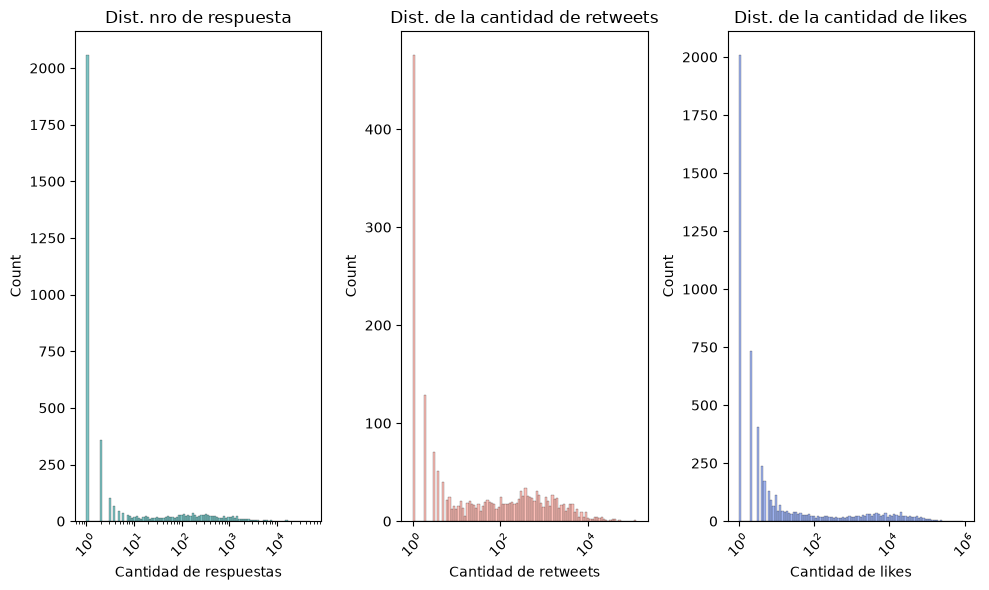

/home/ezequiel/personal_projects/mentoria_2025/.venv/lib/python3.11/site-packages/pandas/core/nanops.py:1028: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


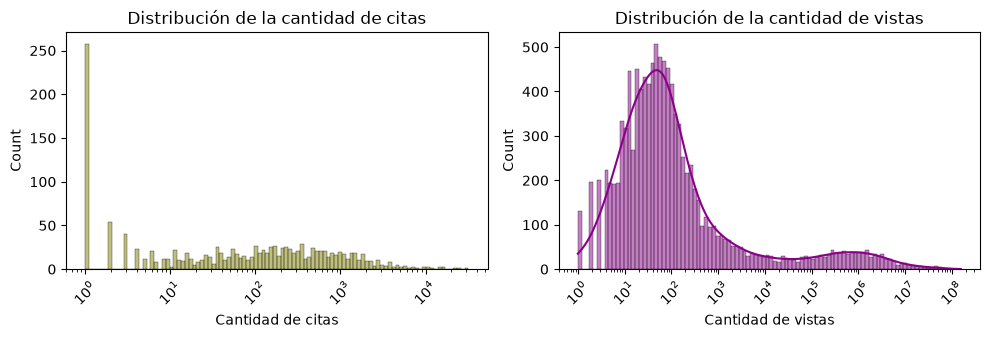

In [15]:
plt.figure(figsize=(10, 6))

plt.subplot(1, 3, 1)
sns.histplot(df['replyCount'], color='darkcyan', kde='True', bins=100, log_scale=True)
plt.xticks(rotation=45)
plt.xlabel('Cantidad de respuestas')
plt.title('Dist. nro de respuesta')

plt.subplot(1, 3, 2)
sns.histplot(df['retweetCount'], color='salmon',  kde='True', bins=100, log_scale=True)
plt.xticks(rotation=45)
plt.xlabel('Cantidad de retweets')
plt.title('Dist. de la cantidad de retweets')

plt.subplot(1, 3, 3)
sns.histplot(df['likeCount'], color='royalblue', kde='True', bins=100, log_scale=True)
plt.xticks(rotation=45)
plt.xlabel('Cantidad de likes')
plt.title('Dist. de la cantidad de likes')

plt.tight_layout()
plt.show()


plt.figure(figsize=(10, 6))

plt.subplot(2, 2, 1)
sns.histplot(df['quoteCount'], color='olive',  kde='True',bins=100, log_scale=True)
plt.xticks(rotation=45)
plt.xlabel('Cantidad de citas')
plt.title('Distribución de la cantidad de citas')

plt.subplot(2, 2, 2)
sns.histplot(df['viewCount'], color='darkmagenta',  kde='True',bins=100, log_scale=True)
plt.xticks(rotation=45)
plt.xlabel('Cantidad de vistas')
plt.title('Distribución de la cantidad de vistas')

plt.tight_layout()
plt.show()

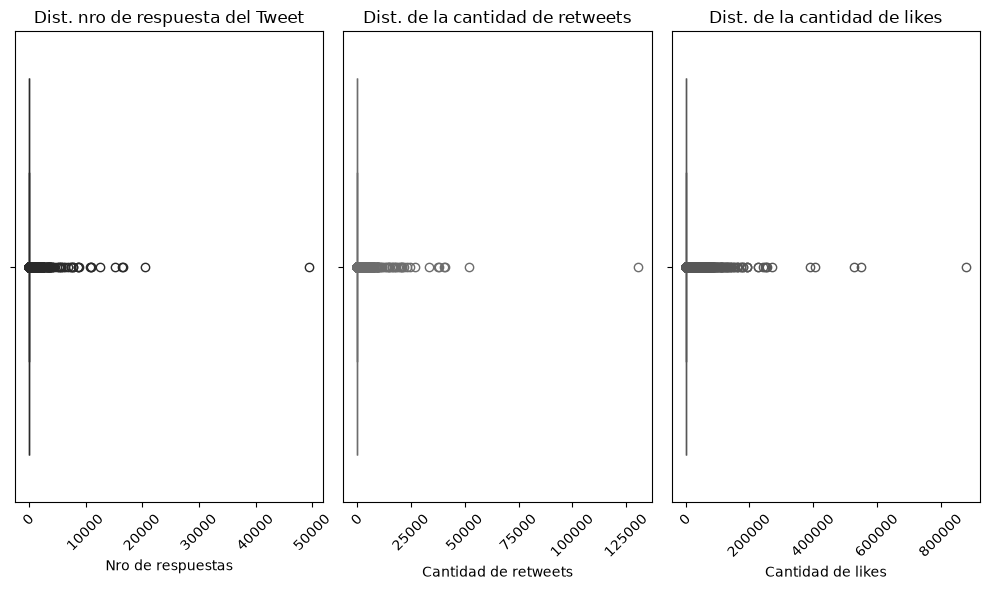

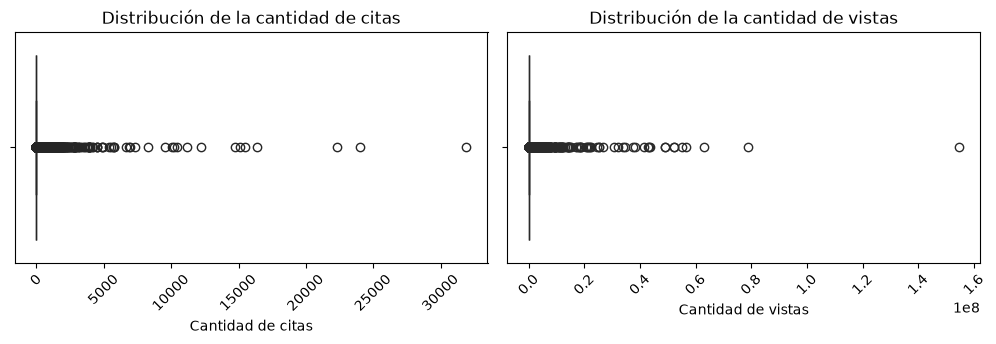

In [16]:
plt.figure(figsize=(10, 6))

plt.subplot(1, 3, 1)
sns.boxplot(x=df['replyCount'], color='darkcyan')
plt.xticks(rotation=45)
plt.xlabel('Nro de respuestas')
plt.title('Dist. nro de respuesta del Tweet')

plt.subplot(1, 3, 2)
sns.boxplot(x=df['retweetCount'], color='salmon',)
plt.xticks(rotation=45)
plt.xlabel('Cantidad de retweets')
plt.title('Dist. de la cantidad de retweets')

plt.subplot(1, 3, 3)
sns.boxplot(x=df['likeCount'], color='royalblue')
plt.xticks(rotation=45)
plt.xlabel('Cantidad de likes')
plt.title('Dist. de la cantidad de likes')

plt.tight_layout()
plt.show()


plt.figure(figsize=(10, 6))

plt.subplot(2, 2, 1)
sns.boxplot(x=df['quoteCount'], color='olive')
plt.xticks(rotation=45)
plt.xlabel('Cantidad de citas')
plt.title('Distribución de la cantidad de citas')

plt.subplot(2, 2, 2)
sns.boxplot(x=df['viewCount'], color='darkmagenta')
plt.xticks(rotation=45)
plt.xlabel('Cantidad de vistas')
plt.title('Distribución de la cantidad de vistas')

plt.tight_layout()
plt.show()

Según los datos estadísticos, se observa que las variables replyCount, retweetCount, likeCount, quoteCount y viewCount presentan una alta dispersión, con medias muy superiores a sus respectivas medianas. Esto indica que la presencia de valores extremos esta influenciando sobre la media. Por ejemplo, el valor máximo de viewCount es de 154.426.838, mientras que el 75% de los tweets tienen menos de 255 visualizaciones. En likeCount, el 50% de los tweets tienen solo un like o ninguno, y en replyCount, retweetCount y quoteCount, la mediana es 0, lo que refleja que la mayoría de los tweets no reciben interacción significativa.

Esta asimetría en la distribución nos indica que la mayoría de los tweets del dataset tienen bajo alcance y que los valores extremos corresponden a tweets virales.

Muchos de estos valores extremos pertenecen a tweets que no estan relacionados con la temática de estudio.

Como primer paso se analiza la cantidad de tweets que no estan relacionados al tema de análisis:

In [17]:
pd.set_option('display.max_colwidth', None)

In [18]:
import re

keywords = ['Obesidad', 'obesidaddd', 'gordura', 'sobrepeso', 'gorduras',
            'adiposidad', 'Sobrepeso', 'obesito', 'obesoo', 'obesidad',
            'obeso', 'obesa', 'gorrrdura', 'obesaa', 'obesita', 'Obesa',
            'obesaaa', 'Obesos', 'Obesas', 'obesas', 'obesos', 'gordo',
            'gorda', 'gordos', 'gordas', 'peso', 'pesar']

pattern = '|'.join(keywords)
df['containKeyword'] = df['rawContent'].str.contains(pattern, flags=re.IGNORECASE, na=False)

In [19]:
df[~df['containKeyword']].rawContent

2                                                                                                                                                                                        yo, re pesada mal: ✨EL UNIVERSO CONSPIRA A MI FAVOR✨ 🪬GRACIAS, GRACIAS, GRACIAS🫂
3        Me puse una cartera usada que me regalaron y tenía $500 adentro olvidados. Tenía que venir al taller re cargada y no tenía efectivo más que eso, me pedí un auto y no entiendo cómo pero salió $472 un día de lluvia. \nBuen día que placer esta pavada link_url
8                                                                                                                                                                                                                                                            QUÉ link_url
16                                                                                                                                                                                                        

Se detectan 2044 tweets cuyo contenido que no tiene ninguna de las keywords. Lo más probable es que la palabra haya estado en otro lado, en el nombre de usuario, un usuario mencionado, el link ya borrado o alguna otra parte del tweet.

Algunos de los comentarios con mayor cantidad de interacciones no estan relacionados con la temática. La eliminación de estos tweets se dejara como última instancia, si después de la limpieza que se realizará previamente, aún deja comentarios irrelevantes entre los que tienen más interacciones, los revisaremos manualmente dada la importancia que revisten para un análisis donde consideremos los comentarios más interactuados.

Se analiza la cantidad de tweets cuyo contenido esta duplicado:

In [20]:
comentarios_duplicados = df['rawContent'].duplicated().sum()
print('Cantidad de Tweets duplicados', comentarios_duplicados)

Cantidad de Tweets duplicados 137


In [21]:
df[df['rawContent'].duplicated()]['rawContent'].value_counts().sort_values(ascending=False).head(10)

rawContent
link_url                                                                                                                                                                                                                                                                      45
Cómo puede ser q una pediatra hablé así sabiendo q hay tantos niños y adolescentes con obesidad? Asco total ella y su grupo      sinceramente está edision es lamentable como un programa permite tanta agresion?                                                             19
obesa                                                                                                                                                                                                                                                                          6
obeso                                                                                                                                                                     

In [22]:
df[df['rawContent'].duplicated()][['rawContent', 'user_id']].value_counts().sort_values(ascending=False).head(10)

rawContent                                                                                                                                                                                                                                             user_id
Cómo puede ser q una pediatra hablé así sabiendo q hay tantos niños y adolescentes con obesidad? Asco total ella y su grupo      sinceramente está edision es lamentable como un programa permite tanta agresion?                                      79         19
❗ "La obesidad es una porquería": internaron a "El Gaucho" de Cuestión de Peso\n\n👉🏻 Cuentan con úlceras en las piernas que pueden complicarse\n\n(💣 Para El Trece, el show debe continuar)\n\nlink_url link_url                                       471         4
link_url                                                                                                                                                                                                                       

Se encontraron 137 comentarios duplicados, entre ellos link_url que deberá ser filtrado y algunos que consideramos que son muy probables como 'obeso'. Aparecen un par más que al ser del mismo usuario pareciera que el usuario posteo varias veces lo mismo.

Se verifica la cantidad de tweets cuyo contenido tiene solo una palabra:

In [23]:
# Número de comentarios con una sola palabra
una_palabra = df[df['rawContent'].str.split().apply(len) ==1].shape[0]
print('Cantidad de tweets con 1 palabra: ', una_palabra)

Cantidad de tweets con 1 palabra:  91


In [24]:
df[df['rawContent'].str.split().apply(len) ==1].rawContent.value_counts().sort_values(ascending=False).head(10)

rawContent
link_url     46
obesa         7
obeso         7
Sobrepeso     5
Obeso         5
Obesa         4
obesidad      2
Obesidad      2
Obeso?        2
Obesa?        2
Name: count, dtype: int64

Comentarios de una sola palabra, encontramos 46 con "link_url", que no aportan información relevante.

 Por otro lado, como lo que vamos a realizar es un análisis de las distintas temáticas en torno a la obesidad en Twitter comentarios con una palabra no aportan suficiente información como para ser agrupado en relación de los temas ya detectados o posibles temas que surgan en el análisis. La principal diferencia es que no queda claro si se trata de insultos, lo que si sucede al considerar dos palabras

Se verifica la cantidad de tweets cuyo contenido tiene menos de 3 palabras:

In [25]:
menos_de_tres_palabras= df[df['rawContent'].str.split().apply(len) < 3].shape[0]
print('Cantidad de tweets con menos de 3 palabras: ', menos_de_tres_palabras)

Cantidad de tweets con menos de 3 palabras:  211


Se verifican los tweets con menos de 3 palabras y con la palabra url_link:

In [26]:
menos_de_tres_palabras_ulink= df[(df['rawContent'].str.split().apply(len) < 3) & (df['rawContent'].str.contains('link_url', na=False))].shape[0]
print('Cantidad de tweets con menos de 3 palabras y con la palabra url_link: ', menos_de_tres_palabras_ulink)

Cantidad de tweets con menos de 3 palabras y con la palabra url_link:  68


In [27]:
df[(df['rawContent'].str.split().apply(len) < 3) & (df['rawContent'].str.contains('link_url', na=False))].sample(10)

,id_str,date,rawContent,replyCount,retweetCount,likeCount,quoteCount,conversationId,hashtags,viewCount,pcia,mes,user_id,pcia1,hashtags1,containKeyword
8065,1824924018836689394,2024-08-17 21:39:26,Cósmico!! link_url,30,122,917.0,17,1824924018836689394,[],89918.0,[],8,312,[],[],False
136,1745959572487999753,2024-01-13 00:02:55,link_url,37,4214,31247.0,297,1745959572487999753,[],548248.0,[],1,112,[],[],False
9346,1838343215239565738,2024-09-23 22:22:31,⚠️OBESIDAD⚠️ link_url,5,1,71.0,1,1838340001559425217,[],23014.0,['buenos aires'],9,587,[buenos aires],[],True
1077,1749588595898224777,2024-01-23 00:23:21,link_url,223,711,3383.0,91,1749588595898224777,[],143943.0,[],1,749,[],[],False
7296,1815400188942438700,2024-07-22 14:55:08,link_url,24,1315,13123.0,34,1815400188942438700,[],244728.0,[],7,488,[],[],False
9118,1837203646431588734,2024-09-20 18:54:17,link_url,21,174,6514.0,37,1837203646431588734,[],267896.0,['buenos aires'],9,430,[buenos aires],[],False
3594,1773106881570947122,2024-03-27 21:56:37,JUJUUUUUUUUUUUUUUUUJU\n\n link_url,738,206,2890.0,115,1773106881570947122,[],479711.0,[],3,968,[],[],False
4059,1777288891545817307,2024-04-08 10:54:26,? link_url,285,3385,45316.0,895,1777288891545817307,[],3412139.0,[],4,325,[],[],False
9300,1840135363425337728,2024-09-28 21:03:53,desayuno link_url,20,505,7049.0,35,1840135363425337728,[],90481.0,[],9,555,[],[],False
4363,1781521977561260293,2024-04-20 03:15:13,link_url,23,279,4760.0,202,1781521977561260293,[],149599.0,[],4,555,[],[],False


#### Tweets en otro idioma:

En el Práctico 1 detectamos presencia de tweets en inglés, a continuación se realizará un análisis con la librería Lingua, la misma  está diseñada para ser precisa incluso en textos cortos y sucios como los tweets. Esto significa que está construida para manejar variaciones y ruido que son comunes en el lenguaje natural de las redes sociales.

**Dependencias**

Esta instalación se quitó de la notebook. La dependencia correspondiente está declarada en `requirements.txt`.

In [28]:
from lingua import Language, LanguageDetectorBuilder

# Se define el detector con los idiomas que se detectaron en TP1:
detector = LanguageDetectorBuilder.from_languages(Language.SPANISH, Language.ENGLISH) \
    .with_minimum_relative_distance(0.05) \
    .with_preloaded_language_models() \
    .build()#esa distancia minima se agrega para que considere tambien tweets cortos

def detectar_idioma_lingua(texto):
    try:
        if not texto or not isinstance(texto, str):
            return "unknown"
        idioma = detector.detect_language_of(texto.strip())
        return idioma.name if idioma else "unknown"
    except:
        return "error"

In [29]:
df['idioma_lingua'] = df['rawContent'].apply(detectar_idioma_lingua)

In [30]:
df['idioma_lingua'].unique()

<ArrowStringArray>
['SPANISH', 'ENGLISH', 'unknown']
Length: 3, dtype: str

In [31]:
df[df['idioma_lingua']=='ENGLISH'].shape

(222, 17)

In [32]:
df[df['idioma_lingua']=='unknown'].shape

(13, 17)

In [33]:
# ingles = df[df['idioma_lingua']=='ENGLISH']
# for t in ingles['rawContent']:
#     print(t)

En base al análisis realizado se observa que en tweets cortos la presencia de la palabra link_url tiende a sesgar la detección de idioma, llevando a clasificaciones erróneas. Por este motivo se eliminará este marcador para permitir que el detector de idioma se enfoque únicamente en el contenido relevante, link_url no aporta información lingüística.

In [34]:
df_preproces = df.copy()
df_preproces.shape

(11111, 17)

In [35]:
df_preproces['rawContent_sin_link'] = df['rawContent'].apply(lambda x: x.replace('link_url', ''))

In [36]:
df_preproces['idioma_lingua'] = df_preproces['rawContent_sin_link'].apply(detectar_idioma_lingua)

In [37]:
df_preproces['idioma_lingua'].unique()

<ArrowStringArray>
['SPANISH', 'unknown', 'ENGLISH']
Length: 3, dtype: str

In [38]:
df_preproces[df_preproces['idioma_lingua']=='SPANISH'].shape

(10900, 18)

In [39]:
df_preproces[df_preproces['idioma_lingua']=='unknown'].shape

(57, 18)

In [40]:
df_preproces[df_preproces['idioma_lingua']=='ENGLISH'].shape

(154, 18)

In [41]:
# ingles = df_preproces[df_preproces['idioma_lingua']=='unknown']
# for t in ingles['rawContent_sin_link']:
#     print(t)

Se realizó una detección de idiomas en el dataset, obteniendo los siguientes resultados:

- 10.900 tweets identificados en español.

- 154 tweets identificados en inglés.

- 57 tweets no reconocidos, entre los cuáles se encontró un tweet en japonés..

Dentro de los tweets en español e ingles se detectaron dos tweets en fracés.

Para optimizar la detección en textos breves, como los tweets, se configuró la distancia relativa mínima (minimum_relative_distance) en 0.05. Este umbral aumenta la sensibilidad del modelo, permitiéndole clasificar con mayor eficacia incluso aquellos tweets que, por su longitud o contenido, podrían presentar ambigüedades. Si bien esta configuración puede implicar la clasificación de algunos casos con una ligera mezcla de español e inglés, fue seleccionada estratégicamente para lograr un equilibrio óptimo entre precisión y cobertura en el dataset, maximizando la cantidad de contenido relevante para el análisis en español.

id_str de tweets en francés:
 - 1813645720420827283
 - 1829947312296038446

id_str en japonés:
- 1776755790373929292



In [42]:
pd.set_option('display.max_colwidth', 50)

In [43]:
#Francés:
tweets_frances = [1813645720420827283, 1829947312296038446]
df_preproces[df_preproces['id_str'].isin(tweets_frances)]

,id_str,date,rawContent,replyCount,retweetCount,likeCount,quoteCount,conversationId,hashtags,viewCount,pcia,mes,user_id,pcia1,hashtags1,containKeyword,idioma_lingua,rawContent_sin_link
7057,1813645720420827283,2024-07-17 18:43:30,j’en ai ras le cul de recevoir des teubs tt le...,655,402,6015.0,1318,1813645720420827283,[],7571395.0,[],7,312,[],[],False,ENGLISH,j’en ai ras le cul de recevoir des teubs tt le...
8325,1829947312296038446,2024-08-31 18:20:12,Rétro cars voiture 🚘 la Dyane6 Citroen 2cv est...,2,11,79.0,1,1829947312296038446,[],1809.0,[],8,514,[],[],False,SPANISH,Rétro cars voiture 🚘 la Dyane6 Citroen 2cv est...


In [44]:
#Japonés
df_preproces[df_preproces['id_str']==1776755790373929292]

,id_str,date,rawContent,replyCount,retweetCount,likeCount,quoteCount,conversationId,hashtags,viewCount,pcia,mes,user_id,pcia1,hashtags1,containKeyword,idioma_lingua,rawContent_sin_link
3696,1776755790373929292,2024-04-06 23:36:05,柔道、カポエイラの王者を自称する260キロのチェコ人女性が壮大に自爆！\n\n link_url,269,725,5377.0,186,1776755790373929292,[],2186589.0,[],4,35,[],[],False,unknown,柔道、カポエイラの王者を自称する260キロのチェコ人女性が壮大に自爆！\n\n


#### Procesamiento y curación del dataset:

Como primer paso nos quedaremos sólo con los tweets en español ya que el análisis estará centrado en Argentina donde el idioma oficial es el español. Los tweets en inglés (o cualquier otro idioma que no sea español) podrían introducir ruido o inconsistencias, por este motivo se eliminarán del dataset para asegurar la coherencia del corpus y mejorar la calidad de las tareas posteriores de procesamiento del lenguaje natural.


In [45]:
df_preproces_idioma = df_preproces[df_preproces['idioma_lingua']=='SPANISH']


In [46]:
df_preproces_idioma['idioma_lingua'].unique()

<ArrowStringArray>
['SPANISH']
Length: 1, dtype: str

Verificamos si se eliminaron también los tweets en francés y japonés:

In [47]:
tweets_frances = [1813645720420827283, 1829947312296038446]
df_preproces_idioma[df_preproces_idioma['id_str'].isin(tweets_frances)]

,id_str,date,rawContent,replyCount,retweetCount,likeCount,quoteCount,conversationId,hashtags,viewCount,pcia,mes,user_id,pcia1,hashtags1,containKeyword,idioma_lingua,rawContent_sin_link
8325,1829947312296038446,2024-08-31 18:20:12,Rétro cars voiture 🚘 la Dyane6 Citroen 2cv est...,2,11,79.0,1,1829947312296038446,[],1809.0,[],8,514,[],[],False,SPANISH,Rétro cars voiture 🚘 la Dyane6 Citroen 2cv est...


In [48]:
#Se elimina el tweet:
df_preproces_idioma = df_preproces_idioma[df_preproces_idioma['id_str'] != 1829947312296038446]

In [49]:
#Japonés
df_preproces_idioma[df_preproces_idioma['id_str']==1776755790373929292]

,id_str,date,rawContent,replyCount,retweetCount,likeCount,quoteCount,conversationId,hashtags,viewCount,pcia,mes,user_id,pcia1,hashtags1,containKeyword,idioma_lingua,rawContent_sin_link


In [50]:
df_preproces_idioma.reset_index(drop=True, inplace=True)
df_preproces_idioma.shape

(10899, 18)

Porcentaje eliminado hasta el momento del data set original:

In [51]:
dif_datasets = df.shape[0] - df_preproces_idioma.shape[0]
porcentaje_limpieza = round((dif_datasets*100)/df.shape[0],2)
print(f'Se elimino un {porcentaje_limpieza}% del dataset original')

Se elimino un 1.91% del dataset original


In [52]:
df_preproces_filtrado = df_preproces_idioma.copy()
df_preproces_filtrado.shape

(10899, 18)

In [53]:
#Se eliminan filas duplicadas:
df_preproces_filtrado.drop_duplicates(subset=['rawContent_sin_link'], inplace = True)
df_preproces_filtrado.shape

(10808, 18)

In [54]:
#Se filtran los tweets con una palabra:
df_preproces_filtrado = df_preproces_filtrado[df_preproces_filtrado['rawContent_sin_link'].str.split().apply(len)>1]
df_preproces_filtrado.shape

(10781, 18)

Se verifica nuevamente si hay tweets con menos de 3 palabras y se analiza su contenido:

In [55]:
menos_de_tres_palabras= df_preproces_filtrado[df_preproces_filtrado['rawContent_sin_link'].str.split().apply(len) < 3].shape[0]
print('Cantidad de tweets con menos de 3 palabras: ', menos_de_tres_palabras)

Cantidad de tweets con menos de 3 palabras:  98


In [56]:
tweets_cortos = df_preproces_filtrado[df_preproces_filtrado['rawContent_sin_link'].str.split().apply(len) < 3]
for t in tweets_cortos['rawContent_sin_link']:
    print(t)

Mentalmente OBESO
alto obeso
la amo
obeso incogible
con sobrepeso
Negros obesos*
Pajertario obeso
vamooo chizooo
¿Es.por sobrepeso?
Calle obesa!
Está obeso
NEYMAR ?????? 
Uh aburrieron
"sobrepeso" kjj
Tenes sobrepeso?
Todas obesas
Callese obesa
Y sobrepeso
Lloro lpm🤣🤣🤣😂😂🤣🤣😂😂
especialmente vos
obeso autista
Todas obesas.
obeso pumba
alta obesa
HOLAAA #TwON
estaremos 𝘴𝘪𝘨𝘶𝘪𝘦𝘯𝘥𝘰
Obesa .
ME TENTE
Obesa roñosa
sobrepeso JAJWJSJAJAJA
Grande: obesidad
ESTOY EXTASIADA
Basta obeso
"Gracias crack" 
Obesidad mórbida…
boludeces obesa
obesidad morbida 
gordo obeso
Negro obeso
gente obesa
estoy obesa
10 obesa
obesos unidos
Gato obeso
la portobello
Simio obeso
Coso obesa
Este obeso. 
obesidad mórbida
y bueno...
ay ridículaaaaaaaaaaaa
Es obesidad.
obesa mórbida
GATO OBESO 
Jajajaj sobrepeso!
Obesidad Morbida
Toy obesa
Obesa pobre
sos OBESO
OBESA ESTOY
Obesa?! OBESO
Obesa espantosa!
bueno obesa
que obeso
..... sobrepeso
obeso burro
#ApellidosFavoritosQueRecepciono Obeso
obesidad morbida
Obesita tilinga


Como se puede ver, muchos de los tweets con menos de 3 palabras, a pesar de ser breves, tienen un fuerte contenido emocional, agresivo y hasta de burla, lo cual es muy relevante para el análisis de sentimiento que se realizará más adelante. Por este
motivo se decide no eliminarlos.

In [57]:
df_preproces_filtrado.reset_index(drop=True, inplace=True)


Se analiza y se da tratamiento a los valores atípicos:

In [58]:
pd.set_option('display.float_format', '{:,.2f}'.format)
df_preproces_filtrado.describe()

,id_str,replyCount,retweetCount,likeCount,quoteCount,conversationId,viewCount,mes,user_id
count,"10,781.00","10,781.00","10,781.00","10,781.00","10,781.00","10,781.00","10,720.00","10,781.00","10,781.00"
mean,"1,799,457,718,860,609,792.00",41.32,82.55,"1,098.34",32.93,"1,798,972,673,310,007,552.00","94,634.69",5.75,329.99
std,"36,978,115,270,803,048.00",358.10,692.76,"7,146.11",233.80,"39,914,508,744,225,592.00","649,428.45",3.35,250.19
min,"1,742,551,559,316,107,520.00",0.00,0.00,0.00,0.00,"587,795,061,225,697,280.00",1.00,1.00,0.00
25%,"1,767,248,521,126,654,208.00",0.00,0.00,0.00,0.00,"1,766,957,451,377,598,976.00",17.00,3.00,106.00
50%,"1,793,413,563,136,221,440.00",0.00,0.00,1.00,0.00,"1,793,194,634,803,298,816.00",54.00,5.00,298.00
75%,"1,827,683,653,586,927,872.00",1.00,0.00,3.00,0.00,"1,827,373,928,802,636,032.00",199.00,8.00,524.00
max,"1,870,045,511,706,620,160.00","20,464.00","40,546.00","181,417.00","6,974.00","1,870,029,828,369,330,432.00","17,378,208.00",12.00,"1,013.00"


In [59]:
df_preproces_filtrado[~df_preproces_filtrado['containKeyword']].rawContent_sin_link.shape

(1833,)

Para asegurar que el análisis se centre en posteos relacionados específicamente con la temática de obesidad, se tomó la decisión de eliminar del dataset aquellos tweets que no contienen ninguna de las palabras clave previamente definidas.


In [60]:
rows = df_preproces_filtrado.shape[0]
df_preproces_atipicos = df_preproces_filtrado[df_preproces_filtrado['containKeyword']]
print(f"Se eliminarion {df_preproces_filtrado.shape[0] - len(df_preproces_atipicos)} tweets")

Se eliminarion 1833 tweets


In [61]:
df_preproces_atipicos.columns

Index(['id_str', 'date', 'rawContent', 'replyCount', 'retweetCount',
       'likeCount', 'quoteCount', 'conversationId', 'hashtags', 'viewCount',
       'pcia', 'mes', 'user_id', 'pcia1', 'hashtags1', 'containKeyword',
       'idioma_lingua', 'rawContent_sin_link'],
      dtype='str')

Revisaremos los comentarios con mayor cantidad de interacciones:

In [62]:
df_preproces_atipicos.describe()

,id_str,replyCount,retweetCount,likeCount,quoteCount,conversationId,viewCount,mes,user_id
count,"8,948.00","8,948.00","8,948.00","8,948.00","8,948.00","8,948.00","8,889.00","8,948.00","8,948.00"
mean,"1,800,440,005,541,239,552.00",9.50,22.65,250.90,5.02,"1,799,908,781,937,186,048.00","19,490.47",5.84,361.33
std,"36,400,862,963,580,272.00",172.71,524.67,"3,447.82",73.14,"39,762,221,179,289,480.00","285,813.11",3.29,240.20
min,"1,742,584,849,318,212,096.00",0.00,0.00,0.00,0.00,"587,795,061,225,697,280.00",1.00,1.00,0.00
25%,"1,769,112,268,063,539,456.00",0.00,0.00,0.00,0.00,"1,768,813,148,173,176,832.00",13.00,3.00,157.00
50%,"1,794,959,208,617,560,320.00",0.00,0.00,0.00,0.00,"1,794,742,418,983,760,128.00",40.00,5.00,337.00
75%,"1,828,044,983,787,487,488.00",1.00,0.00,2.00,0.00,"1,827,793,486,835,497,472.00",135.00,8.00,544.00
max,"1,870,045,511,706,620,160.00","10,753.00","40,546.00","140,507.00","2,739.00","1,870,029,828,369,330,432.00","11,744,987.00",12.00,"1,013.00"


In [63]:
pd.set_option('display.max_colwidth', None)

In [64]:
#Visualizar Top 10 de replyCount
top_replyCount = df_preproces_atipicos.sort_values(by='replyCount', ascending=False)
top_replyCount[['rawContent_sin_link',  'replyCount']].head(10) #Se muestran los 10 tweets con más respuestas

,rawContent_sin_link,replyCount
5607,"Nelly Furtado subió esta foto y en cualquier momento la borra 😬\nSe le llenó de comentarios de mujeres llamándola ""gorda"" y que debería darle vergüenza vestirse así.",10753
7146,"Barbara Butch es la judía, obesa, lesbiana y queer que representó a Jesús de forma insultante en la ceremonia de los JJOO de 2024 del viernes.\n\nLos patrocinadores ya han comenzado a retirarse tras la actuación que insultó a miles de millones de cristianos.",7352
7523,"Cómplices, por acción u omisión.\n\nEn Venezuela hay una Dictadura Comunista que secuestra, tortura y asesina a cualquiera que se les oponga. Ninguna persona honesta intelectualmente puede negar esta realidad.\n\n¿No les llama la atención que todos los políticos, periodistas, empresarios y sindicalistas que nos tildaron de fascistas cierren la boca con respecto a la dictadura venezolana?\n\nIncluso algunos apoyan al Dictador Maduro. Dicen, sin ponerse colorados, que ganó las elecciones de forma legítima. Que Venezuela es una democracia. Todo esto mientras afirman que nuestro movimiento es fascista.\n\nEl Comunismo es una ideología asesina y antihumana que siempre termina en una dictadura sangrienta y asesina, como el fascismo.\n\nNunca vas a escuchar a los periodistas progresistas y bienpensantes decir que el comunismo es una ideología asesina. Es hora que elijan y salgan de la neutralidad. A los imbéciles de la idea del centrismo bienpensante y que tildan de fascista a todo aquel que escapa de su lógica mediocre les pregunto de modo directo:\n¿Maduro o Corina Machado?\n\nMientras sigan buscando al helado caliente, al esqueleto obeso y a la meretriz virgen seguirán siendo los grandes cómplices del desastre decadente argentino.\nVLLC !!!\n\nPD: lindo brete para los boluprogres del centrismo bienpensate, ya que si eligen se contradicen con todo lo que han venido diciendo/escribiendo (en su definición se vuelven fascistas) y si se mantienen nuestros dejan bien en claro la basura que son.\nJAQUE MATE",6332
4697,"Cada vez que en el gimnasio veo una persona obesa haciendo aparatos me dan ganas de decirle anda a correr a la cinta!!! Baja de peso! Hace aeróbico y después aparatos no te sirve gord@ eso! \n\nPero como tengo que ser políticamente correcta, lo digo en twitter.",2587
1224,"Toda la tarde fui tendencia en esta red por “ gorda” , la verdad me voy a preocupar cuando discutan mis ideas, para mí las mujeres somos todas lindas, no tengo problemas de autoestima.\nLo de los ascensores lo plantee en el marco de que los diputados y diputadas tenemos libre circulación dentro de la cámara , pero entiendo que laburan de esto .\nTal vez era más fácil hablar de mi cuerpo que de un copito en el congreso.\nLos dejo, me voy a descansar , estuvimos trabajando hasta hace un rato con la ley ómnibus o combi a esta altura para ser más exactos, mañana tal vez aparezca el dictamen, eso es lo urgente.",2503
5921,"Playa en 1970.\nNo hay obesidad, no habian drogadictos, no existian tatuajes, ni implantes de plástico. No hay camas playeras porque tumbarse en la arena desestresa, no hay sombrillas porque el Sol en buena medida fortalece la salud, ni hay gafas de sol ni cremas tóxicas. No hay móviles sino gente real hablando en una red social original y sobre todo no hay lineas blancas en el cielo. \nNo hay nada, pero hay de todo. Hay que volver a lo que funciona, y lo que funciona no es nada de lo estamos haciendo hoy. Hay que rebelarse!",2440
8249,"Ayer tuve un evento y me presentaron a un chico. 37 años, yo cuarenta. “ es muy buena persona”. Lo es. \nProblema. Yo no puedo salir con una persona que con 37 años tiene sobrepeso, fuma y se bebe hasta el agua de los floreros. Por no decir lo que come.",2297
6195,Porque los hombres gordos son graciosos y las mujeres gordas son insoportables???,1768
9608,nunca verás a una chica de gym con un obeso,1524
7317,gorda de mierda no comas tanto y listo,1513


In [65]:
#Visualizar Top 10 de retweetCount
top_retweetCount = df_preproces_atipicos.sort_values(by='retweetCount', ascending=False)
top_retweetCount[['rawContent_sin_link', 'retweetCount']].head(10) #Se muestran los 20 tweets con más retweet

,rawContent_sin_link,retweetCount
7523,"Cómplices, por acción u omisión.\n\nEn Venezuela hay una Dictadura Comunista que secuestra, tortura y asesina a cualquiera que se les oponga. Ninguna persona honesta intelectualmente puede negar esta realidad.\n\n¿No les llama la atención que todos los políticos, periodistas, empresarios y sindicalistas que nos tildaron de fascistas cierren la boca con respecto a la dictadura venezolana?\n\nIncluso algunos apoyan al Dictador Maduro. Dicen, sin ponerse colorados, que ganó las elecciones de forma legítima. Que Venezuela es una democracia. Todo esto mientras afirman que nuestro movimiento es fascista.\n\nEl Comunismo es una ideología asesina y antihumana que siempre termina en una dictadura sangrienta y asesina, como el fascismo.\n\nNunca vas a escuchar a los periodistas progresistas y bienpensantes decir que el comunismo es una ideología asesina. Es hora que elijan y salgan de la neutralidad. A los imbéciles de la idea del centrismo bienpensante y que tildan de fascista a todo aquel que escapa de su lógica mediocre les pregunto de modo directo:\n¿Maduro o Corina Machado?\n\nMientras sigan buscando al helado caliente, al esqueleto obeso y a la meretriz virgen seguirán siendo los grandes cómplices del desastre decadente argentino.\nVLLC !!!\n\nPD: lindo brete para los boluprogres del centrismo bienpensate, ya que si eligen se contradicen con todo lo que han venido diciendo/escribiendo (en su definición se vuelven fascistas) y si se mantienen nuestros dejan bien en claro la basura que son.\nJAQUE MATE",40546
9343,"Como de podrido por dentro tienes que estar para ser guardia civil, encontrarte un camión cargado hasta arriba de material de ayuda para Valencia y pararlo para pesarlo y multar a los voluntarios por superar la carga máxima",17520
7146,"Barbara Butch es la judía, obesa, lesbiana y queer que representó a Jesús de forma insultante en la ceremonia de los JJOO de 2024 del viernes.\n\nLos patrocinadores ya han comenzado a retirarse tras la actuación que insultó a miles de millones de cristianos.",9395
9597,"""Cuando una sociedad pierde su brújula moral, se derrumba desde dentro"". – G.K. Chesterton\n\nUn hilo que expone la decadencia de Occidente🧵\n\n1. La celebración de la obesidad",7610
9476,Detrás de toda mujer trabajadora hay un gato gordo que se queda durmiendo en la cama,7284
6305,se burlan de una señora grande que creció sin educación y esas son sus creencias pero acá tenés a pablalunar que te dice que color de tanga usar para que te den leche esta semana y tenes a las gordas aplaudiendo con el papo,6811
9641,los chabones cuando pesas mas de 50 kilos: che puede q seas un poco obesa mórbida no?,6021
8983,"«Cuando una sociedad pierde su brújula moral, se derrumba desde dentro». – G. K. Chesterton\n\nUn hilo que expone la decadencia de Occidente 🧵\n\n1. La celebración de la obesidad",5932
6195,Porque los hombres gordos son graciosos y las mujeres gordas son insoportables???,5877
1364,"la ""gordura"" es comun en gente con menos acceso a comida buena porque comen harinas y comida barata. el 70% de termos stanley en este pais es trucho. si no estudiaron economia por lo menos estudien nutricion qsyyy",4607


In [66]:
#Visualizar Top 10 de likeCount
top_likeCount = df_preproces_atipicos.sort_values(by='likeCount', ascending=False)
top_likeCount[['rawContent_sin_link',  'likeCount']].head(10) #Se muestran los 10 tweets con más likes.

,rawContent_sin_link,likeCount
7523,"Cómplices, por acción u omisión.\n\nEn Venezuela hay una Dictadura Comunista que secuestra, tortura y asesina a cualquiera que se les oponga. Ninguna persona honesta intelectualmente puede negar esta realidad.\n\n¿No les llama la atención que todos los políticos, periodistas, empresarios y sindicalistas que nos tildaron de fascistas cierren la boca con respecto a la dictadura venezolana?\n\nIncluso algunos apoyan al Dictador Maduro. Dicen, sin ponerse colorados, que ganó las elecciones de forma legítima. Que Venezuela es una democracia. Todo esto mientras afirman que nuestro movimiento es fascista.\n\nEl Comunismo es una ideología asesina y antihumana que siempre termina en una dictadura sangrienta y asesina, como el fascismo.\n\nNunca vas a escuchar a los periodistas progresistas y bienpensantes decir que el comunismo es una ideología asesina. Es hora que elijan y salgan de la neutralidad. A los imbéciles de la idea del centrismo bienpensante y que tildan de fascista a todo aquel que escapa de su lógica mediocre les pregunto de modo directo:\n¿Maduro o Corina Machado?\n\nMientras sigan buscando al helado caliente, al esqueleto obeso y a la meretriz virgen seguirán siendo los grandes cómplices del desastre decadente argentino.\nVLLC !!!\n\nPD: lindo brete para los boluprogres del centrismo bienpensate, ya que si eligen se contradicen con todo lo que han venido diciendo/escribiendo (en su definición se vuelven fascistas) y si se mantienen nuestros dejan bien en claro la basura que son.\nJAQUE MATE","140,507.00"
9641,los chabones cuando pesas mas de 50 kilos: che puede q seas un poco obesa mórbida no?,"97,604.00"
9584,Chicos perdón pero soy gorda y la mitad de los tipos que me hablan son como ese (no tan gigantes pero todos gymbros),"82,216.00"
6195,Porque los hombres gordos son graciosos y las mujeres gordas son insoportables???,"75,306.00"
9335,nunca voy a entender xq se auto percibe león si es una hiena con sobrepeso,"73,103.00"
6305,se burlan de una señora grande que creció sin educación y esas son sus creencias pero acá tenés a pablalunar que te dice que color de tanga usar para que te den leche esta semana y tenes a las gordas aplaudiendo con el papo,"72,315.00"
9597,"""Cuando una sociedad pierde su brújula moral, se derrumba desde dentro"". – G.K. Chesterton\n\nUn hilo que expone la decadencia de Occidente🧵\n\n1. La celebración de la obesidad","65,926.00"
9608,nunca verás a una chica de gym con un obeso,"65,593.00"
10327,"Llevo al perro a la veterinaria después de mucho tiempo y me dice: ese animal está gordo. Ofendido y dispuesto a pelear le digo que es la raza (como si no supiera), que son músculos. Me contesta: ahí tenés una balanza, pesalo. 5 kilos arriba está este sindicalista hijo de puta.","65,418.00"
9394,la nutricionista me dijo q si tenía mucho antojo de boludeces que vea videos de gente obesa comiendo jaksksjs ????,"62,001.00"


In [67]:
#Visualizar Top 10 de viewCount
top_viewCount = df_preproces_atipicos.sort_values(by='viewCount', ascending=False)
top_viewCount[['rawContent_sin_link',  'viewCount']].head(10) #Se muestran los 10 tweets con más visualizaciones.

,rawContent_sin_link,viewCount
9597,"""Cuando una sociedad pierde su brújula moral, se derrumba desde dentro"". – G.K. Chesterton\n\nUn hilo que expone la decadencia de Occidente🧵\n\n1. La celebración de la obesidad","11,744,987.00"
9584,Chicos perdón pero soy gorda y la mitad de los tipos que me hablan son como ese (no tan gigantes pero todos gymbros),"11,122,948.00"
5411,"Queridas, ¿estamos ante el fin de la gordura? En los últimos meses hemos visto cómo famosas, de la noche a la mañana, lucen delgadísimas. ¿Milagro de Lourdes? No: Ozempic. Un medicamento a 130€ el pinchazo. Abro hilo de posibles candidatas.\n\n1. Christina Aguilera 2020-2024:","7,816,087.00"
10713,"TÍPICA EX GORDA. Por eso me caen mal cuando adelgazan, se quieren llevar el mundo por delante 🐖","7,760,868.00"
8983,"«Cuando una sociedad pierde su brújula moral, se derrumba desde dentro». – G. K. Chesterton\n\nUn hilo que expone la decadencia de Occidente 🧵\n\n1. La celebración de la obesidad","6,435,921.00"
4970,Por qué las tallas ahora vienen enormes?\nSerá porque la obesidad está en tendencia?,"5,983,043.00"
9608,nunca verás a una chica de gym con un obeso,"5,901,950.00"
7146,"Barbara Butch es la judía, obesa, lesbiana y queer que representó a Jesús de forma insultante en la ceremonia de los JJOO de 2024 del viernes.\n\nLos patrocinadores ya han comenzado a retirarse tras la actuación que insultó a miles de millones de cristianos.","5,301,441.00"
1077,Esto pasó hoy a la madrugada. Ya es inadmisible lo de la producción cambiando de cámara para proteger a Furia. Ella comenzaba a expulsar gordofobia por todos los poros y como descarrilaba completamente cortaron de forma desesperada. #GranHermano,"4,073,663.00"
6195,Porque los hombres gordos son graciosos y las mujeres gordas son insoportables???,"3,479,191.00"


In [68]:
#Visualizar Top 10 de quoteCount
top_quoteCount = df_preproces_atipicos.sort_values(by='quoteCount', ascending=False)
top_quoteCount[['rawContent_sin_link', 'quoteCount']].head(10) #Se muestran los 10 tweets con más citas.

,rawContent_sin_link,quoteCount
4970,Por qué las tallas ahora vienen enormes?\nSerá porque la obesidad está en tendencia?,2739
2866,Mi psiquiatra tiene una teoría que me parece acertada. Generalmente cuando nos enamoramos todos engordamos 6 kilos. La teoría es que el amor pesa 6 kilos.,2729
4697,"Cada vez que en el gimnasio veo una persona obesa haciendo aparatos me dan ganas de decirle anda a correr a la cinta!!! Baja de peso! Hace aeróbico y después aparatos no te sirve gord@ eso! \n\nPero como tengo que ser políticamente correcta, lo digo en twitter.",2589
6159,que tan lejos estan de su peso ideal coreano?,1521
7523,"Cómplices, por acción u omisión.\n\nEn Venezuela hay una Dictadura Comunista que secuestra, tortura y asesina a cualquiera que se les oponga. Ninguna persona honesta intelectualmente puede negar esta realidad.\n\n¿No les llama la atención que todos los políticos, periodistas, empresarios y sindicalistas que nos tildaron de fascistas cierren la boca con respecto a la dictadura venezolana?\n\nIncluso algunos apoyan al Dictador Maduro. Dicen, sin ponerse colorados, que ganó las elecciones de forma legítima. Que Venezuela es una democracia. Todo esto mientras afirman que nuestro movimiento es fascista.\n\nEl Comunismo es una ideología asesina y antihumana que siempre termina en una dictadura sangrienta y asesina, como el fascismo.\n\nNunca vas a escuchar a los periodistas progresistas y bienpensantes decir que el comunismo es una ideología asesina. Es hora que elijan y salgan de la neutralidad. A los imbéciles de la idea del centrismo bienpensante y que tildan de fascista a todo aquel que escapa de su lógica mediocre les pregunto de modo directo:\n¿Maduro o Corina Machado?\n\nMientras sigan buscando al helado caliente, al esqueleto obeso y a la meretriz virgen seguirán siendo los grandes cómplices del desastre decadente argentino.\nVLLC !!!\n\nPD: lindo brete para los boluprogres del centrismo bienpensate, ya que si eligen se contradicen con todo lo que han venido diciendo/escribiendo (en su definición se vuelven fascistas) y si se mantienen nuestros dejan bien en claro la basura que son.\nJAQUE MATE",1428
5607,"Nelly Furtado subió esta foto y en cualquier momento la borra 😬\nSe le llenó de comentarios de mujeres llamándola ""gorda"" y que debería darle vergüenza vestirse así.",1377
9394,la nutricionista me dijo q si tenía mucho antojo de boludeces que vea videos de gente obesa comiendo jaksksjs ????,1197
4046,"""Comida"": \n\nPor lo que come esta persona con ansiedad y obesidad en tan solo un día. \n\n",1182
5411,"Queridas, ¿estamos ante el fin de la gordura? En los últimos meses hemos visto cómo famosas, de la noche a la mañana, lucen delgadísimas. ¿Milagro de Lourdes? No: Ozempic. Un medicamento a 130€ el pinchazo. Abro hilo de posibles candidatas.\n\n1. Christina Aguilera 2020-2024:",1111
1077,Esto pasó hoy a la madrugada. Ya es inadmisible lo de la producción cambiando de cámara para proteger a Furia. Ella comenzaba a expulsar gordofobia por todos los poros y como descarrilaba completamente cortaron de forma desesperada. #GranHermano,1106


Se realizará la eliminación manual de algunos tweets detectados como ruidosos:

In [69]:
delete_list = [7523, 9343, 9476, 10327, 5411, 9597, 8983]
df_preproces_atipicos = df_preproces_atipicos[~df_preproces_atipicos.index.isin(delete_list)]
df_preproces_atipicos.shape

(8941, 18)

In [70]:
df_preproces_atipicos.reset_index(drop=True, inplace=True)

In [71]:
df_preproces_atipicos.describe()

,id_str,replyCount,retweetCount,likeCount,quoteCount,conversationId,viewCount,mes,user_id
count,"8,941.00","8,941.00","8,941.00","8,941.00","8,941.00","8,941.00","8,882.00","8,941.00","8,941.00"
mean,"1,800,408,179,750,170,368.00",8.30,13.45,202.13,4.49,"1,799,876,540,245,744,384.00","15,789.59",5.84,361.38
std,"36,391,515,087,765,320.00",157.99,201.33,"2,815.42",69.51,"39,755,756,447,916,664.00","230,422.01",3.29,240.20
min,"1,742,584,849,318,212,096.00",0.00,0.00,0.00,0.00,"587,795,061,225,697,280.00",1.00,1.00,0.00
25%,"1,769,106,709,350,416,640.00",0.00,0.00,0.00,0.00,"1,768,801,145,084,956,928.00",13.00,3.00,157.00
50%,"1,794,939,577,226,105,088.00",0.00,0.00,0.00,0.00,"1,794,550,708,852,691,200.00",40.00,5.00,337.00
75%,"1,827,929,297,304,035,328.00",1.00,0.00,2.00,0.00,"1,827,792,788,458,787,328.00",135.00,8.00,544.00
max,"1,870,045,511,706,620,160.00","10,753.00","9,395.00","97,604.00","2,739.00","1,870,029,828,369,330,432.00","11,122,948.00",12.00,"1,013.00"


Verificamos si todavía hay datos faltantes en la variable viewCount

In [72]:
df_preproces_atipicos['viewCount'].isna().sum()

np.int64(59)

In [73]:
df_preproces_atipicos = df_preproces_atipicos.dropna(subset=['viewCount'])
df_preproces_atipicos.shape

(8882, 18)

Porcentaje de tweets eliminados con respecto al original:

In [74]:
dif_datasets = df.shape[0] - df_preproces_atipicos.shape[0]
porcentaje_limpieza = round((dif_datasets*100)/df.shape[0],2)
print(f'Se elimino un {porcentaje_limpieza}% del dataset original')

Se elimino un 20.06% del dataset original


Comparación de distribuciones:

/home/ezequiel/personal_projects/mentoria_2025/.venv/lib/python3.11/site-packages/pandas/core/nanops.py:1028: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
/home/ezequiel/personal_projects/mentoria_2025/.venv/lib/python3.11/site-packages/pandas/core/nanops.py:1028: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


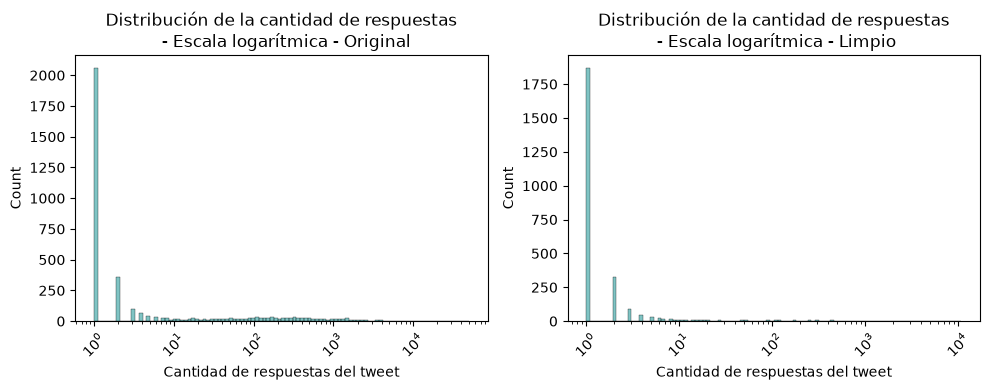

In [75]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
sns.histplot(df['replyCount'], color='darkcyan',  kde='True',bins=100, log_scale=True)
plt.xticks(rotation=45)
plt.xlabel('Cantidad de respuestas del tweet')
plt.title('Distribución de la cantidad de respuestas\n  - Escala logarítmica - Original')

plt.subplot(1, 2, 2)
sns.histplot(df_preproces_atipicos['replyCount'], color='darkcyan', kde=True, bins=100, log_scale=True)
plt.xticks(rotation=45)
plt.xlabel('Cantidad de respuestas del tweet')
plt.title('Distribución de la cantidad de respuestas\n - Escala logarítmica - Limpio')


plt.tight_layout()
plt.show()


/home/ezequiel/personal_projects/mentoria_2025/.venv/lib/python3.11/site-packages/pandas/core/nanops.py:1028: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
/home/ezequiel/personal_projects/mentoria_2025/.venv/lib/python3.11/site-packages/pandas/core/nanops.py:1028: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


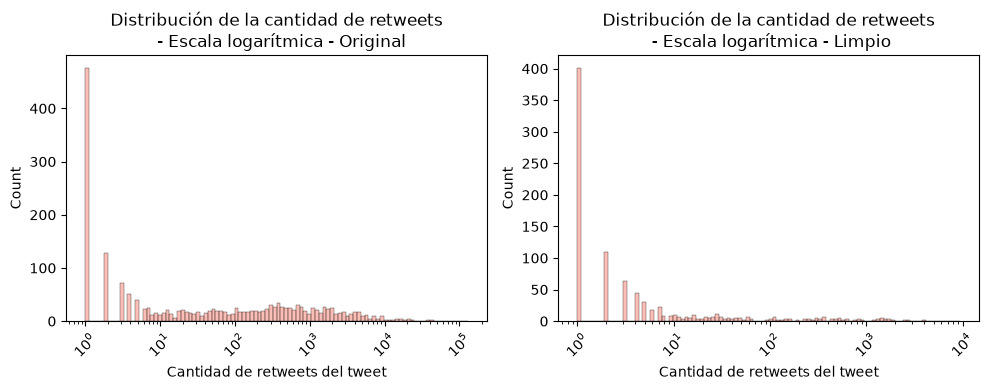

In [76]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
sns.histplot(df['retweetCount'], color='salmon',  kde='True',bins=100, log_scale=True)
plt.xticks(rotation=45)
plt.xlabel('Cantidad de retweets del tweet')
plt.title('Distribución de la cantidad de retweets\n  - Escala logarítmica - Original')

plt.subplot(1, 2, 2)
sns.histplot(df_preproces_atipicos['retweetCount'], color='salmon', kde=True, bins=100, log_scale=True)
plt.xticks(rotation=45)
plt.xlabel('Cantidad de retweets del tweet')
plt.title('Distribución de la cantidad de retweets\n - Escala logarítmica - Limpio')


plt.tight_layout()
plt.show()

/home/ezequiel/personal_projects/mentoria_2025/.venv/lib/python3.11/site-packages/pandas/core/nanops.py:1028: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
/home/ezequiel/personal_projects/mentoria_2025/.venv/lib/python3.11/site-packages/pandas/core/nanops.py:1028: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


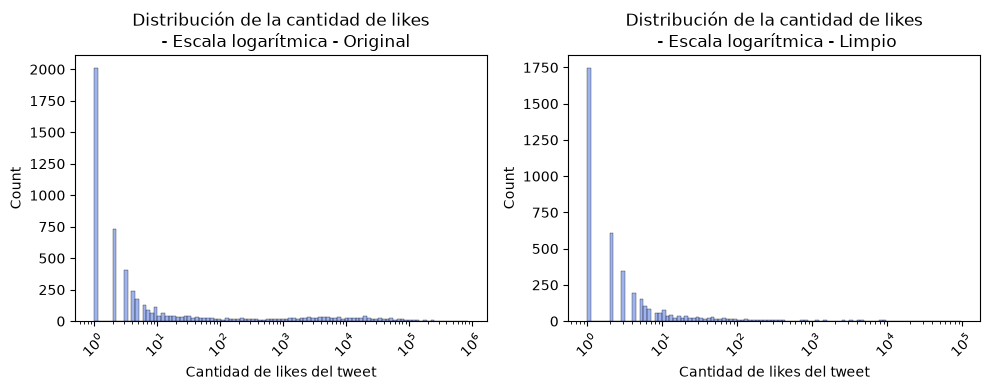

In [77]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
sns.histplot(df['likeCount'], color='royalblue',  kde='True',bins=100, log_scale=True)
plt.xticks(rotation=45)
plt.xlabel('Cantidad de likes del tweet')
plt.title('Distribución de la cantidad de likes\n  - Escala logarítmica - Original')

plt.subplot(1, 2, 2)
sns.histplot(df_preproces_atipicos['likeCount'], color='royalblue', kde=True, bins=100, log_scale=True)
plt.xticks(rotation=45)
plt.xlabel('Cantidad de likes del tweet')
plt.title('Distribución de la cantidad de likes\n - Escala logarítmica - Limpio')


plt.tight_layout()
plt.show()

/home/ezequiel/personal_projects/mentoria_2025/.venv/lib/python3.11/site-packages/pandas/core/nanops.py:1028: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
/home/ezequiel/personal_projects/mentoria_2025/.venv/lib/python3.11/site-packages/pandas/core/nanops.py:1028: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


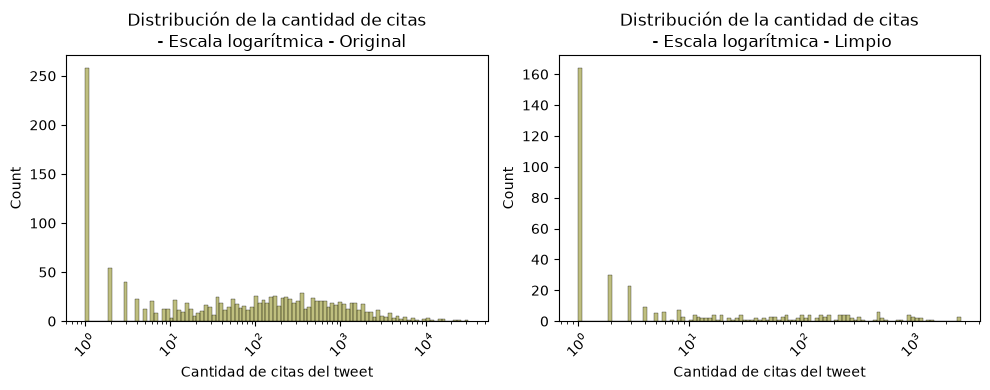

In [78]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
sns.histplot(df['quoteCount'], color='olive',  kde='True',bins=100, log_scale=True)
plt.xticks(rotation=45)
plt.xlabel('Cantidad de citas del tweet')
plt.title('Distribución de la cantidad de citas\n  - Escala logarítmica - Original')

plt.subplot(1, 2, 2)
sns.histplot(df_preproces_atipicos['quoteCount'], color='olive', kde=True, bins=100, log_scale=True)
plt.xticks(rotation=45)
plt.xlabel('Cantidad de citas del tweet')
plt.title('Distribución de la cantidad de citas\n - Escala logarítmica - Limpio')


plt.tight_layout()
plt.show()

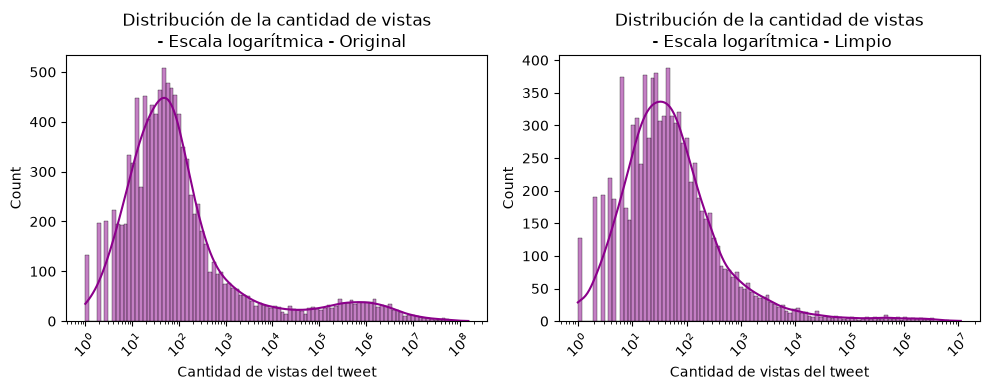

In [79]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
sns.histplot(df['viewCount'], color='darkmagenta',  kde='True',bins=100, log_scale=True)
plt.xticks(rotation=45)
plt.xlabel('Cantidad de vistas del tweet')
plt.title('Distribución de la cantidad de vistas\n  - Escala logarítmica - Original')

plt.subplot(1, 2, 2)
sns.histplot(df_preproces_atipicos['viewCount'], color='darkmagenta', kde=True, bins=100, log_scale=True)
plt.xticks(rotation=45)
plt.xlabel('Cantidad de vistas del tweet')
plt.title('Distribución de la cantidad de vistas\n - Escala logarítmica - Limpio')


plt.tight_layout()
plt.show()


Tweets por semana:

In [80]:
df['date'] = pd.to_datetime(df['date'])
df_preproces_atipicos['date'] = pd.to_datetime(df_preproces_atipicos['date'])

In [81]:
df['semana'] = df['date'].dt.isocalendar().week
df['nombre_mes'] = df['date'].dt.month_name()
mes_predominante1 = df.groupby('semana')['nombre_mes'].agg(lambda x: x.mode().iloc[0])

cant_tweets1 = df['semana'].value_counts().sort_index()
etiqueta1 = [f"Sem {semana} - {mes_predominante1.loc[semana]}" for semana in cant_tweets1.index]

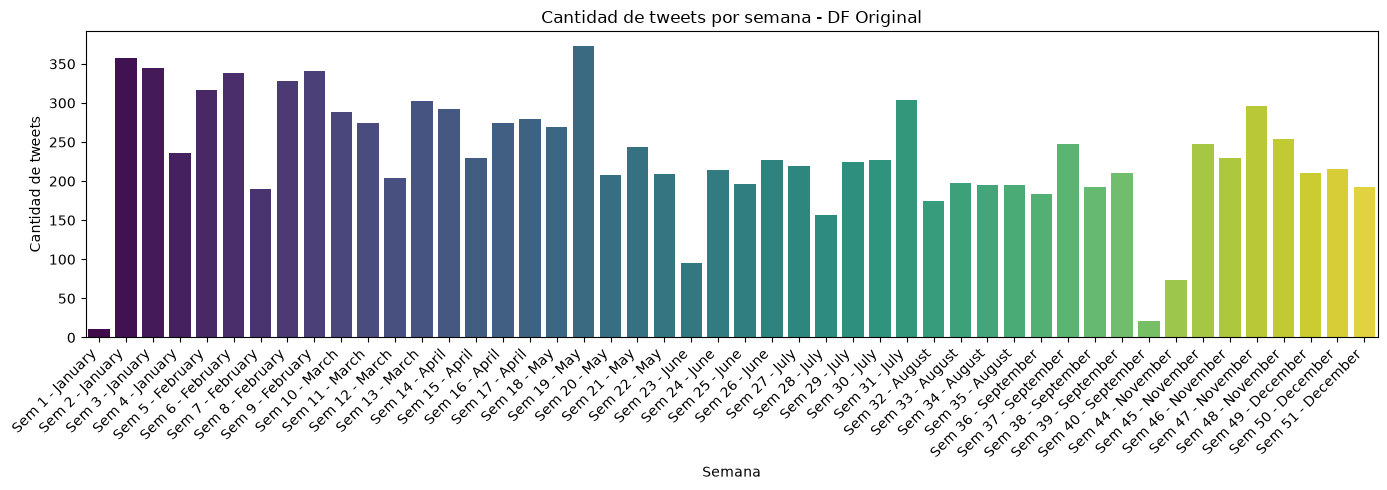

In [82]:
plt.figure(figsize=(14, 5))
sns.barplot(x=cant_tweets1.index, y=cant_tweets1.values, palette='viridis', hue=cant_tweets1.index, legend=False )
plt.xticks(ticks=range(len(etiqueta1)), labels=etiqueta1, rotation=45, ha='right')
plt.xlabel('Semana')
plt.ylabel('Cantidad de tweets')
plt.title('Cantidad de tweets por semana - DF Original')
plt.tight_layout()
plt.show()


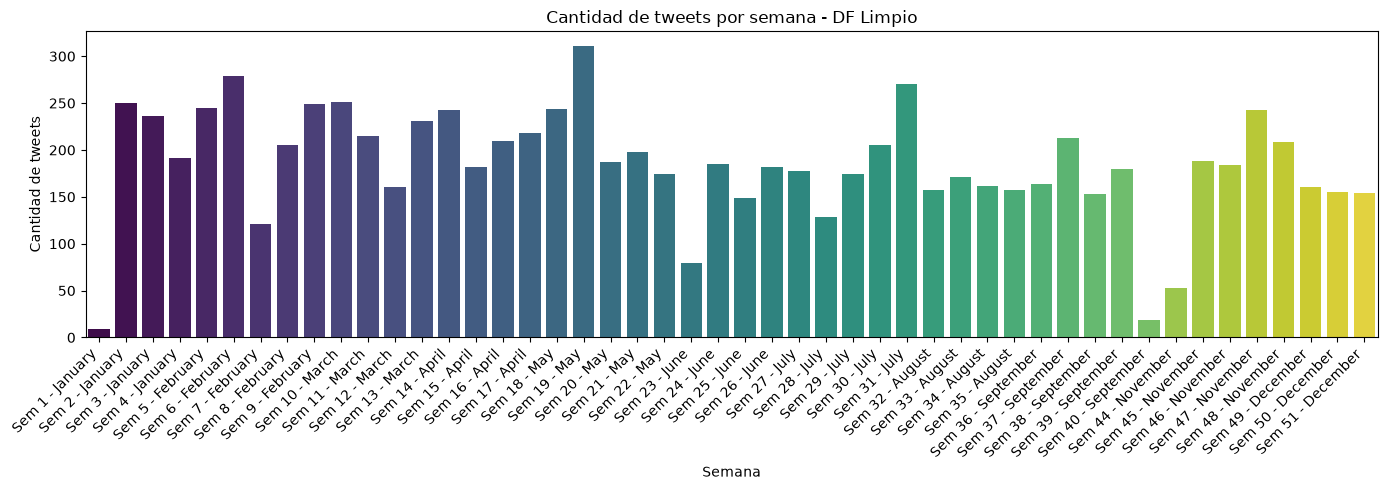

In [83]:
df_preproces_atipicos['semana'] = df_preproces_atipicos['date'].dt.isocalendar().week
df_preproces_atipicos['nombre_mes'] = df_preproces_atipicos['date'].dt.month_name()
mes_predominante2 = df_preproces_atipicos.groupby('semana')['nombre_mes'].agg(lambda x: x.mode().iloc[0])

cant_tweets2 = df_preproces_atipicos['semana'].value_counts().sort_index()
etiqueta2 = [f"Sem {semana} - {mes_predominante2.loc[semana]}" for semana in cant_tweets2.index]

plt.figure(figsize=(14, 5))
sns.barplot(x=cant_tweets2.index, y=cant_tweets2.values, palette='viridis', hue=cant_tweets2.index, legend=False )
plt.xticks(ticks=range(len(etiqueta2)), labels=etiqueta2, rotation=45, ha='right')
plt.xlabel('Semana')
plt.ylabel('Cantidad de tweets')
plt.title('Cantidad de tweets por semana - DF Limpio')
plt.tight_layout()
plt.show()

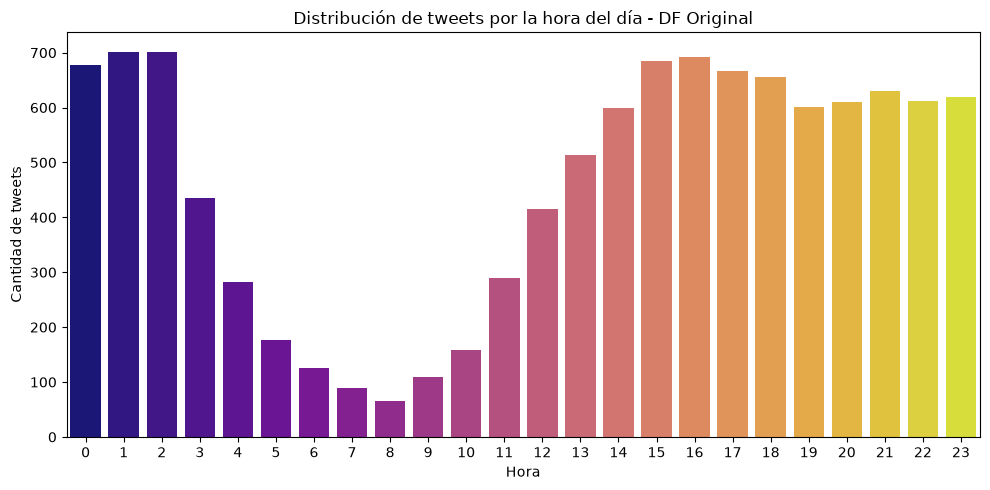

In [84]:
df['hora'] = df['date'].dt.hour
plt.figure(figsize=(10, 5))
sns.countplot(data= df, x='hora', palette='plasma', hue='hora', legend=False)
plt.xlabel('Hora')
plt.ylabel('Cantidad de tweets')
plt.title('Distribución de tweets por la hora del día - DF Original')
plt.tight_layout()
plt.show()

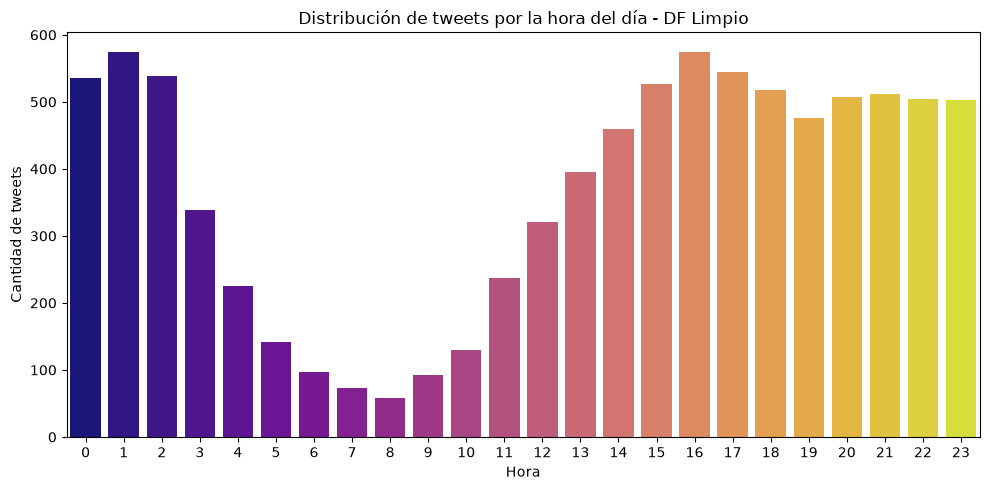

In [85]:
df_preproces_atipicos['hora'] = df_preproces_atipicos['date'].dt.hour
plt.figure(figsize=(10, 5))
sns.countplot(data= df_preproces_atipicos, x='hora', palette='plasma', hue='hora', legend=False)
plt.xlabel('Hora')
plt.ylabel('Cantidad de tweets')
plt.title('Distribución de tweets por la hora del día - DF Limpio')
plt.tight_layout()
plt.show()

In [86]:
df_preproces_atipicos.shape

(8882, 21)

Por medio de los distintos gráficos observamos que las distribuciones se mantienen igual solo que se reduce la cantidad de documentos, por ejemplo, el máximo de tweets por hora es casi 600 con el datasaet limpio, mientras que antes del proceso de eliminación era más de 700.

### Limpieza del cuerpo de texto

Para analizar el contenido de tipo texto es importante eliminar todo el ruido que puede dificultar la interpretación del mismo. En este punto será importante conocer sobre expresiones regulares y cómo funcionan. Pueden probar en [regexr](https://regexr.com/) o en [regex101](https://regex101.com/).

Se deberá generar una nueva columna en la base que considere el cuerpo de texto limpio. Para ello deberán eliminar del cuerpo de texto todo lo que consideran como ruido para su análisis posterior, justificando el por qué puede considerarse ruido o no. Usualmente se suelen eliminar símbolos o caracteres extraños, enlaces, nombres de usuarios, emojis, hashtags, entre otros.

**Dependencias**

Esta instalación se quitó de la notebook. La dependencia correspondiente está declarada en `requirements.txt`.

In [87]:
import re
import string
import emoji
from unidecode import unidecode

In [88]:
df_clean = df_preproces_atipicos.copy()
df_clean.shape

(8882, 21)

In [89]:
import re
import emoji
import pandas as pd

# Contadores para seguimiento (opcional)
counters = {
    'emojis_removed': 0,
    'punctuation_normalized': 0,
    'repeated_chars_normalized': 0,
    'mentions_removed': 0,
    'hashtags_removed': 0,
    'spaces_cleaned': 0,
    'laughter_standardized': 0,
    'gibberish_removed': 0
}

#Eliminación de Emoji
def remove_emojis(text):
    new_text = emoji.replace_emoji(text, replace='')
    if new_text != text:
        counters['emojis_removed'] += 1
    return new_text

#Eliminar signos de puntuación repetidos
def normalize_punctuation(text):
    new_text = re.sub(r'(\W)\1+', r'\1', text)
    if new_text != text:
        counters['punctuation_normalized'] += 1
    return new_text

#Se eliminan letras repetidas, como siiiiiii, hooollllaaaa:
def normalize_repeated_chars(text: str) -> str:
    """
    Reduce los caracteres repetidos en un texto, excepto los dígrafos
    válidos en español ('ll', 'rr', 'cc', 'nn').

    Ejemplos:
    - 'queee' -> 'que'
    - 'carrrro' -> 'carro'
    - 'acciooon' -> 'accion'
    """
    # Excepciones que permitimos que aparezcan duplicadas
    EXCEPCIONES = ('l', 'r', 'c', 'n')
    def _replacer(match):
        # El grupo 1 es el caracter, el grupo 2 es el resto de repeticiones
        char = match.group(1)
        # Si el caracter es una excepción, lo dejamos doble.
        if char.lower() in EXCEPCIONES:
            return char * 2
        # Si no, lo reducimos a uno solo.
        else:
            return char
    # El regex busca un caracter (.) seguido de una o más repeticiones de sí mismo (\1+)
    # y lo pasa a la función _replacer para que decida qué hacer.
    new_text = re.sub(r'([a-zA-ZáéíóúüñÁÉÍÓÚÜÑ])(\1+)', _replacer, text)
    if new_text != text:
        counters['repeated_chars_normalized'] += 1
    return new_text

# Eliminar Menciones
def remove_mentions(text):
    new_text = re.sub(r'@\w+', '', text)
    if new_text != text:
        counters['mentions_removed'] += 1
    return new_text

#Eliminar Hashtags
def remove_hashtags(text):
    new_text = re.sub(r'#\w+', '', text)
    if new_text != text:
        counters['hashtags_removed'] += 1
    return new_text

#Eliminar espacios extras
def clean_spaces(text):
    new_text = ' '.join(text.split())
    if new_text != text:
        counters['spaces_cleaned'] += 1
    return new_text

def standardize_laughter(text):
    pattern1 = r'([jh]+[aeiou]+([jh]+[aeiou]+)+)'
    pattern2 = r'([js]{4,})'
    laughter_pattern = re.compile(rf'\b({pattern1}|{pattern2})\b', re.IGNORECASE)
    new_text, count = laughter_pattern.subn('jaja', text)
    if count > 0:
        counters['laughter_standardized'] += 1
    return new_text

def remove_gibberish(text):
    consonants = "bcdfghjklmnpqrstvwxyz"
    pattern = rf'\b\w*[{consonants}]{{4,}}\w*\b'
    new_text, count = re.subn(pattern, '', text, flags=re.IGNORECASE)
    if count > 0:
        counters['gibberish_removed'] += 1
    return new_text


def clean_text_pipeline(text):
    text = remove_emojis(text)
    text = normalize_punctuation(text)
    text = normalize_repeated_chars(text)
    text = remove_mentions(text)
    text = remove_hashtags(text)
    text = clean_spaces(text)
    text = standardize_laughter(text)
    text = remove_gibberish(text)
    return text.strip()

# Aplicar al dataframe
df_clean['rawContent_clean'] = df_clean['rawContent_sin_link'].apply(clean_text_pipeline)

# Mostrar resumen
print("### Conteo de Modificaciones ###")
print(pd.Series(counters))


### Conteo de Modificaciones ###
emojis_removed               1047
punctuation_normalized       2131
repeated_chars_normalized    1023
mentions_removed                0
hashtags_removed              414
spaces_cleaned               2735
laughter_standardized         399
gibberish_removed             220
dtype: int64


In [90]:
import re
import emoji
import pandas as pd

# Cuenta el número exacto de emojis y los elimina
def remove_emojis(text):
    count = emoji.emoji_count(text)
    new_text = emoji.replace_emoji(text, replace='')
    return new_text, count

# Las siguientes funciones ya usan re.subn, que devuelve el conteo de reemplazos.
# Simplemente retornamos ese conteo directamente.
def normalize_punctuation(text):
    new_text, count = re.subn(r'(\W)\1+', r'\1', text)
    return new_text, count

def normalize_repeated_chars(text: str) -> str:
    EXCEPCIONES = ('l', 'r', 'c', 'n')
    def _replacer(match):
        char = match.group(1)
        if char.lower() in EXCEPCIONES:
            return char * 2
        else:
            return char
    new_text, count = re.subn(r'([a-zA-ZáéíóúüñÁÉÍÓÚÜÑ])(\1+)', _replacer, text)
    return new_text, count

def remove_mentions(text):
    new_text, count = re.subn(r'@\w+', '', text)
    return new_text, count

def remove_hashtags(text):
    new_text, count = re.subn(r'#\w+', '', text)
    return new_text, count

def standardize_laughter(text):
    pattern = re.compile(r'\b(([jh]+[aeiou]+([jh]+[aeiou]+)+)|([js]{4,}))\b', re.IGNORECASE)
    new_text, count = pattern.subn('jaja', text)
    return new_text, count

def remove_gibberish(text):
    consonants = "bcdfghjklmnpqrstvwxyz"
    pattern = rf'\b\w*[{consonants}]{{4,}}\w*\b'
    new_text, count = re.subn(pattern, '', text, flags=re.IGNORECASE)
    return new_text, count

# Para los espacios, la limpieza es una única acción normalizadora.
# Por eso, mantenemos el contador como 0 o 1.
def clean_spaces(text):
    new_text = ' '.join(text.split())
    return new_text, 1 if new_text != text else 0

def clean_text_and_get_stats(text):
    if not isinstance(text, str):
        text = ''

    stats = {}

    text, stats['emojis_removed'] = remove_emojis(text)
    text, stats['punctuation_normalized'] = normalize_punctuation(text)
    text, stats['repeated_chars_normalized'] = normalize_repeated_chars(text)
    text, stats['mentions_removed'] = remove_mentions(text)
    text, stats['hashtags_removed'] = remove_hashtags(text)
    text, stats['laughter_standardized'] = standardize_laughter(text)
    text, stats['gibberish_removed'] = remove_gibberish(text)
    text, stats['spaces_cleaned'] = clean_spaces(text)

    stats['total_changes'] = sum(stats.values())
    stats['rawContent_clean'] = text.strip()

    return pd.Series(stats)

# DataFrame de ejemplo con un caso más complejo
df_to_get_example = df_clean.copy()
df_to_get_example.drop(columns=['rawContent_clean'], errors='ignore', inplace=True)

# Aplicar la función y unir los resultados (mismo código de antes)
cleaning_results = df_to_get_example['rawContent_sin_link'].apply(clean_text_and_get_stats)
examples_df = df_to_get_example.join(cleaning_results)

examples_df.sort_values(by='total_changes', ascending=False)

,id_str,date,rawContent,replyCount,retweetCount,likeCount,quoteCount,conversationId,hashtags,viewCount,...,emojis_removed,punctuation_normalized,repeated_chars_normalized,mentions_removed,hashtags_removed,laughter_standardized,gibberish_removed,spaces_cleaned,total_changes,rawContent_clean
3062,1777678521764098264,2024-04-09 12:42:41,"¡Buen martes!\n\n5 Tips si tenés SOBREPESO u OBESIDAD.\n\nNo te olvides de seguirme en Instagram para más info.\n\nlink_url\n\n1• Si tenés problemas de sobrepeso u obesidad a raíz de grandes ingestas o picoteos, procurá no estar viendo todo el día recetas de comida o información sobre alimentos. Esto potenciará el ciclo estimulo recompensa que te lleva a estar buscando y a obsesionarte por los alimentos. Solo favorecerá que estés obsesionado/a por la próxima comida.\n\n2•No abuses de las gaseosas sin azúcar, más allá del efecto de las aguas carbonatadas sobre tu aparato óseo y renal a largo plazo, recordá que para disminuir el consumo de dulces y carbograsas debemos erradicar la ingesta permanente de sabores dulces, independientemente de la densidad calórica de ese alimento.\n\n3•Si querés “aumentar” tu metabolismo es más sencillo de lo que vos pensás: evitá estar sentado más de media hora, aunque sea tratá de ponerte de pie y hacer algo de estiramiento, esto te ayudará a aumentar el consumo metabólico basal. Caminá en lugar de enviar un WhatsApp u optá por una escalera común en lugar de una mecánica. Reemplaza escaleras por el ascensor.\nBebé abundantes líquidos [agua]: recordar que el simple hecho de beber agua consume energía, aun cuando sea insignificante. Esto, prolongado el tiempo, irá contribuyendo a tu metabolismo basal. Por supuesto, además, te mantendrá hidratado. 💧 \n\n4• Comenzar a comer conscientemente, saboreando la comida, evaluando los olores. De manera ordenada. Importante prestarle atención al acto de comer sin caer en distracciones.\n📺 📱 \n\n5•En caso de tener transgresiones permanentes o atracones, hacé un registro de esos alimentos consumidos e intentá encontrar una relación con las emociones de ese día. Te ayudará, no solo a tomar conciencia de lo que te pasa y a explicar el por qué la comida te sirve como vía de escape, sino a tratar de encontrar una solución a estas dolencias que a largo plazo resultan en un mal hábito para tu salud. Recordá que siempre se recomienda transitar este proceso con ayuda psicológica. 🧠 \n\n¡Gracias por leer! 📖 👓 \n\nNos vemos mañana con más consejos. ⌛️ 🥗",2,10,69.00,1,1777678521764098264,[],"5,295.00",...,8,15,8,0,0,0,1,1,33,"¡Buen martes! 5 Tips si tenés SOBREPESO u OBESIDAD. No te olvides de seguirme en Instagram para más info. 1• Si tenés problemas de sobrepeso u obesidad a raíz de grandes ingestas o picoteos, procurá no estar viendo todo el día recetas de comida o información sobre alimentos. Esto potenciará el ciclo estimulo recompensa que te lleva a estar buscando y a obsesionarte por los alimentos. Solo favorecerá que estés obsesionado/a por la próxima comida. 2•No abuses de las gaseosas sin azúcar, más allá del efecto de las aguas carbonatadas sobre tu aparato óseo y renal a largo plazo, recordá que para disminuir el consumo de dulces y carbograsas debemos erradicar la ingesta permanente de sabores dulces, independientemente de la densidad calórica de ese alimento. 3•Si querés “aumentar” tu metabolismo es más sencillo de lo que vos pensás: evitá estar sentado más de media hora, aunque sea tratá de ponerte de pie y hacer algo de estiramiento, esto te ayudará a aumentar el consumo metabólico basal. Caminá en lugar de enviar un WhatsAp u optá por una escalera común en lugar de una mecánica. Remplaza escaleras por el ascensor. Bebé abundantes líquidos [agua]: recordar que el simple hecho de beber agua consume energía, aun cuando sea insignificante. Esto, prolongado el tiempo, irá contribuyendo a tu metabolismo basal. Por supuesto, además, te mantendrá hidratado. 4• Comenzar a comer conscientemente, saboreando la comida, evaluando los olore

In [91]:
examples_df.columns

Index(['id_str', 'date', 'rawContent', 'replyCount', 'retweetCount',
       'likeCount', 'quoteCount', 'conversationId', 'hashtags', 'viewCount',
       'pcia', 'mes', 'user_id', 'pcia1', 'hashtags1', 'containKeyword',
       'idioma_lingua', 'rawContent_sin_link', 'semana', 'nombre_mes', 'hora',
       'emojis_removed', 'punctuation_normalized', 'repeated_chars_normalized',
       'mentions_removed', 'hashtags_removed', 'laughter_standardized',
       'gibberish_removed', 'spaces_cleaned', 'total_changes',
       'rawContent_clean'],
      dtype='str')

In [92]:
examples_df[['rawContent', 'rawContent_clean', 'total_changes', 'emojis_removed', 'punctuation_normalized', 'repeated_chars_normalized',
       'mentions_removed', 'hashtags_removed', 'laughter_standardized',
       'gibberish_removed', 'spaces_cleaned']].sort_values(by='gibberish_removed', ascending=False).head(50)

,rawContent,rawContent_clean,total_changes,emojis_removed,punctuation_normalized,repeated_chars_normalized,mentions_removed,hashtags_removed,laughter_standardized,gibberish_removed,spaces_cleaned
8,y claro con razón el médico me dice obeso alsbskbdksjdid como q tengo q pesar 52 kg ajdhksbdksjs hdps,y claro con razón el médico me dice obeso como q tengo q pesar 52 kg,4,0,0,0,0,0,0,3,1
2270,"No creo que te quieran cojer jdkfkf \nCon obesidad, severos problemas mentales a la vista y siendo feminista kdfjfj no creo que nadie te la quiera poner jkdkf","No creo que te quieran cojer Con obesidad, severos problemas mentales a la vista y siendo feminista no creo que nadie te la quiera poner",4,0,0,0,0,0,0,3,1
7020,Es Maltrato animal!!! Cómo un obeso-Monstruo pretende subirse con sus 300 kg.a un pobre animal que evidentemente sus patas no toleran ese peso brutal del tipo-Monstruo😡,Es Maltrato animal! Cómo un obeso- pretende subirse con sus 300 kg.a un pobre animal que evidentemente sus patas no toleran ese peso brutal del tipo-,4,1,1,0,0,0,0,2,0
3874,Dios el hecho de q la de sex in the city toda despeinada sin cintura con bermudas verdes que le llegan a las pantorrillas era hot y hoy en dia si no sos belle dellphine sos una ogra obesa cara pateada q momento asqueroso para existir y dsps rompen las pelotas con el heroin chic,Dios el hecho de q la de sex in the city toda despeinada sin cintura con bermudas verdes que le llegan a las pantorrillas era hot y hoy en dia si no sos belle sos una ogra obesa cara pateada q momento asqueroso para existir y rompen las pelotas con el heroin chic,8,0,0,5,0,0,0,2,1
503,"Gorda construye deberías llamarte, construirte tu cuerpo todo obeso. Gorda con IMC superior al normal. Gorda de mierda, Gorda olor a ojete, Gorda pelotuda, Gorda inmunda, Gorda","Gorda deberías llamarte, tu cuerpo todo obeso. Gorda con IMC superior al normal. Gorda de mierda, Gorda olor a ojete, Gorda pelotuda, Gorda inmunda, Gorda",4,0,0,1,0,0,0,2,1
5856,"No tiene nada que ver ser obeso con no menstruar,hay chicas que son más que yo y menstruan 😘","No tiene nada que ver ser obeso con no ,hay chicas que son más que yo y",4,1,0,0,0,0,0,2,1
8566,"•IMPORTANTE:\n\n-Menos del 10% de los pacientes puede no experimentar perdida de peso a pesar de tener efectos adversos.\n\n•Se llevó a desarrollar un test genético •MyPhenomo• para identificar fenotipos de obesidad que no responden al tratamiento. En pacientes con el fenotipo HG+, se observó una mayor pérdida de peso con semaglutida.\n\nLos EFECTOS SECUNDARIOS más comunes: náuseas, diarrea, vómitos y estreñimiento, generalmente al inicio del tratamiento. Otros efectos má graves: PANCREATITIS, obstrucciones intestinales y enfermedades biliares. También se advirtieron vínculos con ciertos tipos de CÁNCER, aunque con datos inconsistentes. En algunos casos, se han reportado pérdidas de masa muscular magra, especialmente en personas mayores o con enfermedades crónicas.\n\n•Contraindicados: CÁNCER MEDULAR de TIROIDES o PANCREATITIS PREVIA.\n\n•Embarazo/ lactancia\n\n•Enfermedad gastrointestinal severa, por ej: úlcera gastroduodenal.\n\n•Insuficiencia renal grave: indice de filtración menor a 30 ml/min.\n\nSEGUIR…\n👇\n\nlink_url.","•IMPORTANTE: -Menos del 10% de los pacientes puede no experimentar perdida de peso a pesar de tener efectos adversos. •Se llevó a desarrollar un test genético •• para identificar fenotipos de obesidad que no responden al tratamiento. En pacientes con el fenotipo HG+, se observó una mayor pérdida de peso con semaglutida. Los EFECTOS SECUNDARIOS más comunes: náuseas, diarrea, vómitos y estreñimiento, generalmente al inicio del tratamiento. Otros efectos má graves: PANCREATITIS, intestinales y enfermedades biliares. También se advirtieron vínculos con ciertos tipos de CÁNCER, aunque con datos inconsistentes. En algunos casos, se han reportado pérdidas de masa muscular magra, especialmente en personas mayores o con enfermedades crónicas. •Contraindicados: CÁNCER MEDULAR de TIRO

In [93]:
df_clean['rawContent_clean'].head(3)

0    Boluda ahí dice que yo debería pesar 43kg eso está para el orto. Yo sé que tengo sobrepeso y por eso estoy empezando a cuidarme más para bajar de peso, por mi altura mi peso ideal sería 64
1                                                                    Jugador de +30 años, vendehumo, con tendencias a lesionarse, con sobrepeso, tribunero y cabaretero. Nació para jugar en boca
2                                                                                                                               La tabla de mi pediatra cuando tenia 6 años y me decía obesa jaja
Name: rawContent_clean, dtype: str

### Creación y transformación de variables

Para conocer en mayor profundidad el conjunto de datos de texto (corpus) con el que estamos trabajando, es importante aplicar diversas técnicas básicas de procesamiento del lenguaje natural (NLP), las cuáles pueden aportar información valiosa. En el Práctico 1, identificar las palabras más frecuentes resultó útil; sin embargo, muchas otras palabras que describen con mayor precisión el contenido de las publicaciones pueden tener baja frecuencia o pasar desapercibidas en un análisis superficial.

Por esta razón, es habitual aplicar técnicas como la lematización, que permiten unificar distintas formas flexionadas de una misma palabra (por ejemplo, singular/plural o masculino/femenino), facilitando una representación más coherente del contenido textual.

Además, al aplicar el análisis gramatical propio del NLP, podemos reconocer las categorías gramaticales presentes en los textos, como sustantivos, adjetivos y verbos, entre otras. Esto puede enriquecer la comprensión del corpus y abrir nuevas posibilidades de análisis.

A partir de estas ideas, se proponen los siguientes ejercicios:

#### Ejercicio 3: **Exploración básica con NLP**

- a. Usar una librería de procesamiento de lenguaje natural que sea compatible con corpus en español para procesar el texto de los tweets. Deberán generar una nueva variable en la base de datos que contenga únicamente los términos pertenecientes a una categoría gramatical de su elección. Por ejemplo: una columna llamada "sustantivos", que incluya todos los sustantivos reconocidos en cada tweet.

  Es importante seleccionar y justificar:  la librería utilizada, y el modelo de lenguaje elegido (por ejemplo, es_core_news_sm en spaCy).

*Deberán decidir si aplican el procesamiento NLP sobre el texto limpio o sobre el texto crudo del tweet, y explicar las razones de esa elección.*

- b. Aplicar lematización a los términos reconocidos en la categoría gramatical seleccionada, generando una nueva variable con los términos lematizados. Observar y comparar los términos más frecuentes en esta categoría, tanto en su forma lematizada como sin lematizar. Finalmente, reflexionar sobre cuál de las dos representaciones elegirían para describir el dataset y justificar la elección.
- c. Discutir cómo podría aprovecharse esta información en tareas como análisis de sentimientos, detección de tópicos o predicción de engagement.

#### Ejercicio 4: **Transformar variables**

- a. Identificar columnas que necesiten transformación para ser usadas en modelos de ML (por ejemplo, fechas, categorías, frecuencias absolutas, etc.). *En este punto se espera ver el uso de técnicas de transformación de datos en al menos dos variables. Esto debe realizarse más allá de si será la variable utilizada a futuro*
- b. Generar nuevas variables a partir de los aspectos mencionados en el práctico 1. Por ejemplo, sentimiento asociado a las publicaciones (análisis de sentimiento).
- c. Convertir variables categóricas en variables numéricas (por ejemplo, usando codificación one-hot o label encoding).


#### Exploración básica con NLP

##### Selección de librería y modelo para POS tagging

Para procesar el texto de los tweets y obtener las categorías gramaticales de las palabras, se eligió la librería spaCy junto con el modelo preentrenado es_core_news_lg, ya que ofrece una solución robusta y eficiente para el análisis lingüístico de textos en español. Este modelo permite identificar de forma precisa las partes del discurso (POS tagging), como sustantivos, verbos, adjetivos y adverbios, lo cual resulta fundamental para extraer información relevante de los textos.

La librería Spacy provee una serie de modelos ya entrenados y pipelines que los utilizan. Al ejecutar `spacy.load("es_core_news_lg")` lo que hacemos es cargar el pipeline con los modelos que ya hemos descargado. En este caso los componentes del pipeline son: `['tok2vec', 'morphologizer', 'parser', 'attribute_ruler', 'lemmatizer', 'ner']`. Cada uno de estos componentes que transforman el documento tiene utiliza los siguientes modelos:
- tok2vec: spacy.Tok2Vec.v2 (una red que crea los embeddings de palabras contextuales)
- morphologizer: spacy.Tagger.v2
- parser: spacy.TransitionBasedParser.v2
- attribute_ruler: (No model architecture)
- lemmatizer: (No model architecture)
- ner: spacy.TransitionBasedParser.v2

Por ejemplo, en el caso de Tok2Vec, la documentación de la arquitectura dice lo siguiente: "Construct a tok2vec model out of two subnetworks: one for embedding and one for encoding." Recomiendan revisar este [link](https://explosion.ai/blog/deep-learning-formula-nlp) en donde dice lo siguiente: "After embedding the text into a sequence of vectors, bidirectional RNNs are used to encode the vectors into a sentence matrix. The rows of this matrix can be understood as token vectors — they are sensitive to the sentential context of the token." El componente tok2vec funciona en dos pasos principales:
- Sub-red de Embedding (Embed): Su único trabajo es convertir cada token (palabra) en un vector numérico inicial. Este vector no tiene contexto de la frase; es como una ficha de diccionario para esa palabra. CharacterEmbed y MultiHashEmbed son ejemplos de arquitecturas para este paso.
- Sub-red de Encoding (Encode): Esta red toma la secuencia completa de vectores iniciales y los procesa para inyectarles el contexto. Analiza las palabras vecinas para modificar el vector de cada palabra. El resultado es el embedding contextual final. MaxoutWindowEncoder es la arquitectura que hace este trabajo.

El paquete cargado "es_core_news_lg" utiliza modelos entrenados en textos escritos, en particular noticias. Elegir este modelo es una cuestión de facilidad en el uso y de que para tareas de reconocimienton de partes de la oración reportan un accuracy alto, aunque no dicen con qué dataset se evaluó esta tarea. Sin embargo, encontramos una diferencia de dominio de los datos, puesto que nuestros textos provienen de Twitter que suele tener una forma de escribir más coloquial que las noticias.

Por último, SpaCy usa [etiquetas universales](https://universaldependencies.org/u/pos/NOUN.html) (NOUN, VERB, ADJ, etc.) y provee también atributos morfológicos si se requiere análisis profundo.

NER-Tagging (Named Entity Recognition)

NER identifica y clasifica entidades con nombre (como personas, organizaciones y ubicaciones) en el texto. Esto es valioso para la extracción de información y puede proporcionar contexto para el modelado de temas.

Se elige su uso porque consideramos que es útil de identificar automáticamente nombres de personas, lugares, organizaciones, fechas u otros elementos relevantes dentro de los tweets. Esto ayuda a entender mejor de qué o quiénes se está hablando, se puede identificar automáticamente si se mencionan personas (figuras públicas), lugares (como provincias o ciudades donde se habla más del tema) o instituciones. Esto ayuda a entender mejor el contexto de las conversaciones y a ver qué actores o regiones están más presentes. Además, estas entidades pueden aportar información extra para hacer análisis más completos, por ejemplo, para ver si ciertos lugares o personas están relacionados con opiniones positivas o negativas sobre la obesidad.

Además de Spacy, probaremos con la librería pysentimiento que provee un modelo de transformers basado en la arquitectura RoBERTa, que ha sido entrenado con un corpus de tweets en español y a su vez afinado para resolver tareas de POS tagging.

Para el caso de Spacy aplicaremos el análisis sobre el texto limpio, con la esperanza de que las normalizaciones realizadas ayuden al reconocimiento de los sustantivos. En el caso de Robertuito utilizaremos el texto sin modificaciones ya que este modelo fue entrenado con texto de twitter, además nos interesa comparar los resultados y ver si hay diferencias significativas.

**Dependencias**

Esta instalación se quitó de la notebook. La dependencia correspondiente está declarada en `requirements.txt`.

In [94]:
import spacy

nlp = spacy.load("es_core_news_lg")

In [95]:
print(f"Pipeline components: {nlp.pipe_names}\n")

Pipeline components: ['tok2vec', 'morphologizer', 'parser', 'attribute_ruler', 'lemmatizer', 'ner']



In [96]:
print("Architectures per component:")
for component_name in nlp.pipe_names:
    # Acceder a la configuración de cada componente
    component_config = nlp.config["components"][component_name]

    # La arquitectura del modelo se encuentra en la sección "model"
    # La clave suele ser "@architectures"
    if "model" in component_config and component_config["model"] is not None and "@architectures" in component_config["model"]:
        architecture = component_config["model"]["@architectures"]
        print(f"- {component_name}: {architecture}")
    else:
        # Algunos componentes como 'attribute_ruler' no tienen un modelo de red neuronal
        print(f"- {component_name}: (No model architecture)")

Architectures per component:
- tok2vec: spacy.Tok2Vec.v2
- morphologizer: spacy.Tagger.v2
- parser: spacy.TransitionBasedParser.v2
- attribute_ruler: (No model architecture)
- lemmatizer: (No model architecture)
- ner: spacy.TransitionBasedParser.v2


In [97]:
# Listas para guardar todos los resultados
tokens_list = []
sents_list = []
nouns_list = []
nouns_lemma_list = []
verbs_list = []
adverbs_list = []
adjectives_list = []
adjectives_lemma_list = []
ner_list = []

from collections import Counter
bad = Counter()

for doc in nlp.pipe(df_clean['rawContent_clean']):
    # Extraer tokens y oraciones
    tokens_list.append([token.text for token in doc])
    sents_list.append([sent.text for sent in doc.sents])
    ner_list.append([ent.text for ent in doc.ents])

    # Extraer POS y lemas (esto ya lo tenías)
    nouns_list.append([token.text for token in doc if token.pos_ == 'NOUN'])
    nouns_lemma_list.append([token.lemma_ for token in doc if token.pos_ == 'NOUN'])
    verbs_list.append([token.text for token in doc if token.pos_ == 'VERB'])
    adjectives_list.append([token.text for token in doc if token.pos_ == 'ADJ'])
    adjectives_lemma_list.append([token.lemma_ for token in doc if token.pos_ == 'ADJ'])
    adverbs_list.append([token.text for token in doc if token.pos_ == 'ADV'])
    for token in doc:
      if token.pos_ == "ADJ":
          # heurística: lema no comparte raíz clara con la forma token
          t = token.text.lower()
          l = token.lemma_.lower()
          if not (l.startswith(t[:3]) or t.startswith(l[:3]) or l.endswith("o") or l.endswith("a")):
              bad[(token.text, token.lemma_)] += 1

for (t,l),cnt in bad.most_common(50):
    print(cnt, t, "->", l)

# Asignar todas las listas a las nuevas columnas del DataFrame
df_clean['tokens'] = tokens_list
df_clean['sentences'] = sents_list
df_clean['entidades'] = ner_list

df_clean['sustantivos'] = nouns_list
df_clean['sustantivos_lematizados'] = nouns_lemma_list
df_clean['verbos'] = verbs_list
df_clean['adjetivos'] = adjectives_list
df_clean['adjetivos_lematizados'] = adjectives_lemma_list
df_clean['adverbios'] = adverbs_list

868 obesa -> obés
11 jóvenes -> joven
4 esa -> és
3 grasa -> grás
2 afines -> afín
1 ilusa -> ilús
1 grosa -> grós
1 avena -> avén
1 mona -> món
1 lana -> lán


In [98]:
print("spaCy:", spacy.__version__)
print("Modelo:", nlp.meta.get("name"), nlp.meta.get("version"))
print("Pipeline:", nlp.pipe_names)
# inspeccionar un token ejemplo
doc = nlp("Es obesa")
for token in doc:
    print(token.text, token.pos_, token.tag_, token.lemma_, token.morph)

spaCy: 3.8.15
Modelo: core_news_lg 3.8.0
Pipeline: ['tok2vec', 'morphologizer', 'parser', 'attribute_ruler', 'lemmatizer', 'ner']
Es AUX AUX ser Mood=Ind|Number=Sing|Person=3|Tense=Pres|VerbForm=Fin
obesa ADJ ADJ obés Gender=Fem|Number=Sing


In [99]:
mapa_correcciones = {
    'obés': 'obeso',
    'grás': 'grasa',
    'ilús': 'iluso',
    'grós': 'groso',
    'avén': 'avena',
    'món': 'mono',
    'lán': 'lana'
}


# corrección
df_clean['adjetivos_lematizados'] = df_clean['adjetivos_lematizados'].apply(
    lambda lista_lemas: [mapa_correcciones.get(lema, lema) for lema in lista_lemas]
)

El lematizador tiene algún problema con algunas de las palabras (en principio parece que adjetivos) terminadas en a, así que hemos reemplazado esos errores luego del uso de la librería para encontrar los adjetivos lematizados.

In [100]:
df_clean[['rawContent_clean', 'tokens', 'sustantivos', 'verbos', 'adjetivos', 'adverbios', 'entidades']].sample(5)

,rawContent_clean,tokens,sustantivos,verbos,adjetivos,adverbios,entidades
5835,acá la obesa q representó a Jesús,"[acá, la, obesa, q, representó, a, Jesús]",[obesa],[representó],[],[acá],"[obesa q, Jesús]"
1237,Que ganas d jugar un fulbo loko y estos obesos d mierda no pueden cordinar UN día,"[Que, ganas, d, jugar, un, fulbo, loko, y, estos, obesos, d, mierda, no, pueden, cordinar, UN, día]","[ganas, d, fulbo, obesos, d, mierda, día]","[jugar, cordinar]",[],[no],"[loko, UN día]"
5751,La verdad cuando decian gordo dan me lo imaginaba a dan hibiki de sf pero en obeso jajaj,"[La, verdad, cuando, decian, gordo, dan, me, lo, imaginaba, a, dan, hibiki, de, sf, pero, en, obeso, jajaj]","[verdad, gordo, hibiki, obeso]","[decian, dan, imaginaba, dan]",[],[],[sf]
2877,CHE . VOS NO ESTAS ARREPENTIDO . POR LO QUE VEO VOS ESTAS OBESO . PERO ESTAS MUY ENOJADO PORQUE ? ES LOGIKO ¿TE SACARON UN KURRO ? Y AHORA TE HACES GOLPISTA DE UNA !,"[CHE, ., VOS, NO, ESTAS, ARREPENTIDO, ., POR, LO, QUE, VEO, VOS, ESTAS, OBESO, ., PERO, ESTAS, MUY, ENOJADO, PORQUE, ?, ES, LOGIKO, ¿, TE, SACARON, UN, KURRO, ?, Y, AHORA, TE, HACES, GOLPISTA, DE, UNA, !]","[ARREPENTIDO, HACES]","[LO, SACARON, TE]","[VOS, ENOJADO]","[NO, MUY, AHORA]","[CHE, POR LO, VEO, ESTAS OBESO, PERO, ENOJADO PORQUE ?, KURRO, Y AHORA TE HACES GOLPISTA DE UNA]"
175,"Ni siquiera contrataron a alguien con sobrepeso, eran todos cuerpos flacos","[Ni, siquiera, contrataron, a, alguien, con, sobrepeso, ,, eran, todos, cuerpos, flacos]","[siquiera, sobrepeso, cuerpos]",[contrataron],[flacos],[],[]


In [101]:
columnas_a_procesar = ['tokens', 'sustantivos', 'verbos', 'adjetivos', 'adverbios', 'entidades']
top_n = 20
resultados = {}

for col in columnas_a_procesar:
    # Explode para separar los elementos, dropna para limpiar nulos
    # value_counts para contar, y head para obtener el top N
    counts = df_clean[col].explode().dropna().value_counts().head(top_n)

    # Crea las tuplas (elemento, cantidad) y las guarda en el diccionario
    if not counts.empty:
        resultados[col] = list(zip(counts.index, counts.values))
    else:
        # Si no hay elementos, guarda una lista vacía
        resultados[col] = []

# Convierte el diccionario a un DataFrame.
# Las listas de diferente longitud se rellenan con NaN automáticamente.
df_final = pd.DataFrame(dict([(k, pd.Series(v)) for k, v in resultados.items()]))

df_final

,tokens,sustantivos,verbos,adjetivos,adverbios,entidades
0,"(,, 8964)","(obesidad, 2237)","(tiene, 697)","(obeso, 1291)","(no, 3647)","(Argentina, 72)"
1,"(de, 8892)","(sobrepeso, 1510)","(tener, 350)","(obesa, 868)","(más, 894)","(q, 63)"
2,"(., 8098)","(gordura, 721)","(hace, 319)","(gorda, 383)","(No, 801)","(Obeso, 52)"
3,"(que, 6891)","(obeso, 494)","(tienen, 282)","(gordo, 352)","(ya, 336)","(Obesa, 49)"
4,"(la, 6208)","(gente, 450)","(tengo, 265)","(obesos, 347)","(bien, 318)","(jaja, 45)"
5,"(y, 5439)","(obesa, 434)","(hacer, 253)","(mórbida, 217)","(así, 267)","(Milei, 43)"
6,"(a, 4210)","(peso, 380)","(comer, 234)","(obesas, 158)","(mas, 247)","(La obesidad, 43)"
7,"(no, 3680)","(años, 335)","(ver, 232)","(mejor, 149)","(muy, 244)","(OBESO, 41)"
8,"(el, 3548)","(persona, 289)","(dice, 181)","(bueno, 121)","(mal, 242)","(Ahora, 39)"
9,"(es, 3170)","(salud, 272)","(decir, 157)","(solo, 103)","(menos, 212)","(OBESA, 37)"


A partir de este procesamiento, se generaron nuevas columnas que contienen únicamente los términos pertenecientes a cada categoría gramatical, lo cual permitirá explorar con mayor profundidad el contenido semántico y estructural de los tweets. Por ejemplo, permitiría explorar qué sustantivos o adjetivos aparecen con mayor frecuencia en tuits negativos o positivos.

In [102]:
from pysentimiento import create_analyzer
from pysentimiento.preprocessing import preprocess_tweet
pos_analyzer = create_analyzer(task="pos", lang="es")

config.json:   0%|          | 0.00/1.39k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  433MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/330 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/829k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

In [103]:
def safe_extract_nouns_robertuito(texto):
    """
    Procesa un texto con RoBERTuito POS tagging, aplicando preprocesamiento
    y manejo de errores. Devuelve una lista de sustantivos o [] si falla.
    """
    if not isinstance(texto, str) or texto.strip() == "":
        return []

    try:
        preprocessed = preprocess_tweet(texto)
        result = pos_analyzer.predict(preprocessed)

        if result.labels is None or result.tokens is None:
            return []

        # Filtra solo tokens etiquetados como NOUN
        return [
            token for token, label in zip(result.tokens, result.labels)
            if label == 'NOUN'
        ]

    except Exception as e:
        print(f"Error procesando texto: {texto[:100]}... -> {e}")
        return []

In [104]:
make_prediction = False
if make_prediction:
  df_clean['sustantivos_robertuito'] = df_clean['rawContent_sin_link'].apply(safe_extract_nouns_robertuito)
  df_clean[['id_str', 'sustantivos_robertuito']].to_csv(PROCESSED_DIR / 'sustantivos_robertuito.csv', index=False)
else:
  import ast
  nouns_df = pd.read_csv(PROCESSED_DIR / 'sustantivos_robertuito.csv')
  nouns_df['sustantivos_robertuito'] = nouns_df['sustantivos_robertuito'].apply(ast.literal_eval)
  df_clean = pd.merge(df_clean, nouns_df, on='id_str')

In [105]:
df_clean['sustantivos_robertuito'].explode().value_counts().head(20)

sustantivos_robertuito
obesidad      2198
emoji         1864
sobrepeso     1500
               747
gordura        720
cara           478
gente          447
peso           346
años           324
persona        303
salud          302
hashtag        291
risa           270
vida           259
enfermedad     258
mierda         243
personas       237
problema       196
cuerpo         190
vez            189
Name: count, dtype: int64

##### Lematización y comparación de términos

Revisaremos la lematización realizada por Spacy para los sustantivos y adjetivos:

In [106]:
df_clean[['rawContent_clean', 'sustantivos', 'sustantivos_lematizados', 'adjetivos', 'adjetivos_lematizados']].sample(10)

,rawContent_clean,sustantivos,sustantivos_lematizados,adjetivos,adjetivos_lematizados
4333,"q deforme los osos pandas, no? un animal casi obeso q no puede moverse normal","[osos, animal]","[oso, animal]","[pandas, obeso, normal]","[panda, obeso, normal]"
624,"No hay debate, pago los asientos son suyos lo que dure el vuelo, lo de ""obesa"" innecesario, la señora sabe que es obesa pero aunque fuese heidi Klum si compra dos asientos para estirar las piernas son sus asientos igual.","[debate, pago, asientos, vuelo, obesa, señora, asientos, piernas, asientos]","[debate, pago, asiento, vuelo, obesa, señora, asiento, pierna, asiento]","[innecesario, obesa, heidi, igual]","[innecesario, obeso, heidi, igual]"
3473,El morbo. Llamo a los obesos de mil quinientos formas desagradables y la siguen. Les gusta dar lástima. Pobres mentes obesas.,"[morbo, obesos, formas, lástima, mentes]","[morbo, obeso, forma, lástima, mente]","[desagradables, Pobres, obesas]","[desagradable, pobre, obesa]"
2517,"No tiene ni idea lo que es la obesidad claramente. Están en un reality, si no tiene ganas de entrenar es obesa entonces? Mamita","[idea, obesidad, reality, ganas]","[idea, obesidad, reality, gana]",[obesa],[obeso]
3210,"Voy a decir algo y me hago cargo también, pero hay que dejar de prestarle atención porque con tantas interacciones está comiendo gracias a nosotros y no vale la pena que Pepa pig no labure. Que transpire ese ogt con adiposidad para ganarse el mango.","[cargo, atención, interacciones, gracias, pena, adiposidad, mango]","[cargo, atención, interacción, gracias, pena, adiposidad, mango]",[],[]
8200,Q feliz soy comiendo en otra vida debi ser obesa,"[Q, vida]","[q, vida]","[feliz, obesa]","[feliz, obeso]"
4763,q onda como hace para comer asi con los precios de la comida? Este si no fuera obeso seria millonario,"[q, onda, precios, comida]","[q, onda, precio, comida]","[obeso, seria, millonario]","[obeso, serio, millonario]"
2152,Como me gusta comer PAN loco estoy destinada a ser obesa toda la vida,[vida],[vida],"[loco, destinada, obesa]","[loco, destinado, obeso]"
1597,Contexto de por qué estoy tan OBESA,[],[],[],[]
1918,"Wegovy [semaglutide 2.4 mg] fue aprobado por la FDA para reducir riesgo de eventos cerebro y cardiovasculares en pacientes con sobrepeso y obesidad. En Argentina, ANMAT aprobó el fármaco como medicamento para bajar de peso en agosto de 2023. Se estimaba que llegaría a nuestro país en agosto de este año, aunque la compañía Novo Nordisk (Dinamarca) está teniendo serios problemas de producción y distribución a nivel global.","[[, mg, riesgo, eventos, cerebro, cardiovasculares, pacientes, sobrepeso, obesidad, fármaco, medicamento, peso, agosto, país, agosto, año, compañía, problemas, producción, distribución, nivel]","[[, mg, riesgo, evento, cerebro, cardiovascular, paciente, sobrepeso, obesidad, fármaco, medicamento, peso, agosto, país, agosto, año, compañía, problema, producción, distribución, nivel]","[serios, global]","[serio, global]"


In [107]:
from collections import Counter

# Sustantivos sin lematizar:
sustantivos_sin_lematizar = sum(df_clean['sustantivos'], [])
cant_sin_lema = Counter(sustantivos_sin_lematizar)
print(f'Top 10 sustantivos sin lematizar:\n {cant_sin_lema.most_common(10)}')

# Sustantivos lematizados:
sustantivos_lematizados = sum(df_clean['sustantivos_lematizados'], [])
cant_con_lema = Counter(sustantivos_lematizados)
print(f'\nTop 10 sustantivos lematizados:\n {cant_con_lema.most_common(10)}')

Top 10 sustantivos sin lematizar:
 [('obesidad', 2237), ('sobrepeso', 1510), ('gordura', 721), ('obeso', 494), ('gente', 450), ('obesa', 434), ('peso', 380), ('años', 335), ('persona', 289), ('salud', 272)]

Top 10 sustantivos lematizados:
 [('obesidad', 2329), ('sobrepeso', 1534), ('gordura', 731), ('obeso', 713), ('persona', 550), ('gente', 460), ('obesa', 459), ('año', 409), ('problema', 390), ('peso', 386)]


In [108]:
import plotly.express as px

sust_sin_lema = cant_sin_lema.most_common(10)
palabras_sin_lema = [x[0] for x in sust_sin_lema]
frecuencias_sin_lema = [x[1] for x in sust_sin_lema]

fig1 = px.bar(x=frecuencias_sin_lema, y=palabras_sin_lema,
              orientation='h',
              title='Top 10 sustantivos sin lematizar',
              color=frecuencias_sin_lema,
              color_continuous_scale='blugrn',
              height=300,
              width=300)

# Ajustes de layout para un diseño compacto
fig1.update_layout(
    yaxis=dict(autorange="reversed"),
    coloraxis_showscale=False,               # Saca la barra de escala de color
    margin=dict(l=10, r=10, t=50, b=10),      # Reduce márgenes y acerca el título
    xaxis_title=None,                        # Saca el título del eje X
    yaxis_title=None                         # Saca el título del eje Y
)
fig1.show()

sust_con_lema = cant_con_lema.most_common(10)
palabras_con_lema = [x[0] for x in sust_con_lema]
frecuencias_con_lema = [x[1] for x in sust_con_lema]

fig2 = px.bar(x=frecuencias_con_lema, y=palabras_con_lema,
              orientation='h',
              title='Top 10 sustantivos lematizados',
              color=frecuencias_con_lema,
              color_continuous_scale='sunset',
              height=300,
              width=300)

fig2.update_layout(
    yaxis=dict(autorange="reversed"),
    coloraxis_showscale=False,
    margin=dict(l=10, r=10, t=50, b=10),
    xaxis_title=None,
    yaxis_title=None
)
fig2.show()

In [109]:
import plotly.express as px

# Sustantivos sin lematizar:
sust_sin_lema = cant_sin_lema.most_common(10)
palabras_sin_lema = [x[0] for x in sust_sin_lema]
frecuencias_sin_lema = [x[1] for x in sust_sin_lema]

fig1 = px.bar(x=palabras_sin_lema, y=frecuencias_sin_lema,
              title='Top 10 sustantivos sin lematizar',
              labels={'x': 'Sustantivo', 'y': 'Frecuencia'},
              color=frecuencias_sin_lema,
              color_continuous_scale='blugrn',
              width=500, height=400)

fig1.show()

# Sustantivos lematizados:
sust_con_lema = cant_con_lema.most_common(10)
palabras_con_lema = [x[0] for x in sust_con_lema]
frecuencias_con_lema = [x[1] for x in sust_con_lema]

fig2 = px.bar(x=palabras_con_lema, y=frecuencias_con_lema,
              title='Top 10 sustantivos lematizados',
              labels={'x': 'Sustantivo', 'y': 'Frecuencia'},
              color=frecuencias_con_lema,
              color_continuous_scale='sunset',
              width=500, height=400)

fig2.show()

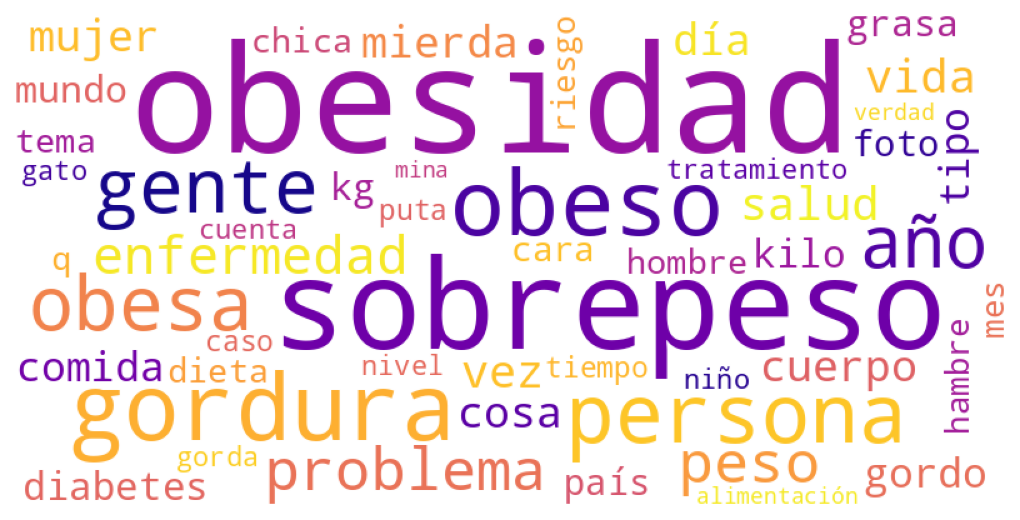

In [110]:
from collections import Counter
from wordcloud import WordCloud
import matplotlib.pyplot as plt
# Convierto la columna de listas en una sola lista grande de palabras
lista_completa = [palabra for sublista in df_clean['sustantivos_lematizados'] for palabra in sublista]

frecuencias = Counter(lista_completa)
top_sustantivos = dict(frecuencias.most_common(50))

ruta_fuente = None  # Fuente por defecto para evitar rutas absolutas de Colab.

# --- 2. Crear y Mostrar la Nube de Palabras ---

# Configuro la nube de palabras
wordcloud = WordCloud(width=800, height=400,
                      font_path=ruta_fuente,
                      background_color='white',
                      colormap='plasma',
                      margin=8,
                      max_font_size=120,
                      collocations=False,
                      min_font_size=10).generate_from_frequencies(top_sustantivos)

# Muestro la imagen generada
plt.figure(figsize=(10, 5), facecolor=None)
plt.imshow(wordcloud)
plt.axis("off")
plt.tight_layout(pad=0)

plt.show()

In [111]:
# Adjetivos sin lematizar:
adjetivos_sin_lematizar = sum(df_clean['adjetivos'], [])
cant_sin_lema = Counter(adjetivos_sin_lematizar)
print(f'Top 10 adjetivos sin lematizar:\n {cant_sin_lema.most_common(10)}')

# Adjetivos lematizados:
adjetivos_lematizados = sum(df_clean['adjetivos_lematizados'], [])
cant_con_lema = Counter(adjetivos_lematizados)
print(f'\nTop 10 adjetivos lematizados:\n {cant_con_lema.most_common(10)}')

Top 10 adjetivos sin lematizar:
 [('obeso', 1291), ('obesa', 868), ('gorda', 383), ('gordo', 352), ('obesos', 347), ('mórbida', 217), ('obesas', 158), ('mejor', 149), ('bueno', 121), ('solo', 103)]

Top 10 adjetivos lematizados:
 [('obeso', 2507), ('gordo', 781), ('mórbido', 289), ('mejor', 177), ('obesa', 158), ('bueno', 135), ('solo', 130), ('buen', 124), ('malo', 123), ('peor', 117)]


In [112]:
import plotly.express as px

# --- Gráfico 1: Adjetivos sin lematizar (Compacto) ---
adj_sin_lema = cant_sin_lema.most_common(10)
palabras_sin_lema = [x[0] for x in adj_sin_lema]
frecuencias_sin_lema = [x[1] for x in adj_sin_lema]

fig1 = px.bar(x=frecuencias_sin_lema, y=palabras_sin_lema,
              orientation='h',
              title='Top 10 adjetivos sin lematizar',
              color=frecuencias_sin_lema,
              color_continuous_scale='blugrn',
              height=300,
              width=300) # Ancho y alto acotados

fig1.update_layout(
    yaxis=dict(autorange="reversed"),
    coloraxis_showscale=False,
    margin=dict(l=10, r=10, t=50, b=10),
    xaxis_title=None,
    yaxis_title=None
)
fig1.show()


# --- Gráfico 2: Adjetivos lematizados (Compacto) ---
adj_con_lema = cant_con_lema.most_common(10)
palabras_con_lema = [x[0] for x in adj_con_lema]
frecuencias_con_lema = [x[1] for x in adj_con_lema]

fig2 = px.bar(x=frecuencias_con_lema, y=palabras_con_lema,
              orientation='h',
              title='Top 10 adjetivos lematizados', # Título corregido
              color=frecuencias_con_lema,
              color_continuous_scale='sunset',
              height=300,
              width=300)

fig2.update_layout(
    yaxis=dict(autorange="reversed"),
    coloraxis_showscale=False,
    margin=dict(l=10, r=10, t=50, b=10),
    xaxis_title=None,
    yaxis_title=None
)
fig2.show()

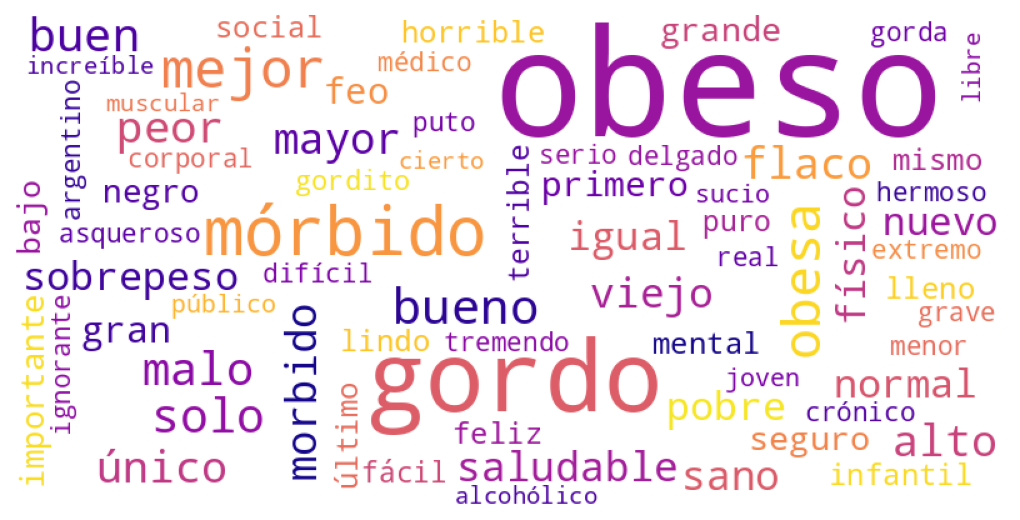

In [113]:
from collections import Counter
from wordcloud import WordCloud
import matplotlib.pyplot as plt
# Convierto la columna de listas en una sola lista grande de palabras
lista_completa = [palabra for sublista in df_clean['adjetivos_lematizados'] for palabra in sublista]

frecuencias = Counter(lista_completa)
top_sustantivos = dict(frecuencias.most_common(70))

ruta_fuente = None  # Fuente por defecto para evitar rutas absolutas de Colab.

# --- 2. Crear y Mostrar la Nube de Palabras ---

# Configuro la nube de palabras
wordcloud = WordCloud(width=800, height=400,
                      font_path=ruta_fuente,
                      background_color='white',
                      colormap='plasma',
                      margin=8,
                      max_font_size=120,
                      collocations=False,
                      min_font_size=10).generate_from_frequencies(top_sustantivos)

# Muestro la imagen generada
plt.figure(figsize=(10, 5), facecolor=None)
plt.imshow(wordcloud)
plt.axis("off")
plt.tight_layout(pad=0)

plt.show()

Comparando el top de sustantivos y adjetivos lematizados y sin lematizar concluimos que la mejor opción a la hora de utilizar estas variables en un modelo de regresión es utilizarlas lematizadas. Los números de los elementos en estas variables aumentan significativamente, unificando las pequeñas variaciones en una sola palabra. Por ejemplo, la palabra "obeso" aparece 1291 veces en la variable sin lematizar, mientras que aparece 1639 veces en la variable lematizada.

In [114]:
df_clean[['sustantivos', 'sustantivos_lematizados', 'sustantivos_robertuito']].head(40)

,sustantivos,sustantivos_lematizados,sustantivos_robertuito
0,"[kg, orto, sobrepeso, peso, altura, peso]","[kg, orto, sobrepeso, peso, altura, peso]","[kg, orto, sobrepeso, peso, altura, peso]"
1,"[años, tendencias, sobrepeso, tribunero, boca]","[año, tendencia, sobrepeso, tribunero, boca]","[años, tendencias, sobrepeso, boca]"
2,"[tabla, pediatra, años]","[tabla, pediatra, año]","[tabla, pediatra, años]"
3,"[huevo, pesar, kg, lista]","[huevo, pesar, kg, lista]","[huevo, kg, lista, hadid]"
4,"[curiosidad, gente, kilos, veces, placer, comida, tiempo, plato, dedos]","[curiosidad, gente, kilo, veces, placer, comida, tiempo, plato, dedo]","[curiosidad, gente, kilos, veces, placer, comida, tiempo, plato, dedos]"
5,"[lista, sobrepeso]","[lista, sobrepeso]","[lista, sobrepeso]"
6,[cuadro],[cuadro],[cuadro]
7,"[dios, azucar, fibra, minerales, MUERE, X]","[dios, azucar, fibra, mineral, muere, x]","[dioss,,,es, azucar, fibra, minerales, OBESIDAD, BANANA]"
8,"[razón, médico, kg]","[razón, médico, kg]","[razón, médico, kg]"
9,"[calificandola, obesidad, persona, deciciones, hora, capacitada, deciciones, resto, argentinos, bolsa, sueldo]","[calificandola, obesidad, persona, decición, hora, capacitada, decición, resto, argentino, bolsa, sueldo]","[obesidad, persona, deciciones, hora, deciciones, resto, argentinos, bolsa, trigliceridos, sueldo]"


- Aunque en la mayoría de los casos hay coincidencias entre los sustantivos detectados por spacy y por robertuito, hay algunos comentarios en donde un modelo identifica palabras que otro no, como "banana" en el ejemplo 10 o "obesa" en el ejemplo 15
- Habría que revisar un poco más el tratamiento de los emojis, dado que a veces aparecen con todos los guiones bajos, podrían reemplazarse por palabras o eliminarse. Lo mismo habría que quitar los hashtags para este análisis.
- Robertuito nos dio problemas con algunos textos pero no terminamos de identificar el porqué.

##### Uso posible de estas variables en tareas posteriores

Los sustantivos detectados en nuestro análisis aportan información semántica sobre el texto, dependiendo si la tarea lo requiere, utilizar las versiones lematizadas de estos sustantivos sería conveniente, esto nos permite considerar significados más generales, excluyendo algunas flexiones morfológicas dado que lematizar implica estandarizar, desambiguar, segmentar. Dado que el lema es la forma que por convenio se acepta como representante de todas las formas flexionadas de una misma palabra, permitirá que en el modelo desarrollado se capture el significado que aportan el grupo de palabras representados por el mismo lema. La utilidad o no de esto último dependerá del modelo que se esté utilizando, podemos encontrar casos en los cuáles convenga utilizar las palabras sin lematizar. Por ejemplo, si utilizamos un LLM para realizar tareas de análisis de sentimiento, sería mejor dejar las flexiones de estas palabras puesto que pueden llegar a contener información relevante para la clasificación que nuestro modelo es capaz de manejar. Por otro lado, si se trata de realizar un regresión para la predicción de engagement, utilizar la lematización permitiría reducir un poco el ruido que generan las distintas flexiones; la lematización reduce la dimensionalidad del espacio de características. En modelos clásicos (como regresiones, TF-IDF, Bag-of-Words), tener "casa" y "casas" como dos características distintas diluye el poder predictivo.

#### Transformación de variables para modelos de ML

##### Variables temporales y transformaciones cíclicas

Una de las variables a transformar para poder ser utilizada es la fecha, hay que tener en cuenta que la hora, el día de la semana o el mes del año son cíclicos (después de las 23 viene la 00, después de diciembre viene enero), y los modelos lineales no entienden esto. Una forma de manejar esta característica cíclica es usando las funciones seno y coseno. Es necesario utilizar ambas funciones, puesto que con una sola se pierde información, por ejemplo para las horas 0 y 12 tenemos que:
- $\sin(2\pi\cdot 0/24) = 0$
- $\sin(2\pi\cdot 12/24) = \sin(\pi) = 0$

Por lo tanto para poder distinguir estos momentos del día es necesario utilizar el coseno. Con el par (sin, cos) cada instante tiene una posición única en el círculo, y el modelo puede aprender relaciones continuas.

El objetivo de emplear las funciones seno y coseno es capturar la cercanía y sucesión de los valores (horas o días de la semana) al representarlos en un espacio circular, de modo que podamos modelar su naturaleza periódica. Por ello, proponemos tratar las variables hora y día de la semana de esta manera, y dejar la variable mes como categórica (dado que nuestros datos cubren un único año), aunque perdamos información de vecindad entre meses. En un escenario más amplio, convendría comparar estas opciones y evaluar empíricamente qué enfoque aporta más valor al modelo.


In [115]:
df_clean['date'] = pd.to_datetime(df_clean['date'])

# 1. Extraer componentes básicos
df_clean['hora']   = df_clean['date'].dt.hour
df_clean['minuto'] = df_clean['date'].dt.minute
df_clean['segundo']= df_clean['date'].dt.second
df_clean['dia_semana'] = df_clean['date'].dt.dayofweek

df_clean['hora_decimal'] = (
    df_clean['hora'] +
    df_clean['minuto'] / 60 +
    df_clean['segundo'] / 3600
)

# 2. Codificación Cíclica
df_clean['hora_sin'] = np.sin(2 * np.pi * df_clean['hora_decimal']/24)
df_clean['hora_cos'] = np.cos(2 * np.pi * df_clean['hora_decimal']/24)

df_clean['dia_sin'] = np.sin(2 * np.pi * df_clean['dia_semana'] / 7)
df_clean['dia_cos'] = np.cos(2 * np.pi * df_clean['dia_semana'] / 7)

df_clean[['date', 'hora', 'hora_decimal', 'hora_cos','hora_cos', 'dia_semana', 'dia_sin', 'dia_cos']].head()

,date,hora,hora_decimal,hora_cos,hora_cos,dia_semana,dia_sin,dia_cos
0,2024-01-16 16:52:17,16,16.87,-0.29,-0.29,1,0.78,0.62
1,2024-01-16 16:40:29,16,16.67,-0.34,-0.34,1,0.78,0.62
2,2024-01-16 16:20:10,16,16.34,-0.42,-0.42,1,0.78,0.62
3,2024-01-16 00:01:36,0,0.03,1.00,1.00,1,0.78,0.62
4,2024-01-16 16:14:20,16,16.24,-0.44,-0.44,1,0.78,0.62


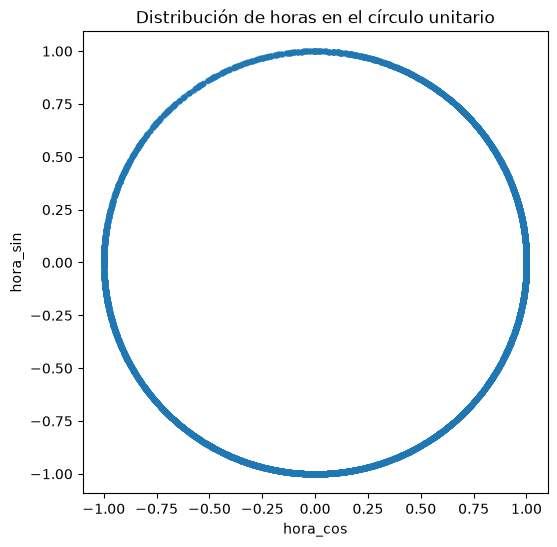

In [116]:
plt.figure(figsize=(6,6))
# Dibujo del círculo unitario
theta = np.linspace(0, 2*np.pi, 200)
plt.plot(np.cos(theta), np.sin(theta), lw=1, alpha=0.5)

# Puntos de tus datos
plt.scatter(df_clean['hora_cos'], df_clean['hora_sin'],
            s=10, alpha=0.7)

plt.axis('equal')
plt.xlabel('hora_cos')
plt.ylabel('hora_sin')
plt.title('Distribución de horas en el círculo unitario')
plt.show()

Como hemos visto, las variables replyCount, retweetCount, likeCount, viewCount tienen una distribución fuertemente asimétrica, una manera común de trabajar con ellas es aplicar una transformación logarítmica, log(x + 1) (el "+ 1" es para evitar el logaritmo de cero) comprime el rango de la variable, la hace más simétrica (parecida a una distribución normal) y reduce el impacto de los valores extremos.

Además podemos crear una nueva variable que represente la cantidad de likes por views (podríamos hacer lo mismo con retweets y replies).

In [117]:
# Lista de columnas a transformar
transform_cols = ['replyCount', 'retweetCount', 'likeCount', 'viewCount']

# Aplicar transformación logarítmica
for col in transform_cols:
    df_clean[f'{col}_log'] = np.log1p(df_clean[col])

# Crear tasa de likes (manejando divisiones por cero)
df_clean['tasa_like'] = df_clean['likeCount'] / (df_clean['viewCount'] + 1)

In [118]:
df_clean[['replyCount_log','retweetCount_log', 'likeCount_log', 'viewCount_log','tasa_like']]

,replyCount_log,retweetCount_log,likeCount_log,viewCount_log,tasa_like
0,0.69,0.00,0.69,2.94,0.05
1,0.00,0.00,0.69,3.09,0.05
2,0.00,0.00,0.00,4.60,0.00
3,5.82,7.50,10.40,13.50,0.05
4,0.00,0.00,0.00,2.94,0.00
...,...,...,...,...,...
8877,0.00,0.00,0.00,3.69,0.00
8878,0.00,0.00,0.69,4.39,0.01
8879,0.00,0.00,2.71,7.70,0.01
8880,0.00,0.00,0.69,2.40,0.09


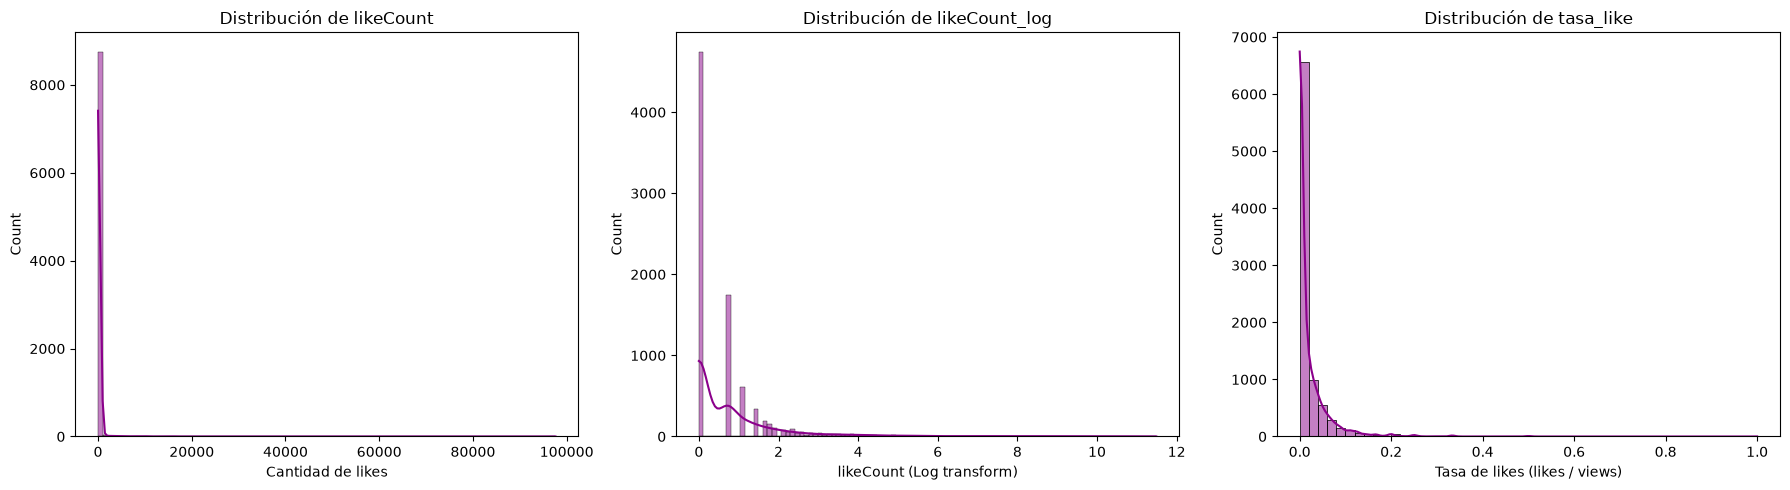

In [119]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(df_clean['likeCount'], ax=axes[0], color='darkmagenta', kde=True, bins=100)
axes[0].set_xlabel('Cantidad de likes')
axes[0].set_title('Distribución de likeCount')

sns.histplot(df_clean['likeCount_log'], ax=axes[1], color='darkmagenta', kde=True, bins=100)
axes[1].set_xlabel('likeCount (Log transform)')
axes[1].set_title('Distribución de likeCount_log')

sns.histplot(df_clean['tasa_like'], ax=axes[2], color='darkmagenta', kde=True, bins=50)
axes[2].set_xlabel('Tasa de likes (likes / views)')
axes[2].set_title('Distribución de tasa_like')

plt.tight_layout()
plt.show()

##### Sentimiento y lenguaje hostil

En el práctico 1 realizamos un análisis de sentimiento utilizando dos modelos, RoBERTuito (incluido en la herramienta pysentimiento) y una clasificación por medio de una prompt utilizando el LLM llama3.2 8B Instruct.

A continuación mostramos los resultados de ambas clasificaciones y los agregamos a nuestro dataset.

In [120]:
# from pysentimiento import create_analyzer
if False:
  analyzer = create_analyzer(task='sentiment', lang='es')
  def sentimiento_tweet(tweet):
      resultado = analyzer.predict(tweet)
      sentimiento = resultado.output
      return sentimiento
  df_clean['pysentimiento'] = df_clean['rawContent_clean'].apply(sentimiento_tweet)
  df_clean[['id_str', 'pysentimiento']].to_csv(PROCESSED_DIR / 'pysentimiento.csv', index=False)
else:
  pysentimiento_df = pd.read_csv(PROCESSED_DIR / 'pysentimiento.csv')
  df_clean = pd.merge(df_clean, pysentimiento_df, on='id_str')

In [121]:
df_clean.pysentimiento.value_counts()

pysentimiento
NEG    7187
NEU    1379
POS     316
Name: count, dtype: int64

In [122]:
import plotly.graph_objects as go

df_sentimiento = df_clean['pysentimiento'].value_counts().reset_index()
df_sentimiento.columns = ['sentimiento', 'cantidad']
labels = df_sentimiento['sentimiento']
values = df_sentimiento['cantidad']
colors= px.colors.qualitative.Set3
fig = go.Figure(data=[go.Pie(labels=labels, values=values, hole=.3, marker=dict(colors=colors))])
fig.update_layout(
      title='Distribución de sentimientos usando PySentimiento',
      title_font_size=22,
      width=700,
      height=500
)
fig.show()

In [123]:
colores_sentimientos = {
    'NEU': '#75A7D1',  # Un tono de azul suave
    'NEG': '#e0748c',  # Un tono de rojo/magenta de 'sunset'
    'POS': '#8DD3C7'   # Un tono de verde suave
}


colors = [colores_sentimientos.get(label, 'gray') for label in labels]


fig = go.Figure(data=[go.Pie(labels=labels, values=values, hole=.3,
                            marker=dict(colors=colors))])


fig.update_layout(
    title='Distribución de sentimientos<br>usando PySentimiento',
    title_x=0.5,
    title_font_size=22,
    width=500,
    height=500,
    legend=dict(
        orientation="h",
        yanchor="bottom",
        y=-0.2,
        xanchor="center",
        x=0.5
    )
)


fig.show()

In [124]:
df_llama = pd.read_csv(PROCESSED_DIR / 'base_obesidad_sentiment_llama.csv')

In [125]:
df_sentimiento_llama = df_llama['sentiment'].value_counts().reset_index()
df_sentimiento_llama.columns = ['sentimiento', 'cantidad']
labels_llama = df_sentimiento_llama['sentimiento']
values_llama = df_sentimiento_llama['cantidad']

colors= px.colors.qualitative.Set3
fig = go.Figure(data=[go.Pie(labels=labels_llama, values=values_llama, hole=.3, marker=dict(colors=colors))])
fig.update_layout(
      title='Distribución de sentimientos usando Llama',
      title_font_size=22,
      width=700,
      height=500
)
fig.show()

In [126]:
colores_sentimientos = {
    'NEUTRO': '#75A7D1',  # Un tono de azul suave
    'NEGATIVO': '#e0748c',  # Un tono de rojo/magenta de 'sunset'
    'POSITIVO': '#8DD3C7'   # Un tono de verde suave
}


colors = [colores_sentimientos.get(label, 'gray') for label in labels_llama]


fig = go.Figure(data=[go.Pie(labels=labels_llama, values=values_llama, hole=.3,
                            marker=dict(colors=colors))])


fig.update_layout(
    title='Distribución de sentimientos<br>usando Llama',
    title_x=0.5,
    title_font_size=22,
    width=500,
    height=500,
    legend=dict(
        orientation="h",
        yanchor="bottom",
        y=-0.2,
        xanchor="center",
        x=0.5
    )
)


fig.show()

Realizaremos también un análisis de hate speech con el objetivo de comparar en un trabajo posterior con el resultado de un análisis de tópicos. Para el reconocimiento de discurso de odio existen diversas herramientas, algunas de uso libre y otras comerciales, algunas con distintos tipo de licencias que permiten su uso académico y comercial. Encontramos herramientas basadas en diccionarios léxicos así como modelos transformers entrenados para el reconocimiento de diversas categorías. Aquí probaremos las siguientes herramientas:

- [spanlp](https://github.com/jfreddypuentes/spanlp): tiene un enfoque basado en léxicos (diccionarios). Su función principal es detectar y censurar blasfemias, vulgaridades y otro lenguaje ofensivo. Comprueba la presencia de palabras en listas exhaustivas y específicas por país. Su sofisticación radica en el uso de métricas de similitud de cadenas como el Índice de Jaccard y la distancia de Levenshtein para detectar errores ortográficos o variaciones de palabras ofensivas. Su principal fortaleza es el soporte explícito para más de 20 países de habla hispana, desde Argentina hasta España.
  - Fue actualizada por útima vez hace 4 años.
  - Tiene distintas funciones para preprocesar el texto que es interesante revisar.
- [spanish_nlp](https://github.com/jorgeortizfuentes/spanish_nlp): es una biblioteca diseñada para facilitar tareas de PLN en español con un enfoque de bajo código. Proporciona un conjunto de herramientas que incluye clasificadores preconstruidos para hate_speech, toxic_speech, racism_analysis, sentiment_analysis y más.
  - Fue actualizada por última vez hace 3 meses.
  - No explicita qué modelos utiliza para realizar las clasificaciones.
- [delarosajav95/HateSpeech-BETO-cased-v2](https://huggingface.co/delarosajav95/HateSpeech-BETO-cased-v2): Utiliza BETO como base y realiza una clasificación binaria (Non-Hateful-LABEL_0/Hateful-LABEL_1). Está entrenado con el manueltonneau/spanish-hate-speech-superset, un meta-dataset que agrega varias fuentes, y está enriquecido con muestras de Paul/hatecheck-spanish para mejorar el rendimiento en categorías específicas como la transfobia.
  - El modelo reporta una precisión (accuracy) de evaluación del 84.6% y un F1-score ponderado de 0.843.
  - Todos los textos fueron convertidos a minúscula en su entrenamiento.
  - Es un modelo del año 2024.

Otras herramientas interesantes que no probaremos son:
- [piuba-bigdata/beto-contextualized-hate-speech](https://huggingface.co/piuba-bigdata/beto-contextualized-hate-speech): Este modelo está diseñado para procesar tanto un comentario como su contexto (por ejemplo, el titular de la noticia al que responde). Es del 2023.
- [Perspective API](https://www.perspectiveapi.com/): Creada por Jigsaw y Google, está diseñada para puntuar el "impacto percibido que un comentario podría tener en una conversación". Se centra en atributos como TOXICITY, SEVERE_TOXICITY, INSULT, etc. Es gratuita por defecto, con una cuota de 1 consulta por segundo.

In [127]:
from spanlp.palabrota import Palabrota

palabrota = Palabrota()

if False:
  def hs_spanlp(text):
      return palabrota.contains_palabrota(text)
  df_clean['hs_spanlp'] = df_clean.rawContent_clean.apply(hs_spanlp)
else:
  temp_df = pd.read_csv(PROCESSED_DIR / 'hs_spanlp.csv')
  df_clean = pd.merge(df_clean, temp_df, on='id_str')

In [128]:
df_clean['hs_spanlp'].value_counts()

hs_spanlp
False    5369
True     3513
Name: count, dtype: int64

In [129]:
df_clean[df_clean['hs_spanlp']].sample(10).rawContent

1418                                                                                                                                                                                      no ese no es, fijate q hay otro tema bueno q se llama puputona trola gorda obesa fracasada 0800 es de  ysy a
2337                                                                                                                                                              Deja de hablar pavada y cosete la boca boba,cuando lo sacaron a lisandro le hicieron caso y ahora que pidio x paloma no?jajaja obesa
7249                                                                                                                                             Porque se romantiza tanto la obesidad infantil? Un nene de 10 años que pesa casi 100kg no es una ternura por sus cachetes, necesita un tratamiento...
7631         tu hermano flaquito\nCuando te agarré me volvió una parte del alma al cuerpo\nDesde entonces prometí q

In [130]:
# DA PROBLEMAS CON LAS VERSIONES DE DISTINTAS LIBRERÍAS
#from spanish_nlp import classifiers

#sc = classifiers.SpanishClassifier(model_name="hate_speech", device='cuda')

if False:
  def hs_spanish_nlp(text):
    return sc.predict(text)
  df_clean['hs_spanish_nlp'] = df_clean.rawContent_clean.apply(hs_spanish_nlp)
  df_clean[['id_str', 'hs_spanish_nlp']].to_csv("hs_spanish_nlp.csv", index=False)
#else:
  #temp_df = pd.read_csv('hs_spanish_nlp.csv')
  #df_clean = pd.merge(df_clean, temp_df, on='id_str')

In [131]:
#df_clean[['rawContent', 'hs_spanish_nlp']].head(10)

In [132]:
from transformers import pipeline

if False:
  classifier = pipeline('text-classification', model='delarosajav95/HateSpeech-BETO-cased-v2')
  def hs_beto(text):
    return classifier(text)
  df_clean['hs_beto'] = df_clean.rawContent_clean.apply(hs_beto)
  df_clean[['id_str', 'hs_beto']].to_csv(PROCESSED_DIR / 'hs_beto.csv', index=False)
else:
  temp_df = pd.read_csv(PROCESSED_DIR / 'hs_beto.csv')
  df_clean = pd.merge(df_clean, temp_df, on='id_str')

In [133]:
df_clean[['rawContent', 'hs_beto']].head(10)

,rawContent,hs_beto
0,"Boluda ahí dice que yo debería pesar 43kg eso está para el orto. Yo sé que tengo sobrepeso y por eso estoy empezando a cuidarme más para bajar de peso, por mi altura mi peso ideal sería 64","[{'label': 'LABEL_0', 'score': 0.9999117851257324}]"
1,"Jugador de +30 años, vendehumo, con tendencias a lesionarse, con sobrepeso, tribunero y cabaretero. Nació para jugar en boca","[{'label': 'LABEL_0', 'score': 0.9988625049591064}]"
2,La tabla de mi pediatra cuando tenia 6 años y me decía obesa jsjs,"[{'label': 'LABEL_0', 'score': 0.9998273849487305}]"
3,chupame un huevo como voy a pesar 48 kg midiendo casi 1.70 quién hizo esta lista yolanda hadid,"[{'label': 'LABEL_0', 'score': 0.9999501705169678}]"
4,"Eso me da curiosidad en la gente obesa. Miro kilos mortales a veces y veo con q placer tocan la comida todo el tiempo. La acomodan en el plato, la mueven, etc todo con los dedos.","[{'label': 'LABEL_1', 'score': 0.8396030068397522}]"
5,"Segun esta lista de yolanda hadid, tengo sobrepeso 😔","[{'label': 'LABEL_0', 'score': 0.9997922778129578}]"
6,No bueno lo OBESA que me dijo que estoy este cuadro.,"[{'label': 'LABEL_0', 'score': 0.9997888207435608}]"
7,"ayy dioss,,,es azucar buena, es necesaria, es sana, tiene fibra, minerales...NADIE MUERE DE OBESIDAD X COMER BANANA!! tome, instrúyase: link_url","[{'label': 'LABEL_0', 'score': 0.9999040365219116}]"
8,y claro con razón el médico me dice obeso alsbskbdksjdid como q tengo q pesar 52 kg ajdhksbdksjs hdps,"[{'label': 'LABEL_0', 'score': 0.9998121857643127}]"
9,"estamos calificandola por su obesidad, una persona que toma tan malas deciciones a la hora de alimentarse claramente no esta capacitada para tomar buenas deciciones sobre el resto de los argentinos. a esta bolsa de trigliceridos le pagamos el sueldo.","[{'label': 'LABEL_0', 'score': 0.9994692206382751}]"


##### Codificación de variables categóricas y conteos

Podemos codificar la variable pcia con one-hot encoding dado que no tiene muchas categorías, el objetivo es convertir las categorías en números que un modelo de regresión pueda procesar. Creamos una nueva columna binaria (0 o 1) por cada categoría.

In [134]:
import ast

# codificar correctamente pcia como una lista
if type(df_clean['pcia'].iloc[0]) == str:
    df_clean['pcia'] = df_clean['pcia'].apply(ast.literal_eval)
df_clean['pcia'].explode().value_counts().head(20)

pcia
buenos aires        7051
caba                 417
argentina            217
chubut               187
santa fe             112
rio negro             82
tierra del fuego      74
tucuman               54
santa cruz            45
entre rios            45
la pampa              24
antartida             16
catamarca             15
cordoba                6
mendoza                3
corrientes             1
neuquen                1
misiones               1
salta                  1
san juan               1
Name: count, dtype: int64

In [135]:
borrar = {'argentina', 'antartida'}

def limpiar_pcia(lista):
    # Filtramos borrando los no deseados
    filtrada = [p for p in lista if p.lower() not in borrar]
    nombres = [p.lower() for p in filtrada]
    if 'buenos aires' in nombres and 'tucuman' in nombres:
        filtrada = [p for p in filtrada if p.lower() != 'tucuman']
    return filtrada
df_clean['pcia'] = df_clean['pcia'].apply(limpiar_pcia)

In [136]:
df_clean['pcia_unica'] = df_clean['pcia'].apply(lambda L: L[0] if len(L)==1 else np.nan)

In [137]:
df_clean[['pcia', 'pcia_unica']]

,pcia,pcia_unica
0,[],NaN
1,[buenos aires],buenos aires
2,[buenos aires],buenos aires
3,[buenos aires],buenos aires
4,[buenos aires],buenos aires
...,...,...
8877,[buenos aires],buenos aires
8878,[buenos aires],buenos aires
8879,[buenos aires],buenos aires
8880,[buenos aires],buenos aires


In [138]:
from sklearn.preprocessing import OneHotEncoder
# Preparamos el encoder
ohe = OneHotEncoder(
    sparse_output=False,             # para devolver un array denso
    handle_unknown='ignore'   # ignora provincias nuevas en predict()
)

# Ajustamos solo sobre las no-nulas
mask = df_clean['pcia_unica'].notna()
vals = df_clean.loc[mask, ['pcia_unica']]

In [139]:
# Fit‑transform y construimos DataFrame de dummies
ohe_arr = ohe.fit_transform(vals)
cols   = ohe.get_feature_names_out(['pcia_unica'])
df_ohe = pd.DataFrame(ohe_arr, columns=cols, index=vals.index)

In [140]:
df_ohe

,pcia_unica_buenos aires,pcia_unica_caba,pcia_unica_catamarca,pcia_unica_chubut,pcia_unica_cordoba,pcia_unica_corrientes,pcia_unica_entre rios,pcia_unica_la pampa,pcia_unica_mendoza,pcia_unica_misiones,pcia_unica_neuquen,pcia_unica_rio negro,pcia_unica_salta,pcia_unica_san juan,pcia_unica_santa cruz,pcia_unica_santa fe,pcia_unica_tierra del fuego,pcia_unica_tucuman
1,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
2,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
3,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
4,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
5,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8877,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
8878,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
8879,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
8880,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00


In [141]:
df_clean = pd.concat([df_clean, df_ohe], axis=1)

In [142]:
df_clean.columns

Index(['id_str', 'date', 'rawContent', 'replyCount', 'retweetCount',
       'likeCount', 'quoteCount', 'conversationId', 'hashtags', 'viewCount',
       'pcia', 'mes', 'user_id', 'pcia1', 'hashtags1', 'containKeyword',
       'idioma_lingua', 'rawContent_sin_link', 'semana', 'nombre_mes', 'hora',
       'rawContent_clean', 'tokens', 'sentences', 'entidades', 'sustantivos',
       'sustantivos_lematizados', 'verbos', 'adjetivos',
       'adjetivos_lematizados', 'adverbios', 'sustantivos_robertuito',
       'minuto', 'segundo', 'dia_semana', 'hora_decimal', 'hora_sin',
       'hora_cos', 'dia_sin', 'dia_cos', 'replyCount_log', 'retweetCount_log',
       'likeCount_log', 'viewCount_log', 'tasa_like', 'pysentimiento',
       'Unnamed: 0', 'hs_spanlp', 'hs_beto', 'pcia_unica',
       'pcia_unica_buenos aires', 'pcia_unica_caba', 'pcia_unica_catamarca',
       'pcia_unica_chubut', 'pcia_unica_cordoba', 'pcia_unica_corrientes',
       'pcia_unica_entre rios', 'pcia_unica_la pampa', 'pcia_unic

Para trabajar con el conversationId podemos utilizar frequency encoding. Realizar un target encoding nos parece que no es posible puesto que hay demasiadas categorías con 1 elemento, y sería difícil llenar con la media de la variable objetivo en esos casos.

In [143]:
freq = df_clean['conversationId'].value_counts()

df_clean['conversation_freq'] = df_clean['conversationId'].map(freq)

df_clean['conversation_freq_norm'] = (
    df_clean['conversation_freq'] / df_clean['conversation_freq'].max()
)

In [144]:
df_clean[['conversationId', 'conversation_freq', 'conversation_freq_norm']]

,conversationId,conversation_freq,conversation_freq_norm
0,1747290800474476846,1,0.04
1,1747268216882102581,1,0.04
2,1747292672232931781,1,0.04
3,1747046404873175457,1,0.04
4,1746941101645132124,3,0.12
...,...,...,...
8877,1868708807502970986,6,0.24
8878,1868688519184699813,1,0.04
8879,1868708807502970986,6,0.24
8880,1868747084482200016,1,0.04


Para utilizar los hashtags y los tipos de palabras que analizamos podríamos realizar un conteo con el número de cada uno. Para el caso de los hashtags también podríamos crear una variable binaria (contiene hashtags o no), o seleccionar los más frecuentes y realizar un one hot encoding.

Además podemos calcular:
- Densidad léxica: Una métrica que distingue entre palabras con contenido léxico de las palabras funcionales, en nuestro caso utilizaremos una versión simplificada que no incluye los adverbios puesto que no los hemos detectado:
$$\text{Densidad léxica} = \frac{\text{nro. de palabras de contenido}}{\text{nro. total de palabras}}$$

- Riqueza léxica: Mide la diversidad del vocabulario, por ejemplo el Type-Token Ratio (TTR) es la métrica más común para la riqueza léxica. Mide la proporción de palabras únicas (types) respecto al total de palabras (tokens). Un TTR alto sugiere un vocabulario más variado.

- Conteo de signos de puntuación: La frecuencia de ciertos signos puede ser un indicador de la tonalidad del texto.

- Conteo de mayúsculas: Un alto número de palabras en mayúsculas puede ser señal de énfasis.

- Conteo de caracteres, palabras y oraciones

- Longitud promedio de palabra y oración

- Ratio sustantivos-verbos.

In [145]:
import ast
df_clean['hashtags'] = df_clean['hashtags'].apply(ast.literal_eval)

In [146]:
df_clean['n_nouns'] = df_clean['sustantivos'].apply(len)
df_clean['n_verbs'] = df_clean['verbos'].apply(len)
df_clean['n_adj'] = df_clean['adjetivos'].apply(len)
df_clean['n_hashtags'] = df_clean['hashtags'].apply(len)

df_clean[['n_nouns', 'n_verbs', 'n_adj', 'n_hashtags']]

,n_nouns,n_verbs,n_adj,n_hashtags
0,6,8,1,0
1,5,3,1,0
2,3,2,1,0
3,4,3,0,0
4,9,6,2,0
...,...,...,...,...
8877,1,3,2,0
8878,6,0,2,0
8879,0,0,2,0
8880,4,2,1,0


In [147]:
df_clean['ttr'] = df_clean['tokens'].apply(lambda x: len(set(x)) / (len(x) + 1e-6))

n_content_words = df_clean['n_nouns'] + df_clean['n_verbs'] + df_clean['n_adj']
n_total_words = df_clean['tokens'].apply(len)
df_clean['lexical_density'] = (n_content_words / (n_total_words + 1e-6))

df_clean[['ttr', 'lexical_density']]

,ttr,lexical_density
0,0.85,0.37
1,0.83,0.37
2,1.00,0.43
3,1.00,0.39
4,0.78,0.41
...,...,...
8877,0.95,0.27
8878,0.89,0.44
8879,0.89,0.22
8880,1.00,0.44


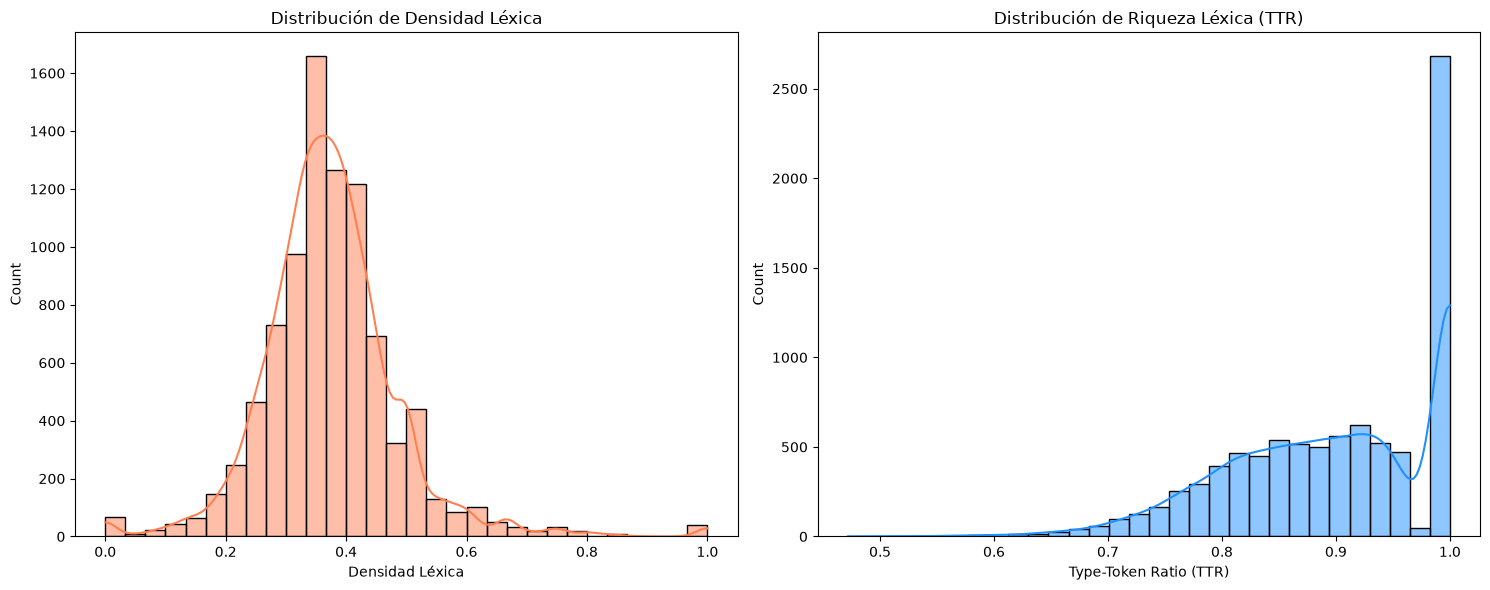

In [148]:
# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Plotting lexical_density on the left subplot
sns.histplot(df_clean['lexical_density'], ax=axes[0], color='coral', kde=True, bins=30)
axes[0].set_xlabel('Densidad Léxica')
axes[0].set_title('Distribución de Densidad Léxica')

# Plotting ttr on the right subplot
sns.histplot(df_clean['ttr'], ax=axes[1], color='dodgerblue', kde=True, bins=30)
axes[1].set_xlabel('Type-Token Ratio (TTR)')
axes[1].set_title('Distribución de Riqueza Léxica (TTR)')

plt.tight_layout()
plt.show()


In [149]:
df_clean[df_clean['ttr'] > 0.99][['rawContent', 'ttr', 'tokens']].head()

,rawContent,ttr,tokens
2,La tabla de mi pediatra cuando tenia 6 años y me decía obesa jsjs,1.00,"[La, tabla, de, mi, pediatra, cuando, tenia, 6, años, y, me, decía, obesa, jaja]"
3,chupame un huevo como voy a pesar 48 kg midiendo casi 1.70 quién hizo esta lista yolanda hadid,1.00,"[chupame, un, huevo, como, voy, a, pesar, 48, kg, midiendo, casi, 1.70, quién, hizo, esta, lista, yolanda, hadid]"
5,"Segun esta lista de yolanda hadid, tengo sobrepeso 😔",1.00,"[Segun, esta, lista, de, yolanda, hadid, ,, tengo, sobrepeso]"
13,"Claro que sí, por la gordura pete!",1.00,"[Claro, que, sí, ,, por, la, gordura, pete, !]"
19,"lit, ojala se vuelvan obesas en serio ya q tanto lo quieren",1.00,"[lit, ,, ojala, se, vuelvan, obesas, en, serio, ya, q, tanto, lo, quieren]"


In [150]:
df_clean['n_sentences'] = df_clean['sentences'].apply(len)
df_clean['n_tokens'] = df_clean['tokens'].apply(len)

df_clean[['rawContent_clean', 'n_sentences', 'n_tokens']].head()

,rawContent_clean,n_sentences,n_tokens
0,"Boluda ahí dice que yo debería pesar 43kg eso está para el orto. Yo sé que tengo sobrepeso y por eso estoy empezando a cuidarme más para bajar de peso, por mi altura mi peso ideal sería 64",3,41
1,"Jugador de +30 años, vendehumo, con tendencias a lesionarse, con sobrepeso, tribunero y cabaretero. Nació para jugar en boca",2,24
2,La tabla de mi pediatra cuando tenia 6 años y me decía obesa jaja,1,14
3,chupame un huevo como voy a pesar 48 kg midiendo casi 1.70 quién hizo esta lista yolanda hadid,1,18
4,"Eso me da curiosidad en la gente obesa. Miro kilos mortales a veces y veo con q placer tocan la comida todo el tiempo. La acomodan en el plato, la mueven, etc todo con los dedos.",3,41


In [151]:
df_clean.to_csv(PROCESSED_DIR / 'df_final.csv', index=False)

### Selección de variables relevantes

Cuando aplicamos técnicas de ML precisamos reconocer qué variables serán incluídas en nuestro modelo, cómo es la influencia que las mismas tienen sobre nuestra variable respuesta, y si deberíamos incluirlas o no, y cómo. En este caso, la problemática que se presenta es poder identificar qué variables influyen en los patrones de interacción de las publicaciones, específicamente en la cantidad de likes que puede tener un posteo. Para ello se solicitan las siguientes tareas.

#### Ejercicio 5

- a. Identificar qué variables creen que podrían ser relevantes para el problema que abordarán con ML. Mencionar qué otras variables sería interesantes incorporar y que no están disponibles en el dataset proporcionado o que estén disponibles en fuentes externas.
- b. Aplicar distintar pruebas estadísticas para conocer la influencia/relación que presentan con la variable respuesta mencionada (likes). Interpretar los resultados y mencionar qué variables se pueden incluir y cuáles eliminar.
- c. (**Opcional**) Aplicar técnicas automáticas de selección de características (por ejemplo, usando feature importance, chi2, mutual info, etc.).

In [152]:
df_final = pd.read_csv(PROCESSED_DIR / 'df_final.csv')

In [153]:
df_final.info()

<class 'pandas.DataFrame'>
RangeIndex: 8882 entries, 0 to 8881
Data columns (total 78 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   id_str                       8882 non-null   int64  
 1   date                         8882 non-null   str    
 2   rawContent                   8882 non-null   str    
 3   replyCount                   8882 non-null   int64  
 4   retweetCount                 8882 non-null   int64  
 5   likeCount                    8882 non-null   float64
 6   quoteCount                   8882 non-null   int64  
 7   conversationId               8882 non-null   int64  
 8   hashtags                     8882 non-null   str    
 9   viewCount                    8882 non-null   float64
 10  pcia                         8882 non-null   str    
 11  mes                          8882 non-null   int64  
 12  user_id                      8882 non-null   int64  
 13  pcia1                        

Es necesario categorizar la variable `likeCount` dado que el test chi-cuadrado de independencia está diseñado específicamente para analizar la relación entre dos variables categóricas. Requiere:
- Tabla de contingencia: Una matriz que muestra las frecuencias de combinaciones entre categorías
- Variables discretas: Ambas variables deben tener un número finito de categorías

In [154]:
from scipy.stats import chi2_contingency, f_oneway
# https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.f_oneway.html
from scipy.stats import pearsonr, spearmanr

In [155]:
print("=== ANÁLISIS DE VARIABLES PARA LIKES ===\n")

# 1. PRUEBAS CHI-CUADRADO PARA VARIABLES CATEGÓRICAS
print("1. PRUEBAS CHI-CUADRADO (Variables categóricas vs likes)")
print("-" * 60)

def categorizar_likes(df, columna_likes='likeCount'):
    """Convierte likes en categorías para prueba chi-cuadrado"""
    q33 = df[columna_likes].quantile(0.33)
    q66 = df[columna_likes].quantile(0.66)

    def categorizar(x):
        if x <= q33:
            return 'Bajo'
        elif x <= q66:
            return 'Medio'
        else:
            return 'Alto'

    return df[columna_likes].apply(categorizar)

# Crear variable likes categorizada
df_final['likes_categoria'] = categorizar_likes(df_final, 'likeCount')

# Variables categóricas a testear
variables_categoricas = [
    'pcia1', 'nombre_mes', 'dia_semana', 'pysentimiento', 'hs_spanlp'
]

resultados_chi2 = []

for var in variables_categoricas:
    if var in df_final.columns:
        try:
            # Crear tabla de contingencia
            tabla_contingencia = pd.crosstab(df_final[var], df_final['likes_categoria'])

            # Realizar prueba chi-cuadrado
            chi2, p_valor, dof, expected = chi2_contingency(tabla_contingencia)

            # Guardar resultados
            resultado = {
                'variable': var,
                'chi2_stat': chi2,
                'p_valor': p_valor,
                'grados_libertad': dof,
                'significativo': p_valor < 0.05
            }
            resultados_chi2.append(resultado)

            print(f"Variable: {var}")
            print(f"  Chi-cuadrado: {chi2:.4f}")
            print(f"  P-valor: {p_valor:.6f}")
            print(f"  Significativo (α=0.05): {'Sí' if p_valor < 0.05 else 'No'}")
            print()

        except Exception as e:
            print(f"Error con variable {var}: {str(e)}")
            print()

=== ANÁLISIS DE VARIABLES PARA LIKES ===

1. PRUEBAS CHI-CUADRADO (Variables categóricas vs likes)
------------------------------------------------------------
Variable: pcia1
  Chi-cuadrado: 120.3433
  P-valor: 0.000000
  Significativo (α=0.05): Sí

Variable: nombre_mes
  Chi-cuadrado: 46.8843
  P-valor: 0.001519
  Significativo (α=0.05): Sí

Variable: dia_semana
  Chi-cuadrado: 13.0297
  P-valor: 0.366888
  Significativo (α=0.05): No

Variable: pysentimiento
  Chi-cuadrado: 17.9223
  P-valor: 0.001278
  Significativo (α=0.05): Sí

Variable: hs_spanlp
  Chi-cuadrado: 34.9642
  P-valor: 0.000000
  Significativo (α=0.05): Sí



Los resultados muestran que 4 de las 5 variables categóricas analizadas tienen una relación significativa con los patrones de likes. Provincia (pcia1) presenta la asociación más fuerte ($χ²=120.34, p<0.001$), aunque este resultado debe interpretarse con cautela debido al fuerte desbalance en los datos. El mes de publicación también muestra una relación significativa ($χ²=46.88, p=0.002$), sugiriendo variaciones estacionales la cantidad de likes. Las variables de sentimiento ($χ²=17.92, p=0.001$) y detección de hate speech ($χ²=34.96, p<0.001$) también resultan relevantes para predecir likes. Solo el día de la semana no muestra asociación significativa ($p=0.37$), indicando que el momento semanal de publicación no influye en el engagement.

In [156]:
# 2. PRUEBAS ANOVA PARA VARIABLES CATEGÓRICAS VS LIKES (CONTINUA)
print("\n2. PRUEBAS ANOVA (Variables categóricas vs likes continua)")
print("-" * 60)

resultados_anova = []

for var in variables_categoricas:
    if var in df_final.columns:
        try:
            # Obtener grupos únicos
            grupos = df_final[var].unique()

            # Si hay más de 1 grupo y menos de 20 (para evitar muchos grupos)
            if len(grupos) > 1 and len(grupos) < 20:
                # Crear listas de likes por grupo
                grupos_likes = [df_final[df_final[var] == grupo]['likeCount'].dropna() for grupo in grupos]

                # Filtrar grupos vacíos
                grupos_likes = [grupo for grupo in grupos_likes if len(grupo) > 0]

                if len(grupos_likes) > 1:
                    # Realizar ANOVA
                    f_stat, p_valor = f_oneway(*grupos_likes)

                    # Guardar resultados
                    resultado = {
                        'variable': var,
                        'f_statistic': f_stat,
                        'p_valor': p_valor,
                        'num_grupos': len(grupos_likes),
                        'significativo': p_valor < 0.05
                    }
                    resultados_anova.append(resultado)

                    print(f"Variable: {var}")
                    print(f"  F-statistic: {f_stat:.4f}")
                    print(f"  P-valor: {p_valor:.6f}")
                    print(f"  Número de grupos: {len(grupos_likes)}")
                    print(f"  Significativo (α=0.05): {'Sí' if p_valor < 0.05 else 'No'}")
                    print()

        except Exception as e:
            print(f"Error con variable {var}: {str(e)}")
            print()


2. PRUEBAS ANOVA (Variables categóricas vs likes continua)
------------------------------------------------------------
Variable: nombre_mes
  F-statistic: 18.9143
  P-valor: 0.000000
  Número de grupos: 12
  Significativo (α=0.05): Sí

Variable: dia_semana
  F-statistic: 0.5350
  P-valor: 0.782050
  Número de grupos: 7
  Significativo (α=0.05): No

Variable: pysentimiento
  F-statistic: 0.4874
  P-valor: 0.614266
  Número de grupos: 3
  Significativo (α=0.05): No

Variable: hs_spanlp
  F-statistic: 1.4540
  P-valor: 0.227916
  Número de grupos: 2
  Significativo (α=0.05): No



Los resultados de ANOVA muestran un contraste notable con las pruebas chi-cuadrado: solo el mes de publicación mantiene significancia estadística ($F=18.91, p<0.001$), lo que probablemente se deba a que el mes de octubre no tiene datos. Sin embargo, variables que antes parecían importantes ahora resultan no significativas: sentimiento ($p=0.61$), hate speech ($p=0.23$), y día de la semana ($p=0.78$). Esta discrepancia entre chi-cuadrado y ANOVA revela que aunque existe asociación entre estas variables categóricas y los patrones de likes (detectada por chi-cuadrado), las diferencias en las medias de likes no son lo suficientemente grandes para ser estadísticamente significativas. Esto sugiere que estas variables podrían influir en la distribución de likes de manera más sutil, afectando las proporciones en diferentes rangos pero sin generar diferencias marcadas en los valores promedio.

In [157]:
# 3. CORRELACIONES PARA VARIABLES NUMÉRICAS
print("\n3. CORRELACIONES (Variables numéricas vs likes)")
print("-" * 60)

variables_numericas = [
    'conversation_freq', 'n_sentences','n_tokens', 'n_nouns', 'n_verbs', 'n_adj', 'n_hashtags',
    'ttr', 'lexical_density'
]

correlaciones = []

for var in variables_numericas:
    if var in df_final.columns:
        try:
            # Correlación de Pearson
            corr_pearson, p_pearson = pearsonr(df_final[var], df_final['likeCount'])

            # Correlación de Spearman
            corr_spearman, p_spearman = spearmanr(df_final[var], df_final['likeCount'])

            correlacion = {
                'variable': var,
                'pearson_r': corr_pearson,
                'pearson_p': p_pearson,
                'spearman_r': corr_spearman,
                'spearman_p': p_spearman,
                'pearson_sig': p_pearson < 0.05,
                'spearman_sig': p_spearman < 0.05
            }
            correlaciones.append(correlacion)

            print(f"Variable: {var}")
            print(f"  Pearson r: {corr_pearson:.4f} (p={p_pearson:.6f})")
            print(f"  Spearman r: {corr_spearman:.4f} (p={p_spearman:.6f})")
            print(f"  Significativo: {'Sí' if p_pearson < 0.05 or p_spearman < 0.05 else 'No'}")
            print()

        except Exception as e:
            print(f"Error con variable {var}: {str(e)}")
            print()


3. CORRELACIONES (Variables numéricas vs likes)
------------------------------------------------------------
Variable: conversation_freq
  Pearson r: 0.0461 (p=0.000014)
  Spearman r: 0.0174 (p=0.101859)
  Significativo: Sí

Variable: n_sentences
  Pearson r: -0.0005 (p=0.966026)
  Spearman r: 0.0778 (p=0.000000)
  Significativo: Sí

Variable: n_tokens
  Pearson r: 0.0273 (p=0.010016)
  Spearman r: 0.1502 (p=0.000000)
  Significativo: Sí

Variable: n_nouns
  Pearson r: 0.0251 (p=0.017921)
  Spearman r: 0.1457 (p=0.000000)
  Significativo: Sí

Variable: n_verbs
  Pearson r: 0.0337 (p=0.001497)
  Spearman r: 0.1105 (p=0.000000)
  Significativo: Sí

Variable: n_adj
  Pearson r: -0.0042 (p=0.692122)
  Spearman r: 0.0707 (p=0.000000)
  Significativo: Sí

Variable: n_hashtags
  Pearson r: 0.0008 (p=0.936888)
  Spearman r: 0.0840 (p=0.000000)
  Significativo: Sí

Variable: ttr
  Pearson r: -0.0001 (p=0.994124)
  Spearman r: -0.0948 (p=0.000000)
  Significativo: Sí

Variable: lexical_density


Los resultados revelan correlaciones generalmente débiles pero significativas entre las variables lingüísticas y los likes. Las correlaciones de Pearson son muy bajas (todas <0.05), sugiriendo relaciones lineales prácticamente inexistentes, mientras que Spearman detecta asociaciones monotónicas más fuertes, especialmente para variables como número de tokens ($r=0.15$) y sustantivos ($r=0.15$). Esto indica que la relación entre características del texto y likes es no lineal. Las correlaciones negativas en TTR (diversidad léxica) sugieren que textos con mayor repetición de palabras podrían generar más engagement. En general, las características lingüísticas muestran asociaciones débiles pero consistentes con el engagement, sugiriendo que factores textuales tienen influencia limitada comparado con otros elementos no medidos.

Variables numéricas encontradas: 10
Columnas: ['replyCount', 'retweetCount', 'likeCount', 'quoteCount', 'viewCount', 'n_sentences', 'n_nouns', 'n_adj', 'ttr', 'lexical_density']


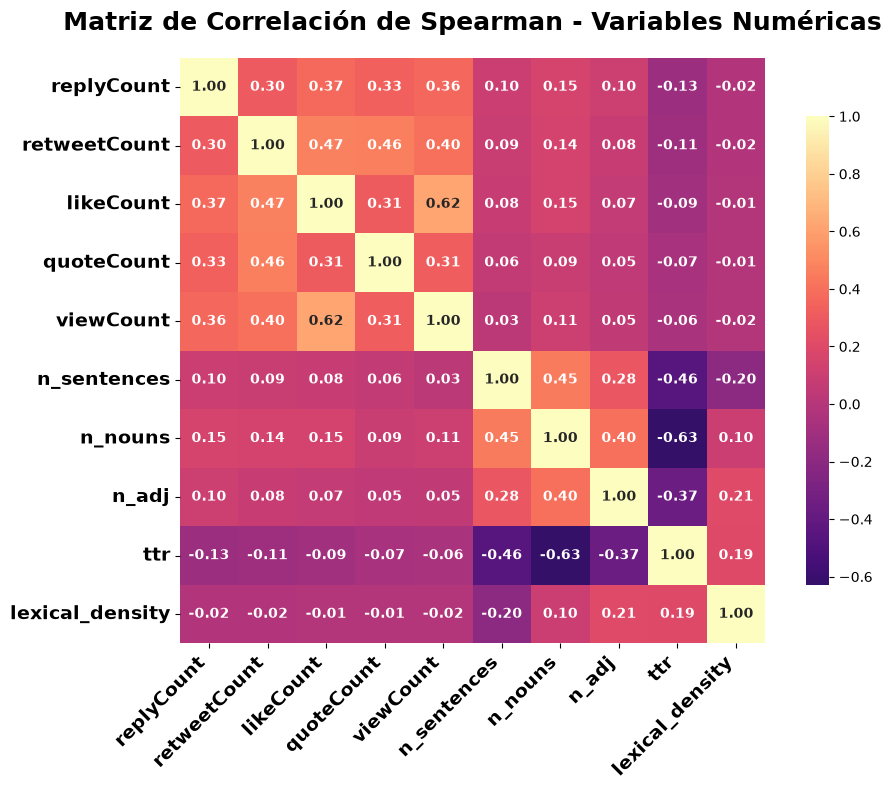

In [158]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr

# Seleccionar solo las variables numéricas
numeric_columns = ['replyCount', 'retweetCount', 'likeCount', 'quoteCount', 'viewCount',
                   'n_sentences', 'n_nouns', 'n_adj', 'ttr', 'lexical_density']
print(f"Variables numéricas encontradas: {len(numeric_columns)}")
print("Columnas:", numeric_columns)

# Calcular la matriz de correlación de Spearman
correlation_matrix = df_final[numeric_columns].corr(method='spearman')

# Crear el heatmap
plt.figure(figsize=(10, 8))  # Más chico que 20x16

sns.heatmap(correlation_matrix,
            annot=True,
            cmap='magma',
            center=0,
            square=True,
            fmt='.2f',
            cbar_kws={'shrink': 0.8},
            annot_kws={'size': 10, 'weight': 'bold'})  # Números más grandes y en negrita

plt.title('Matriz de Correlación de Spearman - Variables Numéricas',
          fontsize=18, fontweight='bold', pad=20)

# Etiquetas de ejes más grandes
plt.xticks(rotation=45, ha='right', fontsize=14, fontweight='bold')
plt.yticks(rotation=0, fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()


Variables numéricas encontradas: 8
Columnas: ['replyCount', 'retweetCount', 'likeCount', 'quoteCount', 'viewCount', 'n_sentences', 'n_nouns', 'n_adj']


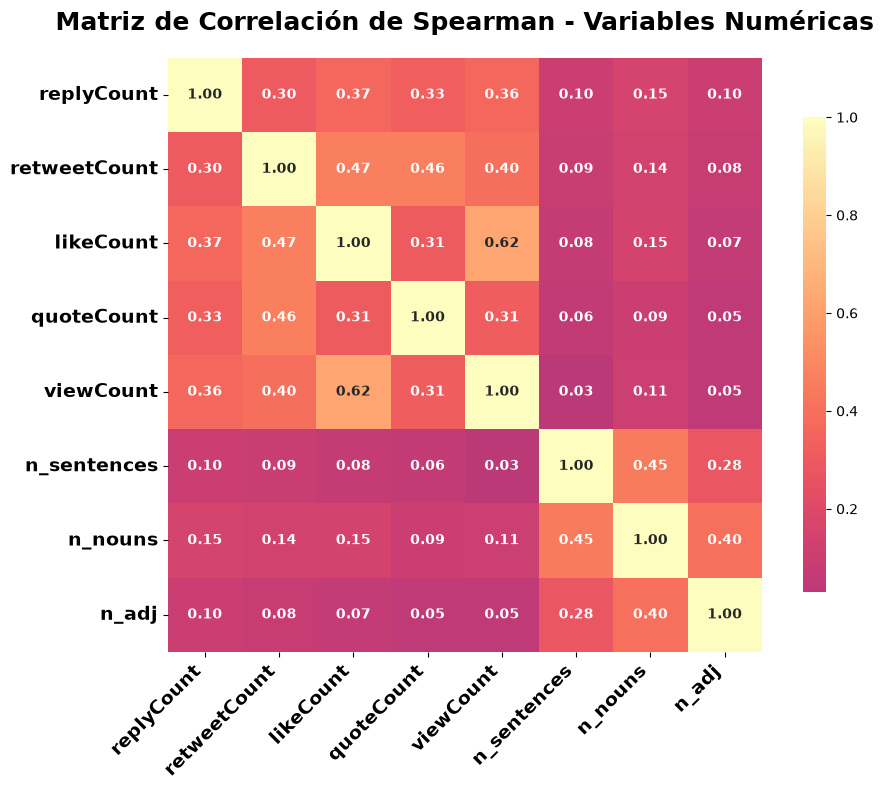

In [159]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr

# Seleccionar solo las variables numéricas
numeric_columns = ['replyCount', 'retweetCount', 'likeCount', 'quoteCount', 'viewCount',
                   'n_sentences', 'n_nouns', 'n_adj']
print(f"Variables numéricas encontradas: {len(numeric_columns)}")
print("Columnas:", numeric_columns)

# Calcular la matriz de correlación de Spearman
correlation_matrix = df_final[numeric_columns].corr(method='spearman')

# Crear el heatmap
plt.figure(figsize=(10, 8))  # Más chico que 20x16

sns.heatmap(correlation_matrix,
            annot=True,
            cmap='magma',
            center=0,
            square=True,
            fmt='.2f',
            cbar_kws={'shrink': 0.8},
            annot_kws={'size': 10, 'weight': 'bold'})  # Números más grandes y en negrita

plt.title('Matriz de Correlación de Spearman - Variables Numéricas',
          fontsize=18, fontweight='bold', pad=20)

# Etiquetas de ejes más grandes
plt.xticks(rotation=45, ha='right', fontsize=14, fontweight='bold')
plt.yticks(rotation=0, fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()


### Ejercicio final

* ¿Qué técnicas utilizadas en el práctico les parecieron más interesantes?
* Para el próximo práctico 3 deberán aplicar su modelo de ML, para ello es importante realizar una vectorización del texto de los tweets (convertir el texto a números). Algunas técnicas más utilizadas pueden ser TF-IDF, countvectorizer, bag of words, entre otras. Es importante que hagan una revisión/búsqueda sobre cuáles técnicas de vectorización utilizar, ventajas y desventajas, y cuál se acomoda mejor a su problemática y corpus.


La fecha de entrega del práctico es para el día 21/7, durante julio estaré trabajando (no tengo vacaciones) así que porfavor avisenme si necesitan que nos juntemos (aunque sea con una persona del grupo) para resolver cualquier duda o consulta.

La exploración de los tipos de palabras utilizando Spacy nos resultó interesante, creemos que es una herramienta muy potente aun con los errores que puedan cometer, no permite acceder a un análisis de los textos más sistematizado. Fue interesante que además de las palabras claves que aparecían en los top de sustantivos se observaran también otras palabras como 'salud', 'enfermedad', 'mórbido' que nos hablan de algunos de los sentidos que giran en torno a la obesidad en el discurso de Twitter.

La técnica de vectorización depende del algoritmo de modelado de tópicos. Para algoritmos como LDA, que operan sobre una matriz de documentos y términos, se utilizan representaciones como TF-IDF. En cambio, herramientas como BERTopic se basan en embeddings generados por modelos de lenguaje para vectorizar los documentos.